# Political Answer Clarity Classification

The goal of this work is to use a **multi-agent prompting framework (D3-Agentic Prompting)** with an instruction-tuned language model to predict the clarity of politician responses to journalist questions into three categories: *Clear Reply*, *Ambivalent*, and *Clear Non-Reply*.

Instead of relying on a single prompt, the task is decomposed into four specialized agents:
1. **Question Intent Agent:** identifies what the question asks for.
2. **Answer Content Agent:** extracts what the answer actually says.
3. **Gap & Evasion Agent:** detects missing elements, ambiguity, or evasive patterns.
4. **Decision Agent:** assigns the final label using the previous agents' outputs.

**Dataset:** [ailsntua/QEvasion](https://huggingface.co/datasets/ailsntua/QEvasion) (Hugging Face)

**Model:** Qwen/Qwen3.5-0.8B

**Evaluation:** Accuracy, Precision, Recall, F1-Score

>⚠️ **Notebook execution pattern**
>
>This notebook was fully executed once in **Google Colab** (A100 GPU). All cell outputs shown below were produced by that real end-to-end run.
>
>For the **Kaggle submission requirement** (Save & Run All), all the long-running agent inference loops have been **commented out** and their results **hardcoded** as constants, so the notebook re-executes quickly on Kaggle. The only inference left live is the winning configuration, re-run on the test set to produce the Kaggle submission file.
>
>To reproduce any frozen experiment, uncomment the matching cell and run it.

## Setup & Imports

In [2]:
# Ensure all required packages are installed
!pip install -q -U "transformers>=4.52.0"
!pip install "accelerate>=0.31.0" bitsandbytes datasets evaluate scikit-learn pandas numpy matplotlib tqdm
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 150.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 32.4 MB/s eta 0:00:00


In [3]:
import re, gc, json, time, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter

import torch
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed

warnings.filterwarnings("ignore")

# Single global seed for reproducibility across all libraries
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

In [4]:
# Use GPU, if available
if torch.cuda.is_available():
  device = torch.device("cuda")
  print(f"There are {torch.cuda.device_count()} GPU(s) available.")
  print(f"We will use the GPU: {torch.cuda.get_device_name(0)}")
else:
  device = torch.device("cpu")
  print("No GPU available, using the CPU instead.")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA A100-SXM4-40GB


## Load Dataset

In [5]:
# Load CLARITY / QEvasion directly from Hugging Face
DATASET_NAME = "ailsntua/QEvasion"

dataset = load_dataset(DATASET_NAME)
print(dataset)

README.md:   0%|          | 0.00/12.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 308
    })
})


In [6]:
# Parse
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(f"Original train shape: {train_df.shape}")
print(f"Original test shape: {test_df.shape}")

Original train shape: (3448, 20)
Original test shape: (308, 20)


In [6]:
train_df.sample(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
2900,The President's News Conference With President...,"April 19, 2008",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,2,Q. I have a question for President Lee. Korea ...,The process is not something that we discussed...,The question consists of 2 parts:\n\n1. Follow...,Question 1: Follow-up effects of setting up a ...,Follow-up effects of setting up a permanent li...,85,None,None,None,False,False,True,2900,Ambivalent,Implicit
51,"The President's News Conference in Hiroshima, ...","May 21, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,6,"Q. Mr. President, one more on the——Russia/U.S....",It is for them.,The question consists of 2 parts: \n\nPart 1: ...,Question part: 1 - Russia/U.S. Security Assist...,Russia/U.S. Security Assistance to Ukraine,86,None,None,None,False,False,True,51,Ambivalent,General
567,The President's News Conference,"August 14, 2020",Donald J. Trump,https://www.presidency.ucsb.edu/documents/the-...,6,Q. Mr. President——Potential Coronavirus Vaccin...,We don't know much about it. We hope it works;...,The question consists of 2 parts:\n1. Who shou...,Question part: 1. Who should get the vaccine f...,Who should get the vaccine first once it is re...,89,None,None,None,False,False,False,567,Clear Reply,Explicit


In [7]:
test_df.sample(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
287,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Mr. President, a new intelligence report sa...",Here's what we know. We know that they're stil...,None,None,Do the new findings take the military option ...,None,Implicit,Explicit,Implicit,False,False,False,287,Ambivalent,
235,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. Thank you, Mr. President. On another of you...","Bob, I strongly believe that in order to prote...",None,None,Putting off immigration reform until the new C...,None,General,General,General,False,False,True,235,Ambivalent,
156,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. Thank you, Mr. President. Yesterday you sai...","Surely not cute, I agree. [] Whatever you do, ...",None,None,What is the President's intention regarding Am...,None,Dodging,Deflection,Deflection,False,False,False,156,Ambivalent,


## Preprocessing

In [7]:
VALID_LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

In [8]:
# Check every label (train set) is one of the 3 valid labels
unique_labels = set(train_df["clarity_label"].unique())
# print("Unique labels found:", unique_labels)
print("All labels valid:", unique_labels == set(VALID_LABELS))

All labels valid: True


**Deduplication**

We use the training set both to retrieve few-shot examples (demos) and to build our validation set, a small part of the training data we set aside to test different agent prompts and design choices, while keeping the test set untouched until final submission. We deduplicate first so the same example can't land in both the demo pool and the validation set.

In [9]:
# Check for duplicate question-answer pairs in the training set
dups = train_df.duplicated(subset=["question", "interview_answer"], keep="first").sum()
print(f"Duplicate rows: {dups} ({dups/len(train_df)*100:.2f}%)")

Duplicate rows: 58 (1.68%)


In [10]:
# Remove duplicates and check new size
print(f"Original train size: {len(train_df)}")

train_df = train_df.drop_duplicates(subset=["question", "interview_answer"], keep="first").reset_index(drop=True)
print(f"After deduplication: {len(train_df)}")

Original train size: 3448
After deduplication: 3390


**Class Distribution**

In [11]:
# Class counts in train and test, with percentages
train_counts = train_df["clarity_label"].value_counts()
test_counts = test_df["clarity_label"].value_counts()

display(pd.DataFrame({
    "train_count": train_counts,
    "train_%": (train_counts / len(train_df) * 100).round(1),
    "test_count": test_counts,
    "test_%": (test_counts / len(test_df) * 100).round(1),
}))

,train_count,train_%,test_count,test_%
clarity_label,,,,
Ambivalent,2004,59.1,206,66.9
Clear Reply,1037,30.6,79,25.6
Clear Non-Reply,349,10.3,23,7.5


The dataset is imbalanced: `Ambivalent` dominates (59%), `Clear Reply` is almost 30%, and `Clear Non-Reply` is rare (10%). Similar split portions hold for the test set. This motivates two choices later: the **stratified** pool/val split and the **balanced** few-shot demo sampling strategy.

**Pool & Validation Split**

We split the deduplicated training data into a pool (examples we may show the model as few-shot demos) and a validation set (examples we score every prompt variant on to pick the best). The test set stays untouched until the final Kaggle submission. The split is stratified so each part keeps the same class proportions.

Why this matters even though we train no weights: D3 can still become prompt-overfit. If we keep rewriting prompts until a handful of inspected validation errors disappear, validation looks better but unseen test performance can drop. Keeping validation separate from the demo pool, and the test set untouched, is what stops us from fooling ourselves.

In [12]:
# Stratified 85/15 split of the deduplicated train_df with:
# pool_df = examples we may show the model as few-shot examples
# val_df = examples we score every prompt variant on, to pick the best
# test_df = NEVER touched until the final Kaggle submission
pool_df, val_df = train_test_split(train_df, test_size=0.15, random_state=SEED, stratify=train_df["clarity_label"])

pool_df = pool_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Pool size: {len(pool_df)}")
print(f"Val size: {len(val_df)}")

Pool size: 2881
Val size: 509


In [13]:
# Verify class proportions held after the stratified split
pool_counts = pool_df["clarity_label"].value_counts()
val_counts = val_df["clarity_label"].value_counts()

display(pd.DataFrame({
    "pool_count": pool_counts,
    "pool_%": (pool_counts / len(pool_df) * 100).round(1),
    "val_count": val_counts,
    "val_%": (val_counts / len(val_df) * 100).round(1),
}))

,pool_count,pool_%,val_count,val_%
clarity_label,,,,
Ambivalent,1703,59.1,301,59.1
Clear Reply,881,30.6,156,30.6
Clear Non-Reply,297,10.3,52,10.2


## Model

In [14]:
# Base model
MODEL_NAME = "Qwen/Qwen3.5-0.8B" # full HF id
BACKBONE = MODEL_NAME.split("/")[-1] # "Qwen3.5-0.8B", for tables/filenames

In [15]:
def load_qwen_model(model_name=MODEL_NAME):
  """
  Load Qwen tokenizer + model for inference, adapting dtype and placement to the available device.

  Args:
    model_name: Hugging Face model id to load

  Return:
    (tokenizer, model) tuple, ready for inference
  """
  tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

  use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
  dtype = torch.bfloat16 if use_bf16 else torch.float32

  model = AutoModelForCausalLM.from_pretrained(
      model_name,
      dtype=dtype,
      trust_remote_code=True,
  )
  if torch.cuda.is_available():
    model = model.to("cuda")

  model.eval()
  if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
  return tokenizer, model

In [16]:
# Load tokenizer and model
tokenizer, model = load_qwen_model()
print("Loaded", MODEL_NAME)

config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/50.9k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded Qwen/Qwen3.5-0.8B


In [18]:
# Inspect the loaded model's basic characteristics
n_params = sum(p.numel() for p in model.parameters())

print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")

Model name: Qwen/Qwen3.5-0.8B
Total parameters: 752,393,024 (0.75B)
Context length: 262,144 tokens


The 262,144-token context window is far more than we need. Each agent call is independent, and even the largest single call (the Decision Agent, which receives the outputs of the previous three agents inside its own prompt) stays well under a few thousand tokens. We will not need to worry about context length anywhere in this notebook.

In [19]:
print(f"Dtype: {model.dtype}") # Each weight is stored in 16 bits or the standard 32?
print(f"Vocab size: {model.config.vocab_size:,}") # Tokenizer knows 248K unique tokens (subwords + special tokens). Each token has its own row in the embedding matrix
print(f"Hidden size: {model.config.hidden_size}") # Every token is represented as a 1024-dim vector inside the model (matrix of ~250M params)
print(f"Num layers: {model.config.num_hidden_layers}") # 24 transformer blocks stacked, where the input flows through them sequentially
print(f"Num attention heads: {model.config.num_attention_heads}") # Each block runs multi-head attention with 8 parallel heads (each on 1024/8 = 128 dims)

Dtype: torch.bfloat16
Vocab size: 248,320
Hidden size: 1024
Num layers: 24
Num attention heads: 8


## D3-Agentic Prompting

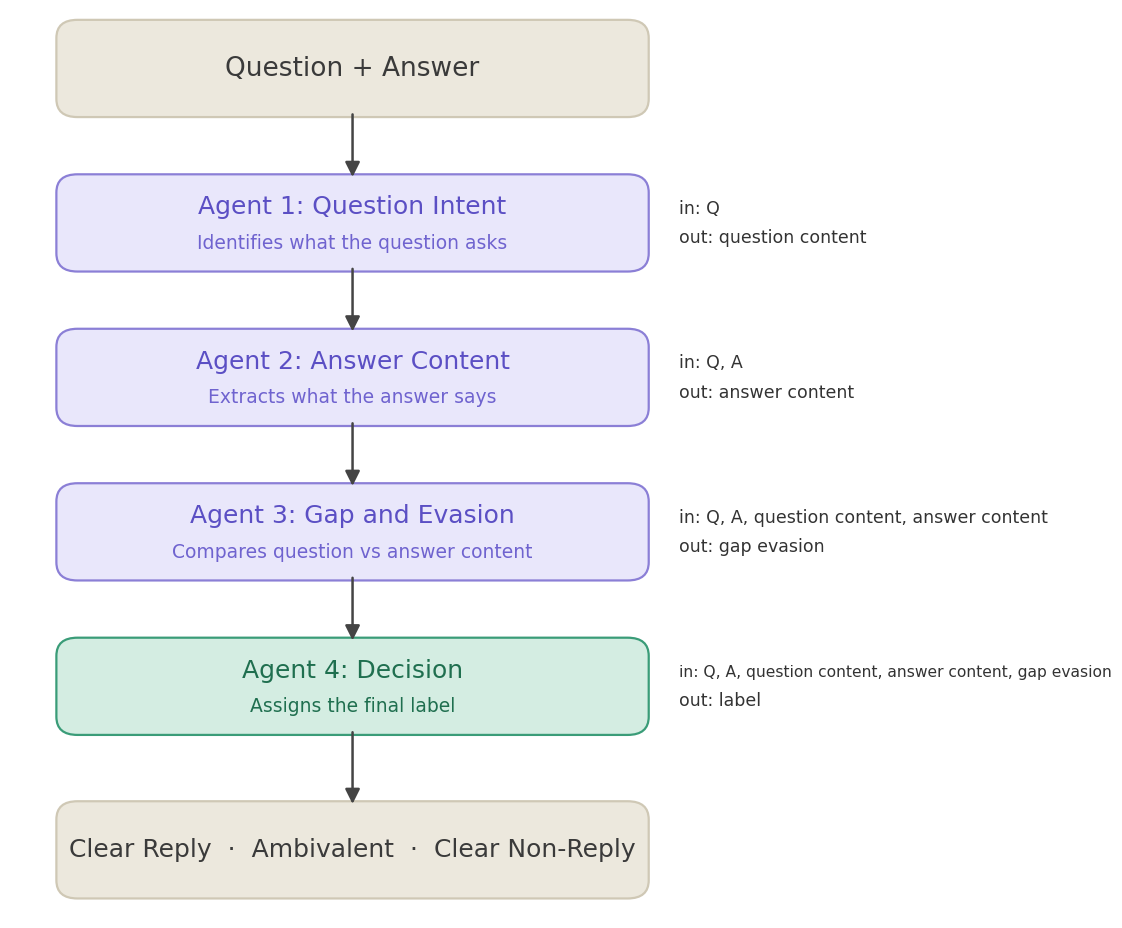

*Figure: D3-Agentic Prompting pipeline. The question and answer pass through four agents: Question Intent, Answer Content, Gap and Evasion, and Decision. Each agent's intermediate output accumulates and feeds the next, ending in a clarity label. Agents 1-3 produce analyses while Agent 4 produces the final classification.*

For each of the four agents, we make the same design choices:

1. **Input:** what data the agent receives, and in what format.
2. **Role:** what the agent does, and how its prompt describes that role.
3. **Output:** what the agent produces (here, a structured JSON object).
4. **Assembly:** how input and role combine into the final prompt.

In [17]:
# Per-agent generation caps
A1_MAX_NEW_TOKENS = 256 # Question Intent
A2_MAX_NEW_TOKENS = 512 # Answer Content
A3_MAX_NEW_TOKENS = 512 # Gap & Evasion
A4_MAX_NEW_TOKENS = 384 # Decision

**Helper Functions**

Shared utilities the four agents use: JSON parsing, single-example generation, and label normalization.

In [18]:
def extract_json_object(text):
  """
  Pull the JSON object out of a model's raw text output.

  Args:
    text: raw decoded string from the model (may include extra markers or text)

  Return:
    The parsed dict if a JSON object is found, else {"raw": <text>} so callers always get a dict
  """
  if text is None:
    return {"raw": ""}

  # Strip surrounding ```json ... ``` if present
  text = text.strip()
  text = re.sub(r"^```(?:json)?", "", text, flags=re.IGNORECASE).strip()
  text = re.sub(r"```$", "", text).strip()

  # First try: the whole string is valid JSON
  try:
    obj = json.loads(text)
    if isinstance(obj, dict):
      return obj
  except Exception:
    pass

  # Fallback: grab the first {...} block embedded in surrounding text
  match = re.search(r"\{.*\}", text, flags=re.DOTALL)
  if match:
    try:
      obj = json.loads(match.group(0))
      if isinstance(obj, dict):
        return obj
    except Exception:
      pass

  return {"raw": text}


@torch.inference_mode()
def generate_chat(messages, max_new_tokens=160):
  """
  Run the model on a list of chat messages and return its text reply plus stats.

  Args:
    messages: list of {"role": ..., "content": ...} dicts (system/user/assistant turns)
    max_new_tokens: cap on how many tokens to generate

  Return:
    reply: the decoded reply string (only the newly generated text, stripped)
    stats: dict with input_tokens, output_tokens, total_tokens, elapsed_sec
  """
  prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
  # inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4096).to(model.device)
  inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
  input_tokens = inputs["input_ids"].shape[1]

  start = time.time()
  output_ids = model.generate(
      **inputs,
      max_new_tokens=max_new_tokens,
      do_sample=False, # Greedy decoding
      pad_token_id=tokenizer.pad_token_id,
      eos_token_id=tokenizer.eos_token_id,
  )
  elapsed = time.time() - start

  new_tokens = output_ids[0][input_tokens:]
  reply = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

  stats = {
      "input_tokens": input_tokens,
      "output_tokens": len(new_tokens),
      "total_tokens": input_tokens + len(new_tokens),
      "elapsed_sec": elapsed,
  }
  return reply, stats


def normalize_prediction_label(text):
  """
  Map the Decision agent's raw label text to one of the 3 valid labels.

  Args:
    text: raw label string from the model (may be messy: underscores, extra words)

  Return:
    One of VALID_LABELS, or None if nothing matches
  """
  if text is None:
    return None # or set "Ambivalent" as fallback

  # Remove any <think>...</think> reasoning block before matching
  text = re.sub(r"<think>.*?</think>", "", str(text), flags=re.DOTALL)

  # Clean: lowercase, underscores to spaces, collapse repeated spaces
  key = re.sub(r"\s+", " ", str(text).lower().replace("_", " ")).strip()

  # Match against keywords
  if "non" in key and "reply" in key:
    return "Clear Non-Reply"
  if "ambivalent" in key or "ambiguous" in key or "partial" in key or "unclear" in key:
    return "Ambivalent"
  if "clear reply" in key or "reply" in key:
    return "Clear Reply"

  # Last case: any exact valid label appearing in the text
  for label in VALID_LABELS:
    if label.lower() in key:
      return label

  return None # or set "Ambivalent" as fallback

### Question Intent Agent

In [19]:
QUESTION_INTENT_SYSTEM_PROMPT = """
You are the Question Intent Agent for a response-clarity classification task.

Important dataset rule:
The TARGET_QUESTION may be only one sub-question extracted from a longer interview question.
Analyze ONLY the TARGET_QUESTION. Do not require the answer to address other questions unless they are necessary for this target question.

Your task:
Identify exactly what information would make an answer clear for the TARGET_QUESTION.

Think in terms of answer requirements:
- Is the question asking for yes/no?
- Is it asking what happened?
- Is it asking why/how something happened?
- Is it asking for a specific action, plan, reason, explanation, stance, or evaluation?
- Is it asking about a named person, event, country, policy, organization, or date?

Return exactly one JSON object and nothing else.

JSON schema:
{
  "question_type": "pick exactly ONE: yes_no, what, why, how, when, where, who, stance, explanation, action_plan, evaluation, other",
  "question_intent": "one sentence describing what the target question asks",
  "must_address": [
    "a concrete requirement that a clear answer must satisfy for this question",
    "another concrete requirement, or omit if only one"
  ],
  "clear_answer_criteria": "one sentence describing what a clear answer must contain",
  "minimal_sufficient_answer": "short description of the minimum information needed for Clear Reply"
}
""".strip()

In [23]:
# print(QUESTION_INTENT_SYSTEM_PROMPT)
print(f"Tokens: {len(tokenizer.encode(QUESTION_INTENT_SYSTEM_PROMPT))}")

Tokens: 308


In [20]:
def run_question_intent_agent(question, interview_question="", system_prompt=QUESTION_INTENT_SYSTEM_PROMPT, max_new_tokens=A1_MAX_NEW_TOKENS):
  """
  Run the Question Intent Agent on one question.

  Args:
    question: the target interview sub-question
    interview_question: the full journalist turn, given as context only (optional)
    system_prompt: which Question Intent prompt to use (default: original)
    max_new_tokens: cap on generated tokens

  Return:
    obj: parsed JSON dict of the agent's analysis (plus "raw")
    stats: generation stats from generate_chat
  """
  user_content = f"TARGET_QUESTION:\n{question}"
  if interview_question:
    user_content = f"INTERVIEW_QUESTION (context only):\n{interview_question}\n\n" + user_content

  messages = [
      {"role": "system", "content": system_prompt},
      {"role": "user", "content": user_content},
  ]
  raw, stats = generate_chat(messages, max_new_tokens=max_new_tokens)

  obj = extract_json_object(raw)
  obj["raw"] = raw
  return obj, stats

In [25]:
# # Dummy run on one real validation question (example_row reused across all agent tests)
# example_row = val_df.iloc[0]
# print(f"Question:\n{example_row['question']}\n")

# intent_obj, stats = run_question_intent_agent(example_row['question'])

# print(f"Analysis ({stats['elapsed_sec']:.2f}s):")
# print(json.dumps(intent_obj, indent=2))

Question:
Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?

Analysis (6.86s):
{
  "question_type": "yes_no",
  "question_intent": "The user is asking for a direct yes or no answer regarding the user's party's future political stance on nuclear power, offshore drilling, and free trade.",
  "must_address": [
    "The user's party's future political stance on nuclear power, offshore drilling, and free trade"
  ],
  "clear_answer_criteria": "The answer must clearly state whether the user's party intends to support nuclear power, offshore drilling, or free trade, without providing unnecessary speculation or analysis.",
  "minimal_sufficient_answer": "Yes or no, depending on the user's party's stated position.",
  "raw": "{\n  \"question_type\": \"yes_no\",\n  \"question_intent\": \"The user is asking for a direct yes or no answer regarding the user's party's future political stance on nuclear power, offshore drilling, an

In [21]:
def print_token_usage_report(stats, cap, cap_name = "max_new_tokens"):
  """
  Print a token-usage report for one agent call.

  Args:
      stats: dict returned by an agent runner (input_tokens, output_tokens, total_tokens, elapsed_sec)
      cap: the max_new_tokens cap value used in that call
      cap_name: human-readable name of the cap constant (for display)

  Return:
      None
  """
  context_window = model.config.max_position_embeddings
  throughput = stats["output_tokens"] / stats["elapsed_sec"]

  print(f"Input tokens (system + user + chat template): {stats['input_tokens']}")
  print(f"Output tokens (generated analysis): {stats['output_tokens']}")
  print(f"Total tokens: {stats['total_tokens']}")
  print(f"Context window: {context_window:,}")
  print(f"Context used: {stats['total_tokens']} / {context_window:,} tokens ({stats['total_tokens']/context_window*100:.3f}%)")
  print(f"Throughput: {throughput:.2f} tokens/sec")
  print(f"Cap used ({cap_name}={cap}): {stats['output_tokens']} / {cap} tokens ({stats['output_tokens']/cap*100:.0f}%)")
  if stats["output_tokens"] >= cap:
    print(f"Output likely truncated, consider raising {cap_name}.")

In [27]:
# print_token_usage_report(stats, A1_MAX_NEW_TOKENS, "A1_MAX_NEW_TOKENS")

Input tokens (system + user + chat template): 354
Output tokens (generated analysis): 145
Total tokens: 499
Context window: 262,144
Context used: 499 / 262,144 tokens (0.190%)
Throughput: 21.14 tokens/sec
Cap used (A1_MAX_NEW_TOKENS=256): 145 / 256 tokens (57%)


### Answer Content Agent

In [22]:
ANSWER_CONTENT_SYSTEM_PROMPT = """
You are the Answer Content Agent for a response-clarity classification task.

Important dataset rule:
The answer may respond to a longer interview question, but you must evaluate what it says with respect to the TARGET_QUESTION only.

Your task:
Extract what the answer actually says that is relevant to the TARGET_QUESTION.

Do not decide the final label.
Do not reward political rhetoric unless it answers the target question.
Do not infer facts that are not present in the answer.
Do not import topics from the question into your extraction. If the answer does not mention a topic the question raises, leave it out entirely as its absence is exactly what later agents must detect.
An implicit answer is allowed only if the answer gives enough information to resolve the target question.

Look for:
- direct answer phrases: yes, no, I did, I did not, we will, we will not, because...
- concrete facts, actions, reasons, explanations, examples, commitments
- vague but related statements
- topic shifts
- refusals or declines to answer
- answers to a different sub-question

Return exactly one JSON object and nothing else.

JSON schema:
{
  "relevant_answer_summary": "one sentence summarizing only content relevant to the target question",
  "direct_answer_present": true,
  "direct_answer_text": "exact short phrase if present, otherwise empty string",
  "concrete_information": [
    "concrete relevant point 1",
    "concrete relevant point 2"
  ],
  "vague_or_general_information": [
    "vague/general relevant point 1"
  ],
  "off_target_content": [
    "content that answers a different question or changes topic"
  ],
  "refusal_or_non_answer_signals": [
    "signal 1"
  ]
}
""".strip()

In [29]:
# print(ANSWER_CONTENT_SYSTEM_PROMPT)
print(f"Tokens: {len(tokenizer.encode(ANSWER_CONTENT_SYSTEM_PROMPT))}")

Tokens: 391


In [23]:
def run_answer_content_agent(question, answer, interview_question="", system_prompt=ANSWER_CONTENT_SYSTEM_PROMPT, max_new_tokens=A2_MAX_NEW_TOKENS):
  """
  Run the Answer Content Agent on one (question, answer) pair.

  Args:
    question: the target interview sub-question
    answer: the politician's answer
    interview_question: the full journalist turn, context only (optional)
    system_prompt: which Answer Content prompt to use (default: original)
    max_new_tokens: cap on generated tokens

  Return:
    obj: parsed JSON dict describing what the answer says (plus "raw")
    stats: generation stats from generate_chat
  """
  user_content = f"TARGET_QUESTION:\n{question}\n\nAnswer:\n{answer}"
  if interview_question:
    user_content = f"INTERVIEW_QUESTION (context only):\n{interview_question}\n\n" + user_content

  messages = [
      {"role": "system", "content": system_prompt},
      {"role": "user", "content": user_content},
  ]
  raw, stats = generate_chat(messages, max_new_tokens=max_new_tokens)

  obj = extract_json_object(raw)
  obj["raw"] = raw
  return obj, stats

In [31]:
# # Dummy run on the same validation example
# print(f"Question:\n{example_row['question']}\n")
# print(f"Answer:\n{example_row['interview_answer']}\n")

# content_obj, stats = run_answer_content_agent(example_row["question"], example_row["interview_answer"])

# print(f"Answer Content ({stats['elapsed_sec']:.2f}s):")
# print(json.dumps(content_obj, indent=2))

Question:
Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?

Answer:
You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some of the old, traditional energy sources as we're developing these new ones and ramping them up. All right? So we can't overnight convert to an all-solar or an all-wind economy. That just can't happen. We're going to have needs in these traditional sources.And so the 

In [32]:
# print_token_usage_report(stats, A2_MAX_NEW_TOKENS, "A2_MAX_NEW_TOKENS")

Input tokens (system + user + chat template): 814
Output tokens (generated analysis): 280
Total tokens: 1094
Context window: 262,144
Context used: 1094 / 262,144 tokens (0.417%)
Throughput: 23.83 tokens/sec
Cap used (A2_MAX_NEW_TOKENS=512): 280 / 512 tokens (55%)


### Gap & Evasion Agent

In [24]:
GAP_EVASION_SYSTEM_PROMPT = """
You are the Gap and Evasion Agent for response-clarity classification.

You receive:
1. the TARGET_QUESTION,
2. the answer,
3. the Question Intent Agent output,
4. the Answer Content Agent output.

Your task:
Compare what the target question requires with what the answer provides.

Important distinction:
- Missing small detail but mostly answering -> minor gap.
- Some relevant information but vague, incomplete, generic, or indirect -> partial gap.
- Mostly answering another topic, refusing, or avoiding the target question -> major gap.

Use these evasion categories when useful:
- explicit_answer: directly answers the target question.
- implicit_answer: not in requested form, but enough information is provided.
- partial_half_answer: answers only part of what was asked.
- general_answer: gives broad values/principles but lacks the requested specifics.
- dodging: avoids the precise target question while saying related things.
- deflection: redirects to another issue/person/topic.
- declining_to_answer: refuses, says cannot comment, or avoids due to confidentiality.
- claims_ignorance: says they do not know or cannot assess.
- clarification_only: asks for clarification or corrects framing without answering.
- irrelevant: no meaningful relation to the target question.

Do not assign the final top-level label.
Return exactly one JSON object and nothing else.

JSON schema:
{
  "coverage": "complete|mostly_complete|partial|minimal|none",
  "gap_level": "none|minor|partial|major",
  "best_evasion_category": "explicit_answer|implicit_answer|partial_half_answer|general_answer|dodging|deflection|declining_to_answer|claims_ignorance|clarification_only|irrelevant",
  "missing_requirements": [
    "missing requirement 1"
  ],
  "evidence_for_answering": [
    "short evidence from the answer"
  ],
  "evidence_for_evasion_or_gap": [
    "short evidence from the answer"
  ],
  "gap_explanation": "one concise sentence"
}
""".strip()

In [34]:
# print(GAP_EVASION_SYSTEM_PROMPT)
print(f"Tokens: {len(tokenizer.encode(GAP_EVASION_SYSTEM_PROMPT))}")

Tokens: 455


In [25]:
def run_gap_evasion_agent(question, answer, question_intent, answer_content, system_prompt=GAP_EVASION_SYSTEM_PROMPT, max_new_tokens=A3_MAX_NEW_TOKENS):
  """
  Run the Gap and Evasion Agent on one example, using the prior two agents' outputs.

  Args:
    question, answer: the target sub-question and the answer
    question_intent, answer_content: dict outputs from Agents 1 and 2
    system_prompt: which Gap & Evasion prompt to use (default: original)
    max_new_tokens: cap on generated tokens

  Return:
    obj: parsed JSON dict describing the gap/evasion (plus "raw")
    stats: generation stats from generate_chat
  """
  # Pass prior agent outputs as a structured payload so the model sees their fields clearly
  user_payload = {
      "question": question,
      "answer": answer,
      "question_intent_agent_output": question_intent,
      "answer_content_agent_output": answer_content,
  }
  messages = [
      {"role": "system", "content": system_prompt},
      {"role": "user", "content": json.dumps(user_payload, ensure_ascii=False, indent=2)},
  ]
  raw, stats = generate_chat(messages, max_new_tokens=max_new_tokens)

  obj = extract_json_object(raw)
  obj["raw"] = raw
  return obj, stats

In [36]:
# # Dummy run on the same validation example, reusing agent 1 & 2 outputs (intent_obj, content_obj)
# print(f"Question:\n{example_row['question']}\n")
# print(f"Answer:\n{example_row['interview_answer']}\n")

# print("Question Intent output (from Agent 1):")
# print(json.dumps(intent_obj, indent=2), "\n")

# print("Answer Content output (from Agent 2):")
# print(json.dumps(content_obj, indent=2), "\n")

# gap_obj, stats = run_gap_evasion_agent(example_row["question"], example_row["interview_answer"], intent_obj, content_obj)

# print(f"Gap & Evasion ({stats['elapsed_sec']:.2f}s):")
# print(json.dumps(gap_obj, indent=2))

Question:
Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?

Answer:
You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some of the old, traditional energy sources as we're developing these new ones and ramping them up. All right? So we can't overnight convert to an all-solar or an all-wind economy. That just can't happen. We're going to have needs in these traditional sources.And so the 

In [37]:
# print_token_usage_report(stats, A3_MAX_NEW_TOKENS, "A3_MAX_NEW_TOKENS")

Input tokens (system + user + chat template): 1786
Output tokens (generated analysis): 451
Total tokens: 2237
Context window: 262,144
Context used: 2237 / 262,144 tokens (0.853%)
Throughput: 23.72 tokens/sec
Cap used (A3_MAX_NEW_TOKENS=512): 451 / 512 tokens (88%)


### Decision Agent

In [26]:
DECISION_SYSTEM_PROMPT = """
You are the Decision Agent for CLARITY response classification.

Assign exactly one final label for how clearly the ANSWER responds to the TARGET_QUESTION.

Valid labels:
1. Clear Reply
2. Ambivalent
3. Clear Non-Reply

Critical dataset rule:
Judge only the TARGET_QUESTION, not the whole interview question. If the answer addresses a different sub-question but not the target question, this is not a Clear Reply.

Definitions:

Clear Reply:
- The answer directly or implicitly provides the information requested by the target question.
- A yes/no question can be Clear Reply if the answer clearly implies yes or no.
- The answer does not need to be long.
- The answer may be politically framed, but it must still resolve the target question.

Ambivalent:
- The answer contains some relevant information but is incomplete, vague, overly general, or only partially responsive.
- The answer gives values, background, context, or related claims but does not fully satisfy the target question.
- The answer may answer part of a multi-part question but misses the current target question.
- Use Ambivalent for borderline cases where there is meaningful relevance but insufficient clarity.

Clear Non-Reply:
- The answer does not meaningfully answer the target question.
- It refuses to answer, says it cannot comment, claims ignorance, redirects to another topic, or only answers a different question.
- Use Clear Non-Reply when the response gives little or no usable information for the target question.

Decision rules:
- If coverage is complete or mostly_complete and the answer resolves the target question -> Clear Reply.
- If coverage is partial/minimal but there is relevant information -> Ambivalent.
- If coverage is none, or the response is mainly refusal/deflection/irrelevant -> Clear Non-Reply.
- Do not classify as Clear Non-Reply only because the answer is indirect. Indirect but sufficient answers are Clear Reply.
- Do not classify as Clear Reply only because the answer is fluent or politically detailed. It must answer the target question.
- Prefer Ambivalent over Clear Non-Reply when the answer has relevant but insufficient information.
- Prefer Ambivalent over Clear Reply when the answer is related but lacks the requested specific stance/action/reason.

Few-shot calibration examples:

Example A:
Target question: "Did you support the bill?"
Answer content: "Yes, I voted for it and I still support it."
Gap analysis: coverage complete; explicit answer.
Final label: Clear Reply.

Example B:
Target question: "What specific steps will you take to reduce prices?"
Answer content: "Families are struggling, this is important, and we are working every day."
Gap analysis: relevant but no specific steps.
Final label: Ambivalent.

Example C:
Target question: "Did you meet with the ambassador?"
Answer content: "I am not going to discuss private diplomatic conversations."
Gap analysis: declining to answer; no requested information.
Final label: Clear Non-Reply.

Example D:
Target question: "Why did unemployment increase?"
Answer content: "The economy has faced global pressure, energy shocks, and reduced demand."
Gap analysis: gives reasons even without saying 'because'.
Final label: Clear Reply.

Example E:
Target question: "Do you think President X is sincere?"
Answer content: "I am sincere about improving the relationship."
Gap analysis: answers the speaker's sincerity, not President X's sincerity.
Final label: Ambivalent.

Return exactly one JSON object and nothing else.

JSON schema:
{
  "label": "Clear Reply|Ambivalent|Clear Non-Reply",
  "confidence": 0.0,
  "main_reason": "one concise sentence",
  "used_rule": "short description of the rule that determined the label"
}
""".strip()

In [39]:
# print(DECISION_SYSTEM_PROMPT)
print(f"Tokens: {len(tokenizer.encode(DECISION_SYSTEM_PROMPT))}")

Tokens: 814


In [27]:
def format_decision_payload(question, answer, question_intent, answer_content, gap_evasion):
    """
    Build the Decision user message payload.

    Args:
       question: the target interview sub-question
       answer: the politician's answer
       question_intent: dict from the Question Intent Agent
       answer_content: dict from the Answer Content Agent
       gap_evasion: dict from the Gap and Evasion Agent

    Return:
       a json string with the payload
    """
    return json.dumps({
        "question": question,
        "answer": answer,
        "question_intent_agent_output": question_intent,
        "answer_content_agent_output": answer_content,
        "gap_and_evasion_agent_output": gap_evasion,
    }, ensure_ascii=False, indent=2)


def run_decision_agent(question, answer, question_intent, answer_content, gap_evasion, system_prompt = DECISION_SYSTEM_PROMPT, demos = None, max_new_tokens=A4_MAX_NEW_TOKENS):
  """
  Run the Decision Agent on one example, using all three prior agents' outputs.

  Args:
    question: the target interview sub-question
    answer: the politician's answer
    question_intent: dict from the Question Intent Agent
    answer_content: dict from the Answer Content Agent
    gap_evasion: dict from the Gap and Evasion Agent
    system_prompt: which Decision prompt to use (default: original)
    demos: list of few-shot examples (optional)
    max_new_tokens: cap on generated tokens

  Return:
    obj: dict with the final "label" plus interpretability fields and "raw"
    stats: generation stats from generate_chat
  """
  messages = [{"role": "system", "content": system_prompt}]

  if demos is not None:
    for demo in demos:
      p = demo["payload"]

      messages.append({"role": "user", "content": format_decision_payload(p["question"], p["answer"], p["question_intent_agent_output"], p["answer_content_agent_output"], p["gap_and_evasion_agent_output"])}),
      messages.append({"role": "assistant", "content": demo["label"]})

  messages.append({"role": "user", "content": format_decision_payload(question, answer, question_intent, answer_content, gap_evasion)})

  raw, stats = generate_chat(messages, max_new_tokens=max_new_tokens)

  parsed = extract_json_object(raw)

  obj = {
      "label": normalize_prediction_label(parsed.get("label", raw)),
      "confidence": parsed.get("confidence"),
      "main_reason": parsed.get("main_reason", ""),
      "used_rule": parsed.get("used_rule", ""),
      "raw": raw,
  }
  return obj, stats

In [41]:
# # Dummy run on the same validation example, reusing agent 1, 2 & 3 outputs (intent_obj, content_obj, gap_obj)
# print(f"Question:\n{example_row['question']}\n")
# print(f"Answer:\n{example_row['interview_answer']}\n")

# print("Question Intent output (from Agent 1):")
# print(json.dumps(intent_obj, indent=2), "\n")

# print("Answer Content output (from Agent 2):")
# print(json.dumps(content_obj, indent=2), "\n")

# print("Gap & Evasion output (from Agent 3):")
# print(json.dumps(gap_obj, indent=2), "\n")

# decision_obj, stats = run_decision_agent(example_row["question"], example_row["interview_answer"], intent_obj, content_obj, gap_obj)

# print(f"Decision ({stats['elapsed_sec']:.2f}s):")
# print(json.dumps(decision_obj, indent=2))

Question:
Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?

Answer:
You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some of the old, traditional energy sources as we're developing these new ones and ramping them up. All right? So we can't overnight convert to an all-solar or an all-wind economy. That just can't happen. We're going to have needs in these traditional sources.And so the 

In [43]:
# # Gold label for the example row we've been testing (val_df.iloc[0]) and the token stats
# print(f"Gold label: {example_row['clarity_label']}")
# print_token_usage_report(stats, A4_MAX_NEW_TOKENS, "A4_MAX_NEW_TOKENS")

Gold label: Ambivalent
Input tokens (system + user + chat template): 3073
Output tokens (generated analysis): 251
Total tokens: 3324
Context window: 262,144
Context used: 3324 / 262,144 tokens (1.268%)
Throughput: 22.78 tokens/sec
Cap used (A4_MAX_NEW_TOKENS=384): 251 / 384 tokens (65%)


**Full Pipeline**

The four agents are now chained into one pipeline: each agent's output feeds the next, ending in a final clarity label. We define `run_d3_one` to run a single (question, answer) pair through all four agents, and `run_d3_dataframe` to apply it across a DataFrame with periodic checkpointing.

The four agents are now chained into one pipeline: each agent's output feeds the next, ending in a final clarity label. We define `run_d3_one` to run a single (question, answer) pair through the agents, and `run_d3_dataframe` to apply it across a DataFrame with periodic checkpointing. By default all four agents run, but the pipeline can also drop one or more support agents for the later ablation experiments, while the Decision agent always runs.

In [28]:
def run_d3_one(question, answer, use_intent=True, use_content=True, use_gap=True, decision_demos=None, gap_prompt=GAP_EVASION_SYSTEM_PROMPT, decision_prompt=DECISION_SYSTEM_PROMPT):
  """
  Run one (question, answer) pair through the four D3 agents in sequence.

  Set any use_* flag to False to drop that support agent (its output becomes {} for the agents downstream). Agent 4 (Decision) is always run.

  Args:
    question: the target interview sub-question
    answer: the politician's answer
    use_intent: run Agent 1 (Question Intent) if True, else pass {}
    use_content: run Agent 2 (Answer Content) if True, else pass {}
    use_gap: run Agent 3 (Gap & Evasion) if True, else pass {}
    decision_demos: list of few-shot examples for Agent 4 (Decision) (optional)
    gap_prompt: which Gap & Evasion prompt to use (default: original)
    decision_prompt: which Decision prompt to use (default: original)

  Return:
    A dict with each agent's output (d3_question_intent, d3_answer_content,
    d3_gap_evasion, d3_decision), the final label (pred_d3), and total time (d3_elapsed_sec)
  """
  empty = {"elapsed_sec": 0.0}

  if use_intent:
    question_intent, s1 = run_question_intent_agent(question)
  else:
    question_intent, s1 = {}, empty

  if use_content:
    answer_content, s2 = run_answer_content_agent(question, answer)
  else:
    answer_content, s2 = {}, empty

  if use_gap:
    gap_evasion, s3 = run_gap_evasion_agent(question, answer, question_intent, answer_content, system_prompt=gap_prompt)
  else:
    gap_evasion, s3 = {}, empty

  decision, s4 = run_decision_agent(question, answer, question_intent, answer_content, gap_evasion, demos=decision_demos, system_prompt=decision_prompt)

  return {
      "d3_question_intent": question_intent,
      "d3_answer_content": answer_content,
      "d3_gap_evasion": gap_evasion,
      "d3_decision": decision,
      "pred_d3": decision["label"],
      "d3_elapsed_sec": s1["elapsed_sec"] + s2["elapsed_sec"] + s3["elapsed_sec"] + s4["elapsed_sec"],
  }


def run_d3_dataframe(df, output_filename, limit=None, checkpoint_every=25, use_intent=True, use_content=True, use_gap=True, decision_demos=None, gap_prompt=GAP_EVASION_SYSTEM_PROMPT, decision_prompt=DECISION_SYSTEM_PROMPT):
  """
  Run the D3 pipeline over a DataFrame, row by row.

  Args:
    df: DataFrame with "question" and "interview_answer" columns
    output_filename: CSV filename to save results to
    limit: if set, only process the first `limit` rows (None = all)
    checkpoint_every: save partial results every N rows
    use_intent: forwarded to run_d3_one (drop Agent 1 if False)
    use_content: forwarded to run_d3_one (drop Agent 2 if False)
    use_gap: forwarded to run_d3_one (drop Agent 3 if False)
    decision_demos: list of few-shot examples for Agent 4 (Decision) (optional)
    gap_prompt: which Gap & Evasion prompt to use (default: original)
    decision_prompt: which Decision prompt to use (default: original)

  Return:
    result_df: copy of the processed rows with the D3 output columns added
  """
  run_df = df.copy()
  if limit is not None:
    run_df = run_df.head(limit).copy()

  rows = []
  for _, row in tqdm(run_df.iterrows(), total=len(run_df), desc="D3-Agentic Prompting"):
    out = run_d3_one(str(row["question"]), str(row["interview_answer"]), use_intent=use_intent, use_content=use_content, use_gap=use_gap, decision_demos=decision_demos, gap_prompt=gap_prompt, decision_prompt=decision_prompt)

    # Flatten dict outputs to JSON strings so they survive to_csv
    rows.append({
        "d3_question_intent": json.dumps(out["d3_question_intent"], ensure_ascii=False),
        "d3_answer_content": json.dumps(out["d3_answer_content"], ensure_ascii=False),
        "d3_gap_evasion": json.dumps(out["d3_gap_evasion"], ensure_ascii=False),
        "d3_decision": json.dumps(out["d3_decision"], ensure_ascii=False),
        "pred_d3": out["pred_d3"],
        "d3_elapsed_sec": out["d3_elapsed_sec"],
    })

    # Periodic checkpoint: rebuild and save what we have so far
    if len(rows) % checkpoint_every == 0:
      checkpoint_df = pd.concat([run_df.iloc[:len(rows)].reset_index(drop=True), pd.DataFrame(rows)], axis=1)
      checkpoint_df.to_csv(output_filename, index=False)

  result_df = pd.concat([run_df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
  result_df.to_csv(output_filename, index=False)
  return result_df

## Experiments

We score each D3 variant on the validation set and collect every run into one results table. We begin with the reference-prompt baseline, then ablate individual agents to measure each component's contribution, and finally optimize prompts manually and with DSPy. The test set stays untouched until the final submission.

In [29]:
# How many rows each split runs on (None = all rows)
D3_VALID_LIMIT = 100
D3_TEST_LIMIT = None

# Results accumulator
all_results = []

**Evaluation Helpers**

Shared scoring utilities used by every experiment below: a metrics function returning accuracy / macro & weighted precision, recall, F1, a full per-class report, and a confusion-matrix plot.

In [30]:
def evaluate_predictions(y_true, y_pred, model_name, method, backbone="Qwen3.5-0.8B", sec_per_example=None, labels=VALID_LABELS):
    """
    Compute standard classification metrics for one run.

    Args:
      y_true: gold labels
      y_pred: predicted labels (may contain None for parse failures)
      model_name: the system/approach that produced these (e.g. "D3 (full)", "D3 (drop Gap)")
      method: experiment/variant name (e.g. "ref prompts", "Combo 1: drop Agent 3")
      backbone: the underlying model, default "Qwen3.5-0.8B"
      sec_per_example: time needed for one example, default None
      labels: the valid label set, fixed so metrics ignore any "INVALID"

    Return:
      A dict (one results-table row) with system, backbone, method, all metrics, and parse_failure_rate
    """
    # Count parse failures (None), then mark them "INVALID" so they score as wrong
    n_fail = sum(p is None for p in y_pred)
    y_pred = ["INVALID" if p is None else p for p in y_pred]

    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

    return {
        "system": model_name,
        "backbone": backbone,
        "method": method,
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f_macro,
        "precision_weighted": p_weighted,
        "recall_weighted": r_weighted,
        "f1_weighted": f_weighted,
        "parse_failure_rate": n_fail / len(y_pred),
        "sec_per_example": sec_per_example,
    }


def print_full_report(y_true, y_pred, title):
    """
    Print the full per-class classification report for one run.

    Args:
      y_true: gold labels
      y_pred: predicted labels
      title: run name shown as the report header

    Return:
      None
    """
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(classification_report(y_true, y_pred, labels=VALID_LABELS, zero_division=0))


def plot_confusion_matrix(y_true, y_pred, title, filename):
    """
    Plot, save, and show a confusion matrix for one run.

    Args:
      y_true: gold labels
      y_pred: predicted labels
      title: run name shown on the plot
      filename: png to save, e.g. "confusion-matrix-ref-prompts.png"

    Return:
      None
    """
    cm = confusion_matrix(y_true, y_pred, labels=VALID_LABELS)
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(VALID_LABELS)))
    ax.set_yticks(range(len(VALID_LABELS)))
    ax.set_xticklabels(VALID_LABELS, rotation=35, ha="right")
    ax.set_yticklabels(VALID_LABELS)
    for i in range(len(VALID_LABELS)):
      for j in range(len(VALID_LABELS)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

### D3-Agentic Baseline (Reference Prompts)

In [47]:
# # Run D3-Agentic baseline (reference prompts) on the validation set
# print("Running D3 validation")
# print("Validation rows available:", len(val_df))
# print("D3_VALID_LIMIT:", D3_VALID_LIMIT)

# csv_path = f"d3_validation_ref_prompts_{BACKBONE}.csv"
# d3_valid_df = run_d3_dataframe(val_df, output_filename=csv_path, limit=D3_VALID_LIMIT)
# print("Saved D3 validation outputs to:", csv_path)

Running D3 validation
Validation rows available: 509
D3_VALID_LIMIT: 100


D3-Agentic Prompting:   0%|          | 0/100 [00:00<?, ?it/s]

Saved D3 validation outputs to: d3_validation_ref_prompts_Qwen3.5-0.8B.csv


D3 (full), ref prompts (Qwen3.5-0.8B)
                 precision    recall  f1-score   support

    Clear Reply       0.42      0.59      0.49        32
     Ambivalent       0.70      0.61      0.65        61
Clear Non-Reply       0.50      0.14      0.22         7

       accuracy                           0.57       100
      macro avg       0.54      0.45      0.45       100
   weighted avg       0.60      0.57      0.57       100



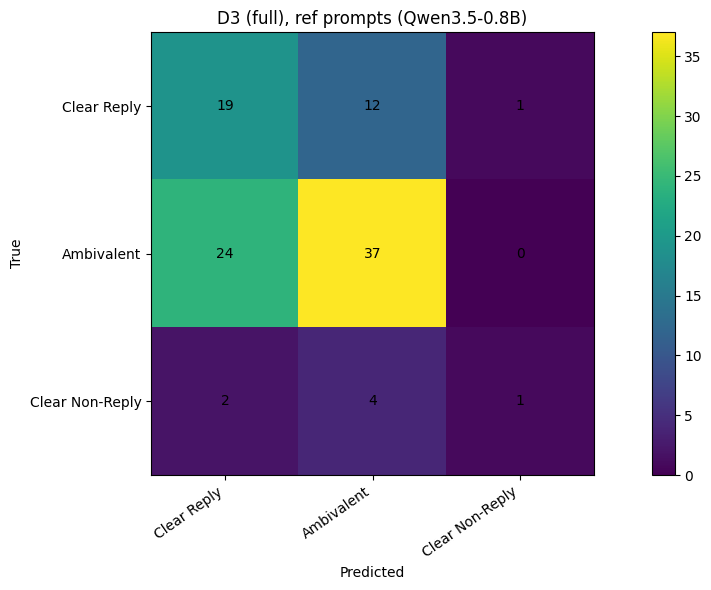

In [48]:
# # Score the reference-prompts baseline and record the result
# d3_y_true = d3_valid_df["clarity_label"].tolist()
# d3_y_pred = d3_valid_df["pred_d3"].tolist()
# d3_sec = d3_valid_df["d3_elapsed_sec"].mean()

# d3_result = evaluate_predictions(d3_y_true, d3_y_pred, "D3 (full)", method="ref prompts", sec_per_example=d3_sec)
# all_results.append(d3_result)

# # Print per-class metrics and confusion matrix
# d3_y_pred_clean = ["INVALID" if p is None else p for p in d3_y_pred]
# title = f"D3 (full), ref prompts ({BACKBONE})"

# print_full_report(d3_y_true, d3_y_pred_clean, title)
# plot_confusion_matrix(d3_y_true, d3_y_pred_clean, title, f"d3_confusion_matrix_ref_prompts_{BACKBONE}.png")

In [49]:
# # Results table
# results_df = pd.DataFrame(all_results)
# display(results_df.round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.54,0.448,0.455,0.596,0.57,0.569,0.0,30.306


In [50]:
# Cells are frozen to avoid re-running and their results are recorded
recorded_results = []

# Recorded results (100-row val subset)
d3_ref_prompts_result = {
  "system": "D3 (full)",
  "backbone": "Qwen3.5-0.8B",
  "method": "ref prompts",
  "accuracy": 0.57,
  "precision_macro": 0.54,
  "recall_macro": 0.448,
  "f1_macro": 0.455,
  "precision_weighted": 0.596,
  "recall_weighted": 0.57,
  "f1_weighted": 0.569,
  "parse_failure_rate": 0.00,
  "sec_per_example": 30.306,
}

recorded_results.append(d3_ref_prompts_result)
display(pd.DataFrame(recorded_results).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.54,0.448,0.455,0.596,0.57,0.569,0.0,30.306


### Baseline Error Inspection

In [51]:
def show_examples_by_class(df, n = 3):
    """
    Print n correct and n wrong examples per class, with all four agent outputs. The purpose here is to see where a system fails, to guide demo selection and prompt fixes.

    Args:
       df: results frame with agent-output JSON-string columns and pred_d3
       n: examples per class for correct and wrong cases

    Return:
       None (prints to stdout)
    """
    df = df.copy()
    df["correct"] = df["pred_d3"] == df["clarity_label"]

    for label in VALID_LABELS:
      rows = df[df["clarity_label"] == label]
      print(f"\n##### {label}: {int(rows['correct'].sum())}/{len(rows)} correct #####")

      for kind, sel in [("CORRECT", rows[rows["correct"]]), ("WRONG", rows[~rows["correct"]])]:
        print(f"\n===== {kind} {label} =====")
        for _, r in sel.head(n).iterrows():
          print(f"\nQuestion: {r['question']}")
          print(f"Answer: {str(r['interview_answer'])}")
          print(f"Intent (A1):\n{json.dumps(json.loads(r['d3_question_intent']), indent=2, ensure_ascii=False)}")
          print(f"Content (A2):\n{json.dumps(json.loads(r['d3_answer_content']), indent=2, ensure_ascii=False)}")
          print(f"Gap & Evasion (A3):\n{json.dumps(json.loads(r['d3_gap_evasion']), indent=2, ensure_ascii=False)}")
          print(f"Decision (A4):\n{json.dumps(json.loads(r['d3_decision']), indent=2, ensure_ascii=False)}")
          print(f"\ngold={r['clarity_label']} | pred={r['pred_d3']}")

In [52]:
# show_examples_by_class(d3_valid_df, n=3)


##### Clear Reply: 19/32 correct #####

===== CORRECT Clear Reply =====

Question: Could the terror threats be the reason you have skipped Kenya in your visits to Africa?
Answer: Oh, no, no, no. [] The—well, first of all, with respect to journalists in the media, the last session that we had on good governance emphasized that good governance means everybody has a voice, that government is transparent and thereby accountable. And even though leaders don't always like it, the media plays a crucial role in assuring people that they have the proper information to evaluate the policies that their leaders are pursuing.And so we have been very consistent in pushing governments not just in Africa, but around the world, to respect the right of journalists to practice their trade as a critical part of civil society and a critical part of any democratic norm. The specific issue of the Al Jazeera journalists in Egypt, we've been clear both publicly and privately that they should be released. And 

### Manual few-shot Decision

In [53]:
def build_decision_demos(df, per_class = 3):
  """
  Build a class-balanced set of few-shot demos for the Decision agent. We give Agent 4 worked examples so it stops defaulting to the majority class, especially on Clear Non-Reply.

  Args:
      df: source rows (use pool_df, never val_df)
      per_class: demos per class

  Return:
      list of {"payload": dict, "label": str}, shuffled
  """
  demos = []
  for label in VALID_LABELS:
    subset = df[df["clarity_label"] == label].sample(n=per_class, random_state=SEED)
    for _, row in subset.iterrows():
      q, a = str(row["question"]), str(row["interview_answer"])
      # Run agents 1-3 so the demo payload matches the inference payload
      intent, _ = run_question_intent_agent(q)
      content, _ = run_answer_content_agent(q, a)
      gap, _ = run_gap_evasion_agent(q, a, intent, content)
      demos.append({
          "payload": {
              "question": q,
              "answer": a,
              "question_intent_agent_output": intent,
              "answer_content_agent_output": content,
              "gap_and_evasion_agent_output": gap,
          },
          "label": label,
      })
  random.Random(SEED).shuffle(demos)
  return demos

In [54]:
# # Build the balanced demo set (3/class = 9 demos), runs Agents 1-3 per row
# decision_demos = build_decision_demos(pool_df, per_class=3)
# print(f"Built {len(decision_demos)} demos:", [d["label"] for d in decision_demos])

Built 9 demos: ['Ambivalent', 'Clear Non-Reply', 'Clear Non-Reply', 'Ambivalent', 'Clear Non-Reply', 'Clear Reply', 'Ambivalent', 'Clear Reply', 'Clear Reply']


In [55]:
# # Print every demo so we can see exactly what Agent 4 will learn from
# for i, demo in enumerate(decision_demos, start=1):
#   p = demo["payload"]
#   drop_raw = lambda d: {k: v for k, v in d.items() if k != "raw"} # drop 'raw' field
#   print(f"\n==== Demo {i}/{len(decision_demos)}  ->  {demo['label']} =====")
#   print(f"Question: {p['question']}")
#   print(f"Answer: {p['answer']}")
#   print(f"Intent (A1):\n{json.dumps(drop_raw(p['question_intent_agent_output']), indent=2, ensure_ascii=False)}")
#   print(f"Content (A2):\n{json.dumps(drop_raw(p['answer_content_agent_output']), indent=2, ensure_ascii=False)}")
#   print(f"Gap & Evasion (A3):\n{json.dumps(drop_raw(p['gap_and_evasion_agent_output']), indent=2, ensure_ascii=False)}")
#   print(f"Gold label: {demo['label']}")


==== Demo 1/9  ->  Ambivalent =====
Question: Is there another way that you should have known? Do you think in hindsight—[inaudible]?
Answer: Well, I mean, Chuck, what I'll say is, is that if—it is also possible that had we been told, then you'd be sitting here asking a question about why were you interfering in a criminal investigation. So I think it's best right now for us to just see how this whole process unfolded.With respect to the tax rates, I just want to emphasize I am open to new ideas. If the Republican counterparts or some Democrats have a great idea for us to raise revenue, maintain progressivity, make sure the middle class isn't getting hit, reduces our deficit, encourages growth, I'm not going to just slam the door in their face. I want to hear ideas from everybody.
Intent (A1):
{
  "question_type": "why",
  "question_intent": "The user is asking for a reason or explanation for why they might have missed a specific opportunity or decision.",
  "must_address": [
    "a c

In [66]:
# # Run D3-Agentic with manual few-shot examples on Agent 4 (Decision) on the validation set
# csv_path = f"d3_validation_fewshot_decision_{BACKBONE}.csv"
# fs_decision_df = run_d3_dataframe(val_df, output_filename=csv_path, limit=D3_VALID_LIMIT, decision_demos=decision_demos)
# print("Saved D3 validation (few-shot decision) outputs to:", csv_path)

D3-Agentic Prompting:   0%|          | 0/100 [00:00<?, ?it/s]

Saved D3 validation (few-shot decision) outputs to: d3_validation_fewshot_decision_Qwen3.5-0.8B.csv


D3 (full), few-shot decision with 9 demos (Qwen3.5-0.8B)
                 precision    recall  f1-score   support

    Clear Reply       0.33      0.53      0.41        32
     Ambivalent       0.63      0.48      0.54        61
Clear Non-Reply       0.33      0.14      0.20         7

       accuracy                           0.47       100
      macro avg       0.43      0.38      0.38       100
   weighted avg       0.51      0.47      0.48       100



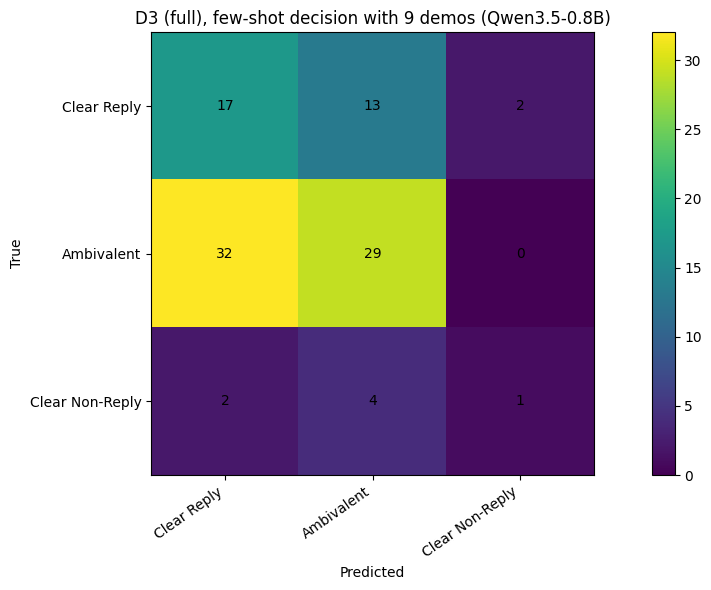

In [67]:
# # Score the few shot decision experiment and record the result
# d3_y_true_fs = fs_decision_df["clarity_label"].tolist()
# d3_y_pred_fs = fs_decision_df["pred_d3"].tolist()
# d3_sec_fs = fs_decision_df["d3_elapsed_sec"].mean()

# d3_fs_decision_result = evaluate_predictions(d3_y_true_fs, d3_y_pred_fs, "D3 (full)", method="few-shot decision (9 demos)", sec_per_example=d3_sec_fs)
# all_results.append(d3_fs_decision_result)

# # Print per-class metrics and confusion matrix
# d3_y_pred_clean_fs = ["INVALID" if p is None else p for p in d3_y_pred_fs]
# title = f"D3 (full), few-shot decision with 9 demos ({BACKBONE})"

# print_full_report(d3_y_true_fs, d3_y_pred_clean_fs, title)
# plot_confusion_matrix(d3_y_true_fs, d3_y_pred_clean_fs, title, f"d3_confusion_matrix_fs_decision_{BACKBONE}.png")

In [68]:
# # # Results table so far
# results_df = pd.DataFrame(all_results)
# display(results_df.round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264


In [69]:
# Recorded results (100-row val subset)
d3_ref_prompts_result = {
  "system": "D3 (full)", "backbone": "Qwen3.5-0.8B", "method": "few-shot decision (9 demos)",
  "accuracy": 0.47, "precision_macro": 0.432, "recall_macro": 0.383, "f1_macro": 0.384, "precision_weighted": 0.515,
  "recall_weighted": 0.47, "f1_weighted": 0.476, "parse_failure_rate": 0.00, "sec_per_example": 31.264,
}

recorded_results.append(d3_ref_prompts_result)
display(pd.DataFrame(recorded_results).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264


### Agent Ablations

We remove agents from the pipeline to measure how much each one helps. The Decision agent (Agent 4) is always kept as it is the one that produces the final label, so we only drop one or more from the three support agents.

Not every combination is useful:
- The Gap & Evasion agent (Agent 3) compares the question content with the answer content, so it only works when **both** Agent 1 and Agent 2 are present. Dropping either feeds Agent 3 empty input and makes it meaningless.
- Keeping only the Decision agent is just a single LLM reading the question and answer, exactly our previous work (LLM Prompting) setup.

So we run two clean ablations and compare them against the full 4-agent baseline:
- **Combo 1:** keep Agents 1, 2, 4, and drop Agent 3. Does the gap-analysis step actually help the decision, or is it extra work for nothing?
- **Combo 2:** keep Agents 2, 4, and drop Agents 1, 3. Is just extracting what the answer says (no question intent, no gap) enough on its own?

A higher score after dropping an agent means that agent was not helping so its output was noise or even misleading the Decision agent, and therefore removing it cleans up the input. A lower score means the agent was contributing useful signal, and the decomposition is worth its cost. A roughly equal score means the agent is mostly ignored by the Decision agent and adds little either way. So Combo 1 tells us whether the gap-analysis step is worth keeping, and Combo 2 tells us whether a simple "read the answer, then decide" pipeline can match the full one. Reading the two together also isolates Agent 1: if Combo 2 scores about the same as Combo 1, then the question-intent step adds little once the gap step is already gone.

D3-Agentic Prompting:   0%|          | 0/100 [00:00<?, ?it/s]

D3 (drop Gap & Evasion), Combo 1 (Qwen3.5-0.8B)
                 precision    recall  f1-score   support

    Clear Reply       0.39      0.88      0.54        32
     Ambivalent       0.76      0.31      0.44        61
Clear Non-Reply       0.25      0.14      0.18         7

       accuracy                           0.48       100
      macro avg       0.47      0.44      0.39       100
   weighted avg       0.61      0.48      0.46       100



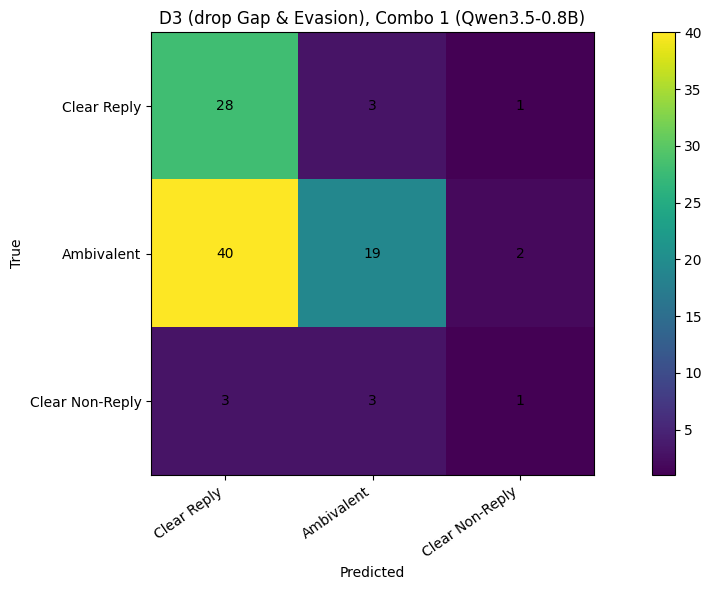

In [70]:
# # Combo 1: drop Gap & Evasion (keep Agents 1, 2, 4)
# combo1_df = run_d3_dataframe(val_df, output_filename=f"d3_validation_combo1_{BACKBONE}.csv", limit=D3_VALID_LIMIT, use_gap=False)

# c1_y_true = combo1_df["clarity_label"].tolist()
# c1_y_pred = combo1_df["pred_d3"].tolist()
# c1_sec = combo1_df["d3_elapsed_sec"].mean()

# c1_result = evaluate_predictions(c1_y_true, c1_y_pred, "D3 (drop Gap)", method="Combo 1: drop Agent 3", sec_per_example=c1_sec)
# all_results.append(c1_result)

# c1_clean = ["INVALID" if p is None else p for p in c1_y_pred]
# title = f"D3 (drop Gap & Evasion), Combo 1 ({BACKBONE})"
# print_full_report(c1_y_true, c1_clean, title)
# plot_confusion_matrix(c1_y_true, c1_clean, title, f"d3_confusion_matrix_combo1_{BACKBONE}.png")

D3-Agentic Prompting:   0%|          | 0/100 [00:00<?, ?it/s]

D3 (drop Intent & Gap & Evasion), Combo 2 (Qwen3.5-0.8B)
                 precision    recall  f1-score   support

    Clear Reply       0.42      0.97      0.58        32
     Ambivalent       0.83      0.33      0.47        61
Clear Non-Reply       0.50      0.14      0.22         7

       accuracy                           0.52       100
      macro avg       0.58      0.48      0.43       100
   weighted avg       0.68      0.52      0.49       100



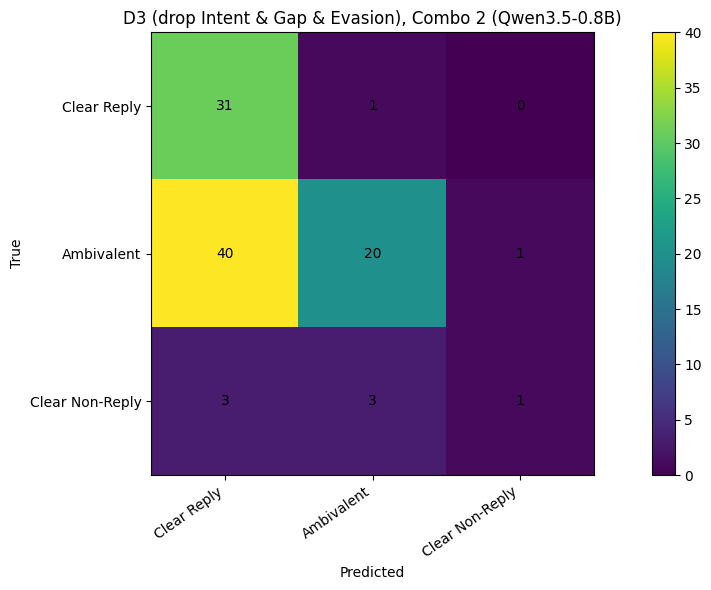

In [71]:
# # Combo 2: drop Question Intent & Gap & Evasion (keep Agents 2, 4)
# combo2_df = run_d3_dataframe(val_df, output_filename=f"d3_validation_combo2_{BACKBONE}.csv", limit=D3_VALID_LIMIT, use_intent=False, use_gap=False)

# c2_y_true = combo2_df["clarity_label"].tolist()
# c2_y_pred = combo2_df["pred_d3"].tolist()
# c2_sec = combo2_df["d3_elapsed_sec"].mean()

# c2_result = evaluate_predictions(c2_y_true, c2_y_pred, "D3 (drop Intent & Gap)", method="Combo 2: drop Agents 1, 3", sec_per_example=c2_sec)
# all_results.append(c2_result)

# c2_clean = ["INVALID" if p is None else p for p in c2_y_pred]
# title = f"D3 (drop Intent & Gap & Evasion), Combo 2 ({BACKBONE})"
# print_full_report(c2_y_true, c2_clean, title)
# plot_confusion_matrix(c2_y_true, c2_clean, title, f"d3_confusion_matrix_combo2_{BACKBONE}.png")

In [72]:
# # Results so far
# results_df = pd.DataFrame(all_results)
# display(results_df.round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030


In [73]:
# Recorded results (100-row val subset) for frozen Agent ablations (Combo 1, Combo 2)
d3_combo1_result = {
  "system": "D3 (drop Gap)", "backbone": "Qwen3.5-0.8B", "method": "Combo 1: drop Agent 3",
  "accuracy": 0.48, "precision_macro": 0.468, "recall_macro": 0.443, "f1_macro": 0.389, "precision_weighted": 0.607,
  "recall_weighted": 0.48, "f1_weighted": 0.456, "parse_failure_rate": 0.00, "sec_per_example": 19.942,
}

d3_combo2_result = {
  "system": "D3 (drop Intent & Gap)", "backbone": "Qwen3.5-0.8B", "method": "Combo 2: drop Agents 1, 3",
  "accuracy": 0.52, "precision_macro": 0.584, "recall_macro": 0.480, "f1_macro": 0.426, "precision_weighted": 0.677,
  "recall_weighted": 0.52, "f1_weighted": 0.490, "parse_failure_rate": 0.00, "sec_per_example": 14.030,
}

recorded_results.append(d3_combo1_result)
recorded_results.append(d3_combo2_result)
display(pd.DataFrame(recorded_results).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030


### Architecture Variant: Merged Analysis Agent (Agent 5)

Instead of three separate extraction agents (Question Intent → Answer Content → Gap & Evasion), we try a single agent (Agent 5) that reads the question and answer directly and produces the gap/evasion analysis in one step. Its output goes straight to the Decision agent (Agent 5 → Agent 4).

This tests whether the fine 1→2→3 decomposition is worth it, or whether one agent can do the analysis just as well in a single pass.

In [74]:
MERGED_ANALYSIS_SYSTEM_PROMPT = """
You are the Merged Analysis Agent for response-clarity classification.

You receive:
1. the TARGET_QUESTION,
2. the answer.

Your task:
In a single step, work out what the target question requires and what the answer actually provides, then compare them and detect any gap or evasion.

Important distinction:
- Missing small detail but mostly answering -> minor gap.
- Some relevant information but vague, incomplete, generic, or indirect -> partial gap.
- Mostly answering another topic, refusing, or avoiding the target question -> major gap.

Use these evasion categories when useful:
- explicit_answer: directly answers the target question.
- implicit_answer: not in requested form, but enough information is provided.
- partial_half_answer: answers only part of what was asked.
- general_answer: gives broad values/principles but lacks the requested specifics.
- dodging: avoids the precise target question while saying related things.
- deflection: redirects to another issue/person/topic.
- declining_to_answer: refuses, says cannot comment, or avoids due to confidentiality.
- claims_ignorance: says they do not know or cannot assess.
- clarification_only: asks for clarification or corrects framing without answering.
- irrelevant: no meaningful relation to the target question.

Do not assign the final top-level label.
Return exactly one JSON object and nothing else.

JSON schema:
{
  "coverage": "complete|mostly_complete|partial|minimal|none",
  "gap_level": "none|minor|partial|major",
  "best_evasion_category": "explicit_answer|implicit_answer|partial_half_answer|general_answer|dodging|deflection|declining_to_answer|claims_ignorance|clarification_only|irrelevant",
  "missing_requirements": [
    "what the answer fails to provide"
  ],
  "evidence_for_answering": [
    "short evidence from the answer"
  ],
  "evidence_for_evasion_or_gap": [
    "short evidence from the answer"
  ],
  "gap_explanation": "one concise sentence"
}
""".strip()

In [75]:
# print(MERGED_ANALYSIS_SYSTEM_PROMPT)
print(f"Tokens: {len(tokenizer.encode(MERGED_ANALYSIS_SYSTEM_PROMPT))}")

Tokens: 455


In [76]:
def run_merged_analysis_agent(question, answer, max_new_tokens=A3_MAX_NEW_TOKENS):
  """
  Run the Merged Analysis Agent (Agent 5) on one (question, answer) pair. Reads the question and answer directly and produces the gap/evasion analysis in one step. Same output schema as the Gap & Evasion agent.

  Args:
    question: the target interview sub-question
    answer: the politician's answer
    max_new_tokens: cap on generated tokens (defaults to the Gap & Evasion cap, same schema)

  Return:
    obj: parsed JSON dict with the gap/evasion analysis (plus "raw")
    stats: generation stats from generate_chat
  """
  messages = [
      {"role": "system", "content": MERGED_ANALYSIS_SYSTEM_PROMPT},
      {"role": "user", "content": f"Question:\n{question}\n\nAnswer:\n{answer}"},
  ]
  raw, stats = generate_chat(messages, max_new_tokens=max_new_tokens)

  obj = extract_json_object(raw)
  obj["raw"] = raw
  return obj, stats

In [77]:
def run_merged_one(question, answer):
  """
  Run the merged-analysis variant on one (question, answer) pair: new Agent 5 -> Agent 4. New Agent 5 produces the gap/evasion analysis directly from Q and A, and the Decision agent assigns the final label from it. Agents 1 and 2 are not used (passed as {}).

  Args:
    question: the target interview sub-question
    answer: the politician's answer

  Return:
    A dict with Agent 5's output, the Decision output, the final label (pred_d3), and total time (d3_elapsed_sec)
  """
  merged_analysis, s5 = run_merged_analysis_agent(question, answer)
  decision, s4 = run_decision_agent(question, answer, {}, {}, merged_analysis)

  return {
      "d3_merged_analysis": merged_analysis,
      "d3_decision": decision,
      "pred_d3": decision["label"],
      "d3_elapsed_sec": s5["elapsed_sec"] + s4["elapsed_sec"],
  }


def run_merged_dataframe(df, output_filename, limit=None, checkpoint_every=25):
  """
  Run the merged-analysis variant (new Agent 5 -> Agent 4) over a DataFrame, with checkpointing.

  Args:
    df: DataFrame with "question" and "interview_answer" columns
    output_filename: CSV filename to save results to
    limit: if set, only process the first `limit` rows (None = all)
    checkpoint_every: save partial results every N rows

  Return:
    result_df: copy of the processed rows with the variant output columns added
  """
  run_df = df.copy()
  if limit is not None:
    run_df = run_df.head(limit).copy()

  rows = []
  for _, row in tqdm(run_df.iterrows(), total=len(run_df), desc="Merged Analysis (Agent 5)"):
    out = run_merged_one(str(row["question"]), str(row["interview_answer"]))

    rows.append({
        "d3_merged_analysis": json.dumps(out["d3_merged_analysis"], ensure_ascii=False),
        "d3_decision": json.dumps(out["d3_decision"], ensure_ascii=False),
        "pred_d3": out["pred_d3"],
        "d3_elapsed_sec": out["d3_elapsed_sec"],
    })

    if len(rows) % checkpoint_every == 0:
      checkpoint_df = pd.concat([run_df.iloc[:len(rows)].reset_index(drop=True), pd.DataFrame(rows)], axis=1)
      checkpoint_df.to_csv(output_filename, index=False)

  result_df = pd.concat([run_df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
  result_df.to_csv(output_filename, index=False)
  return result_df

Merged Analysis (Agent 5):   0%|          | 0/100 [00:00<?, ?it/s]

D3 (merged), merged analysis (Qwen3.5-0.8B)
                 precision    recall  f1-score   support

    Clear Reply       0.58      0.22      0.32        32
     Ambivalent       0.64      0.87      0.74        61
Clear Non-Reply       0.20      0.14      0.17         7

       accuracy                           0.61       100
      macro avg       0.47      0.41      0.41       100
   weighted avg       0.59      0.61      0.56       100



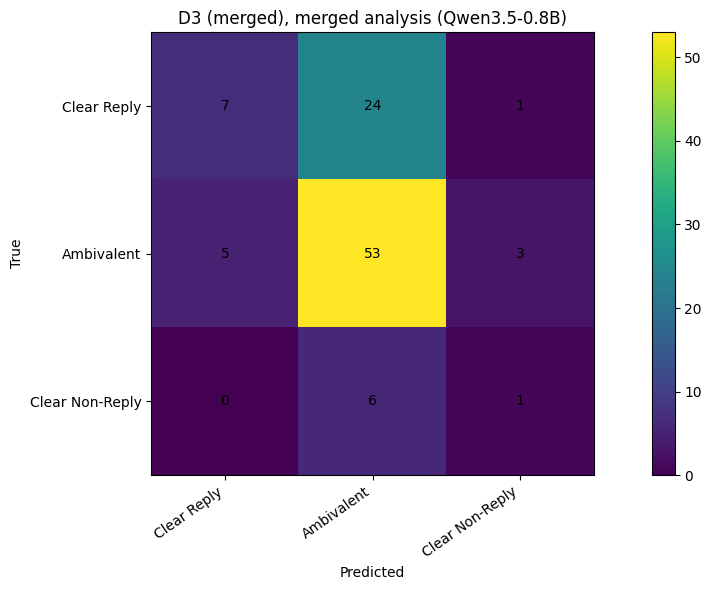

In [78]:
# # Run architecture variant: Merged Analysis Agent (new Agent 5 -> Agent 4)
# merged_df = run_merged_dataframe(val_df, output_filename=f"d3_validation_merged_{BACKBONE}.csv", limit=D3_VALID_LIMIT, checkpoint_every=25)

# m_y_true = merged_df["clarity_label"].tolist()
# m_y_pred = merged_df["pred_d3"].tolist()
# m_sec = merged_df["d3_elapsed_sec"].mean()

# m_result = evaluate_predictions(m_y_true, m_y_pred, "D3 (merged)", method="merged analysis", sec_per_example=m_sec)
# all_results.append(m_result)

# m_clean = ["INVALID" if p is None else p for p in m_y_pred]
# title = f"D3 (merged), merged analysis ({BACKBONE})"
# print_full_report(m_y_true, m_clean, title)
# plot_confusion_matrix(m_y_true, m_clean, title, f"d3_confusion_matrix_merged_{BACKBONE}.png")

In [79]:
# # Results so far
# results_df = pd.DataFrame(all_results)
# display(results_df.round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030
4,D3 (merged),Qwen3.5-0.8B,merged analysis,0.61,0.474,0.410,0.407,0.590,0.61,0.563,0.0,18.058


In [80]:
# Recorded results (100-row val subset) for frozen Architecture variant (Merged Analysis)
d3_merged_result = {
  "system": "D3 (merged)", "backbone": "Qwen3.5-0.8B", "method": "merged analysis",
  "accuracy": 0.61, "precision_macro": 0.474, "recall_macro": 0.410, "f1_macro": 0.407, "precision_weighted": 0.590,
  "recall_weighted": 0.61, "f1_weighted": 0.563, "parse_failure_rate": 0.00, "sec_per_example": 18.058,
}

recorded_results.append(d3_merged_result)
display(pd.DataFrame(recorded_results).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030
4,D3 (merged),Qwen3.5-0.8B,merged analysis,0.61,0.474,0.410,0.407,0.590,0.61,0.563,0.0,18.058


### Manual Prompt Optimization

The ablations show Agent 3 contributes almost nothing and Agent 4's rules push borderline answers away from Clear Non-Reply. We hand-rewrite two prompts: Agent 3 to output a strict complete/partial/none coverage signal that treats postponements, refusals, and clarification-only replies as none, and Agent 4 to act on that signal and stop preferring Ambivalent. We test each alone, then together, against the full baseline.

In [82]:
GAP_EVASION_SYSTEM_PROMPT_V2 = """
You are the Gap and Evasion Agent for response-clarity classification.
You receive the TARGET_QUESTION, the answer, and the Question Intent and Answer Content outputs.

Decide how much of the TARGET_QUESTION the answer actually resolves. Be strict: fluent, long, or on-topic-sounding text is NOT the same as answering.

coverage must be exactly one of:
- "complete": resolves the target question (directly or with enough implied info).
- "partial": some relevant info, but vague, generic, one-sided, or only part of what was asked.
- "none": does NOT resolve it. This INCLUDES postponing ("I'll discuss later", "we'll see",
  "decide at the time"), refusing, declining, claiming ignorance, asking for clarification,
  only restating the question, or redirecting to another topic.

Set "answers_target_question" true only if coverage is "complete", else false.
A postponement or "details later" is deflection, not explicit_answer.

Do not assign the final label. Return exactly one JSON object and nothing else.

JSON schema:
{
  "coverage": "complete|partial|none",
  "answers_target_question": true,
  "best_evasion_category": "explicit_answer|implicit_answer|partial_half_answer|general_answer|dodging|deflection|declining_to_answer|claims_ignorance|clarification_only|irrelevant",
  "missing_requirements": ["..."],
  "evidence_for_evasion_or_gap": ["..."],
  "gap_explanation": "one concise sentence"
}
""".strip()

In [83]:
DECISION_SYSTEM_PROMPT_V2 = """
You are the Decision Agent for CLARITY response classification.
Assign exactly one label: Clear Reply, Ambivalent, or Clear Non-Reply.

Judge only the TARGET_QUESTION. A fluent or politically detailed answer is not a Clear Reply unless it actually resolves the target question.

Use the Gap & Evasion signal:
- coverage "complete" (answers_target_question true) -> Clear Reply.
- coverage "partial" -> Ambivalent.
- coverage "none" -> Clear Non-Reply.

Clear Non-Reply is common. Treat these as Clear Non-Reply even if the answer sounds cooperative:
postpones ("details later", "we'll see"), refuses/declines, claims ignorance ("we don't know yet"),
asks for clarification or only restates the question, or redirects to a different topic.

Use Ambivalent only when there is real on-target information that is incomplete or vague, never for deflections.

Return exactly one JSON object and nothing else.

JSON schema:
{
  "label": "Clear Reply|Ambivalent|Clear Non-Reply",
  "confidence": 0.0,
  "main_reason": "one concise sentence",
  "used_rule": "short description of the rule that determined the label"
}
""".strip()

In [84]:
# # M1 run (Agent 3 v2 only)
# m1 = run_d3_dataframe(val_df, f"d3_val_gapV2_{BACKBONE}.csv", limit=D3_VALID_LIMIT, gap_prompt=GAP_EVASION_SYSTEM_PROMPT_V2)

# # Evaluate
# m1_yt = m1["clarity_label"].tolist()
# m1_yp = m1["pred_d3"].tolist()
# m1_sec = m1["d3_elapsed_sec"].mean()
# m1_result = evaluate_predictions(m1_yt, m1_yp, "D3 (full)", method="manual: Agent 3 v2", sec_per_example=m1_sec)
# all_results.append(m1_result)

# # Print per-class metrics and confusion matrix
# print(classification_report(m1_yt, ["INVALID" if p is None else p for p in m1_yp], labels=VALID_LABELS, zero_division=0))

D3-Agentic Prompting:   0%|          | 0/100 [00:00<?, ?it/s]

                 precision    recall  f1-score   support

    Clear Reply       0.36      1.00      0.53        32
     Ambivalent       0.70      0.11      0.20        61
Clear Non-Reply       1.00      0.14      0.25         7

       accuracy                           0.40       100
      macro avg       0.69      0.42      0.33       100
   weighted avg       0.61      0.40      0.31       100



In [85]:
# # M2 run (Agent 4 v2 only)
# m2 = run_d3_dataframe(val_df, f"d3_val_decV2_{BACKBONE}.csv", limit=D3_VALID_LIMIT, decision_prompt=DECISION_SYSTEM_PROMPT_V2)

# # Evaluate
# m2_yt = m2["clarity_label"].tolist()
# m2_yp = m2["pred_d3"].tolist()
# m2_sec = m2["d3_elapsed_sec"].mean()
# m2_result = evaluate_predictions(m2_yt, m2_yp, "D3 (full)", method="manual: Agent 4 v2", sec_per_example=m2_sec)
# all_results.append(m2_result)

# # Print per-class metrics and confusion matrix
# print(classification_report(m2_yt, ["INVALID" if p is None else p for p in m2_yp], labels=VALID_LABELS, zero_division=0))

D3-Agentic Prompting:   0%|          | 0/100 [00:00<?, ?it/s]

                 precision    recall  f1-score   support

    Clear Reply       0.34      0.66      0.45        32
     Ambivalent       0.55      0.10      0.17        61
Clear Non-Reply       0.11      0.43      0.18         7

       accuracy                           0.30       100
      macro avg       0.33      0.39      0.26       100
   weighted avg       0.45      0.30      0.26       100



In [86]:
# # M3 run (Agent 3 v2 + Agent 4 v2)
# m3 = run_d3_dataframe(val_df, f"d3_val_gapV2_decV2_{BACKBONE}.csv", limit=D3_VALID_LIMIT, gap_prompt=GAP_EVASION_SYSTEM_PROMPT_V2, decision_prompt=DECISION_SYSTEM_PROMPT_V2)

# # Evaluate
# m3_yt = m3["clarity_label"].tolist()
# m3_yp = m3["pred_d3"].tolist()
# m3_sec = m3["d3_elapsed_sec"].mean()
# m3_result = evaluate_predictions(m3_yt, m3_yp, "D3 (full)", method="manual: Agent 3 v2 + Agent 4 v2", sec_per_example=m3_sec)
# all_results.append(m3_result)

# # Print per-class metrics and confusion matrix
# print(classification_report(m3_yt, ["INVALID" if p is None else p for p in m3_yp], labels=VALID_LABELS, zero_division=0))

D3-Agentic Prompting:   0%|          | 0/100 [00:00<?, ?it/s]

                 precision    recall  f1-score   support

    Clear Reply       0.36      1.00      0.52        32
     Ambivalent       0.75      0.05      0.09        61
Clear Non-Reply       0.50      0.43      0.46         7

       accuracy                           0.38       100
      macro avg       0.54      0.49      0.36       100
   weighted avg       0.61      0.38      0.26       100



In [87]:
# # All results so far
# display(pd.DataFrame(all_results).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030
4,D3 (merged),Qwen3.5-0.8B,merged analysis,0.61,0.474,0.410,0.407,0.590,0.61,0.563,0.0,18.058
5,D3 (full),Qwen3.5-0.8B,manual: Agent 3 v2,0.40,0.687,0.419,0.325,0.612,0.40,0.307,0.0,26.036
6,D3 (full),Qwen3.5-0.8B,manual: Agent 4 v2,0.30,0.332,0.394,0.263,0.449,0.30,0.257,0.0,28.603
7,D3 (full),Qwen3.5-0.8B,manual: Agent 3 v2 + Agent 4 v2,0.38,0.535,0.493,0.359,0.606,0.38,0.256,0.0,23.762


In [88]:
# Recorded results (100-row val subset) for manual prompt optimization
m1_result = {
  "system": "D3 (full)", "backbone": "Qwen3.5-0.8B", "method": "m1 Agent 3 v2",
  "accuracy": 0.40, "precision_macro": 0.687, "recall_macro": 0.419, "f1_macro": 0.325, "precision_weighted": 0.612,
  "recall_weighted": 0.40, "f1_weighted": 0.307, "parse_failure_rate": 0.00, "sec_per_example": 26.036,
}

m2_result = {
  "system": "D3 (full)", "backbone": "Qwen3.5-0.8B", "method": "m2 Agent 4 v2",
  "accuracy": 0.30, "precision_macro": 0.332, "recall_macro": 0.394, "f1_macro": 0.263, "precision_weighted": 0.449,
  "recall_weighted": 0.30, "f1_weighted": 0.257, "parse_failure_rate": 0.00, "sec_per_example": 28.603,
}

m3_result = {
  "system": "D3 (full)", "backbone": "Qwen3.5-0.8B", "method": "m3 Agents 3 + 4 v2",
  "accuracy": 0.38, "precision_macro": 0.535, "recall_macro": 0.493, "f1_macro": 0.359, "precision_weighted": 0.606,
  "recall_weighted": 0.38, "f1_weighted": 0.256, "parse_failure_rate": 0.00, "sec_per_example": 23.762,
}

recorded_results.append(m1_result)
recorded_results.append(m2_result)
recorded_results.append(m3_result)
display(pd.DataFrame(recorded_results).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030
4,D3 (merged),Qwen3.5-0.8B,merged analysis,0.61,0.474,0.410,0.407,0.590,0.61,0.563,0.0,18.058
5,D3 (full),Qwen3.5-0.8B,m1 Agent 3 v2,0.40,0.687,0.419,0.325,0.612,0.40,0.307,0.0,26.036
6,D3 (full),Qwen3.5-0.8B,m2 Agent 4 v2,0.30,0.332,0.394,0.263,0.449,0.30,0.257,0.0,28.603
7,D3 (full),Qwen3.5-0.8B,m3 Agents 3 + 4 v2,0.38,0.535,0.493,0.359,0.606,0.38,0.256,0.0,23.762


### Prompt Optimization (DSPy)

DSPy lets us **optimize an agent's prompt automatically** instead of hand-tuning it. We describe an agent's task, inputs, and outputs (a *Signature*), wrap it in a *Module*, then an *optimizer* searches for few-shot examples that raise our score.

We focus prompt optimization on the Gap & Evasion agent (Agent 3), guided by the above results. Removing the gap-analysis step caused the largest drop in macro F1, identifying Agent 3 as the component carrying the most signal and the one whose improvement should most affect the final score. The Decision agent could be a natural second target, since it converts the upstream analysis into the final label and drives the dominant error pattern across variants, but we skip it here. Removing the Question Intent agent (Agent 1) had little effect, so we keep it fixed and focus on the two agents.

We primarily optimize the Gap & Evasion agent (Agent 3), since removing the gap-analysis step caused a largest drop in macro F1, regarding the two agent ablations experiments, marking it as the component carrying the most signal. We try several optimizers on it (BootstrapFewShot, RandomSearch, and MIPROv2). We additionally optimize the Question Intent agent (Agent 1) with BootstrapFewShot, and the Decision agent (Agent 4) with MIPROv2, the last because it converts the upstream analysis into the final label and drives the dominant error pattern across variants.

In [134]:
# Install DSPy
!pip install -q dspy-ai

In [135]:
import dspy
print(dspy.__version__)

3.2.1


#### Wrap the local model for DSPy

DSPy talks to models in an OpenAI-style format, so we wrap our local Qwen in a small adapter (`KaggleQwenDSPyLM`) and a helper dict (`AttrDict`) that lets DSPy read the reply with dotted access.

In [136]:
class AttrDict(dict):
  """
  A dict that also allows attribute access, so both response["choices"] and response.choices work. Needed because DSPy reads the reply OpenAI-style (response.choices[0].message.content), which a plain dict does not support.

  Args:
    dict: a regular Python dict
  """

  def __getattr__(self, name):
    # Lets DSPy read a key with a dot (response.choices -> self["choices"])
    try:
      return self[name]
    except KeyError:
      raise AttributeError(name)

  def __setattr__(self, name, value):
    # Lets a dotted write become a key (resp.model = x -> self["model"] = x)
    self[name] = value


class KaggleQwenDSPyLM(dspy.BaseLM):
  """
  Custom DSPy language model that routes DSPy calls to our local Qwen via generate_chat.

  Args:
    model_name: label only, identifies this LM in DSPy logs
  """

  def __init__(self, model_name="local-qwen3.5-0.8b"):
    # cache=False + temperature=0.0 keep runs reproducible; max_tokens is a default, overridden per call
    super().__init__(model=model_name, model_type="chat", cache=False, temperature=0.0, max_tokens=512)
    self.model_name = model_name

  def forward(self, prompt=None, messages=None, **kwargs):
    """
    Run our local model and return an OpenAI-shaped reply object DSPy can parse.

    Args:
      prompt: single-string prompt (DSPy may send this instead of messages)
      messages: list of chat-turn dicts (system/user/assistant)
      kwargs: extra settings DSPy passes, e.g. max_tokens

    Return:
      AttrDict shaped like an OpenAI chat completion, holding the reply text
    """
    if messages is None:
      messages = [{"role": "user", "content": prompt or ""}]

    max_new_tokens = kwargs.get("max_tokens", kwargs.get("max_new_tokens", 512))

    reply_text, _ = generate_chat(messages, max_new_tokens=max_new_tokens) # Unpack (reply, stats), keep text

    return AttrDict({
        "id": f"chatcmpl-local-{int(time.time() * 1000)}",
        "object": "chat.completion",
        "created": int(time.time()),
        "model": self.model_name,
        "choices": [
            AttrDict({
                "index": 0,
                "message": AttrDict({"role": "assistant", "content": reply_text}),
                "text": reply_text,
                "finish_reason": "stop",
            })
        ],
        "usage": AttrDict({"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}),
    })

In [137]:
# Register our local Qwen as DSPy's model for all later calls
dspy_lm = KaggleQwenDSPyLM()
# dspy.configure(lm=dspy_lm)
dspy.configure(lm=dspy_lm, adapter=dspy.ChatAdapter())

In [94]:
# # Test AttrDict
# demo = AttrDict({"model": "qwen", "choices": ["a", "b"]})

# # Read
# print("bracket read demo['model']:", demo["model"])
# print("dotted read demo.model:", demo.model)
# print("same value?:", demo["model"] == demo.model)

# # Write
# demo.temperature = 0.0
# print("after dotted write, demo['temperature']:", demo["temperature"])
# print("still a real dict?:", isinstance(demo, dict), "| keys:", list(demo.keys()))

# # Nested OpenAI shape with DSPy
# reply = AttrDict({"choices": [AttrDict({"message": AttrDict({"content": "Clear Reply"})})]})
# print("DSPy-style reply.choices[0].message.content:", reply.choices[0].message.content)

In [138]:
# # Test the wrapper with one tiny call

# # Generated text by dspy_lm
# parsed = dspy_lm(messages=[{"role": "user", "content": "Reply with the single word: ok"}])
# print("DSPy's view (parsed text list):", parsed)

# # Full OpenAI-shaped object our forward() returned
# raw = dspy_lm.history[-1]["response"] # DSPy logs the whole call into dspy_lm.history
# print("row fields:", raw.keys())
# print("raw type:", type(raw).__name__)
# print("raw.model:", raw.model)
# print("raw.choices[0].message.content:", raw.choices[0].message.content)
# print("raw.usage:", raw.usage)

#### Define the agent Signatures

A **Signature** is the formal description of an LLM call: its **task** (the docstring), its **inputs**, and its **outputs**. We say *what* we want, not *how* and DSPy reads the signature, builds the prompt, and optimizes it for us.

In [139]:
# Agent 1 (Question Intent) signature
class QuestionIntentSignature(dspy.Signature):
  """
  Analyze the TARGET_QUESTION for response-clarity classification.

  Important:
  The TARGET_QUESTION may be one sub-question extracted from a longer interview question.
  Analyze what information is required to clearly answer the TARGET_QUESTION.
  Do not classify the answer.
  Do not judge whether the answer is good.
  """
  full_interview_question = dspy.InputField(desc="The original full interview question. Use only as context.")
  target_question = dspy.InputField(desc="The specific target sub-question that must be evaluated.")
  question_type_hint = dspy.InputField(desc="A simple heuristic hint such as yes_no, why, how, what, stance, or other.")

  question_type = dspy.OutputField(desc="One of: yes_no, what, why, how, when, where, who, stance, explanation, action_plan, evaluation, other.")
  question_intent = dspy.OutputField(desc="One sentence describing exactly what the target question asks.")
  must_address = dspy.OutputField(desc="A semicolon-separated list of the specific information a clear answer must provide.")
  clear_answer_criteria = dspy.OutputField(desc="One sentence describing what would count as a clear answer.")
  minimal_sufficient_answer = dspy.OutputField(desc="The minimum information needed for the answer to be a Clear Reply.")

In [ ]:
# # Signature sanity check for Agent 1
# qi_predict = dspy.Predict(QuestionIntentSignature)

# print("Question:", example_row["question"], "\n")

# try:
#   pred = qi_predict(target_question=str(example_row["question"]))
#   print("question_type:", pred.question_type)
#   print("question_intent:", pred.question_intent)
#   print("must_address:", pred.must_address)
#   print("clear_answer_criteria:", pred.clear_answer_criteria)
#   print("minimal_sufficient_answer:", pred.minimal_sufficient_answer)
# except Exception as e:
#   # If DSPy can't parse the 5 fields, show the raw model text so we can see what it produced
#   print("Parse failed:", type(e).__name__)
#   print("Raw model output:", dspy_lm.history[-1]["response"].choices[0].message.content)

In [140]:
# Agent 3 (Gap and Evasion) signature
class GapEvasionSignature(dspy.Signature):
  """
  Compare what the target question requires with what the answer provides, and detect missing parts, partial answers, or evasion.

  Distinguish: a small missing detail (minor gap) from vague or indirect information (partial gap) from answering another topic, refusing, or avoiding the question (major gap).

  Do not assign the final response-clarity label.
  """
  target_question = dspy.InputField(desc="The specific question to analyze.")
  answer = dspy.InputField(desc="The politician's answer.")
  question_intent = dspy.InputField(desc="Question Intent agent output: what a clear answer must provide.")
  answer_content = dspy.InputField(desc="Answer Content agent output: what the answer actually says.")

  coverage = dspy.OutputField(desc="One of: complete, mostly_complete, partial, minimal, none.")
  gap_level = dspy.OutputField(desc="One of: none, minor, partial, major.")
  best_evasion_category = dspy.OutputField(desc="One of: explicit_answer, implicit_answer, partial_half_answer, general_answer, dodging, deflection, declining_to_answer, claims_ignorance, clarification_only, irrelevant.")
  missing_requirements = dspy.OutputField(desc="Semicolon-separated list of requirements the answer fails to provide.")
  gap_explanation = dspy.OutputField(desc="One sentence explaining the main gap or why the answer is clear.")

In [123]:
# # Signature sanity check for Agent 3
# g3_predict = dspy.Predict(GapEvasionSignature)

# print("Question:", example_row["question"], "\n")
# print("Answer:", example_row["interview_answer"], "\n")

# # Agent 3 needs the upstream outputs, so run the real Agents 1-2 first
# intent_obj, _ = run_question_intent_agent(str(example_row["question"]))
# content_obj, _ = run_answer_content_agent(str(example_row["question"]), str(example_row["interview_answer"]))

# print("Question Intent:", intent_obj)
# print("Answer Content:", content_obj)

# try:
#   pred = g3_predict(
#       target_question=str(example_row["question"]),
#       answer=str(example_row["interview_answer"]),
#       question_intent=json.dumps(intent_obj, ensure_ascii=False),
#       answer_content=json.dumps(content_obj, ensure_ascii=False),
#   )
#   print("coverage:", pred.coverage)
#   print("gap_level:", pred.gap_level)
#   print("best_evasion_category:", pred.best_evasion_category)
#   print("missing_requirements:", pred.missing_requirements)
#   print("gap_explanation:", pred.gap_explanation)
# except Exception as e:
#   # If DSPy can't parse the fields, show the raw model text so we can see what it produced
#   print("Parse failed:", type(e).__name__)
#   print("Raw model output:", dspy_lm.history[-1]["response"].choices[0].message.content)

In [175]:
# Agent 4 (Decision) signature
class DecisionSignature(dspy.Signature):
  """
  Assign the final response-clarity label using the question, answer, and the three agent outputs.
  Output exactly one of: Clear Reply, Ambivalent, Clear Non-Reply.
  Do not invent new labels.
  """
  question = dspy.InputField(desc="The target question.")
  answer = dspy.InputField(desc="The interview answer.")
  question_intent = dspy.InputField(desc="JSON output of the Question Intent agent.")
  answer_content = dspy.InputField(desc="JSON output of the Answer Content agent.")
  gap_evasion = dspy.InputField(desc="JSON output of the Gap and Evasion agent.")

  label = dspy.OutputField(desc="One of: Clear Reply, Ambivalent, Clear Non-Reply.")
  rationale = dspy.OutputField(desc="One short sentence justifying the label.")

In [ ]:
# # Signature sanity check for Agent 4 (reuse agents 1-3 outputs)
# dec_predict = dspy.Predict(DecisionSignature)

# try:
#   pred = dec_predict(
#       question=str(example_row["question"]),
#       answer=str(example_row["interview_answer"]),
#       question_intent=json.dumps(intent_obj, ensure_ascii=False),
#       answer_content=json.dumps(content_obj, ensure_ascii=False),
#       gap_evasion=json.dumps(gap_obj, ensure_ascii=False),
#   )
#   print("label:", pred.label)
#   print("gold :", example_row["clarity_label"])
# except Exception as e:
#   print("Parse failed:", type(e).__name__)
#   print("Raw model output:", dspy_lm.history[-1]["response"].choices[0].message.content)

#### Build the agent Modules

A **Module** wraps a signature into a runnable agent, the unit we actually call and that the optimizer tunes.

In [141]:
# Agent 1 (Question Intent) module
class DSPyQuestionIntentAgent(dspy.Module):

  def __init__(self):
    super().__init__()
    self.predict = dspy.Predict(QuestionIntentSignature)

  def forward(self, full_interview_question, target_question, question_type_hint, answer=None, label=None):
    qi = self.predict(
        full_interview_question=full_interview_question,
        target_question=target_question,
        question_type_hint=question_type_hint,
    )
    return dspy.Prediction(
        question_type=getattr(qi, "question_type", "other"),
        question_intent=getattr(qi, "question_intent", ""),
        must_address=getattr(qi, "must_address", ""),
        clear_answer_criteria=getattr(qi, "clear_answer_criteria", ""),
        minimal_sufficient_answer=getattr(qi, "minimal_sufficient_answer", ""),
    )

In [ ]:
# # Module sanity check for Agent 1
# qi_agent = DSPyQuestionIntentAgent()
# out = qi_agent(target_question=str(example_row["question"]))
# print("question_type:", out.question_type)
# print("question_intent:", out.question_intent)

In [142]:
# Agent 3 (Gap and Evasion) module
class DSPyGapEvasionAgent(dspy.Module):

  def __init__(self):
    super().__init__()
    self.predict = dspy.Predict(GapEvasionSignature)

  def forward(self, target_question, answer, question_intent, answer_content):
    ge = self.predict(
        target_question=target_question,
        answer=answer,
        question_intent=question_intent,
        answer_content=answer_content,
    )
    return dspy.Prediction(
        coverage=getattr(ge, "coverage", "partial"),
        gap_level=getattr(ge, "gap_level", "partial"),
        best_evasion_category=getattr(ge, "best_evasion_category", "general_answer"),
        missing_requirements=getattr(ge, "missing_requirements", ""),
        gap_explanation=getattr(ge, "gap_explanation", ""),
    )

In [127]:
# # Module sanity check for Agent 3
# ge_agent = DSPyGapEvasionAgent()
# out = ge_agent(
#     target_question=str(example_row["question"]),
#     answer=str(example_row["interview_answer"]),
#     question_intent=json.dumps(intent_obj, ensure_ascii=False),
#     answer_content=json.dumps(content_obj, ensure_ascii=False),
# )
# print("coverage:", out.coverage)
# print("gap_level:", out.gap_level)
# print("best_evasion_category:", out.best_evasion_category)

In [176]:
# Agent 4 (Decision) module
class DSPyDecisionAgent(dspy.Module):

  def __init__(self):
    super().__init__()
    self.predict = dspy.Predict(DecisionSignature)

  def forward(self, question, answer, question_intent, answer_content, gap_evasion):
    out = self.predict(
        question=question,
        answer=answer,
        question_intent=question_intent,
        answer_content=answer_content,
        gap_evasion=gap_evasion,
    )
    return dspy.Prediction(
        label=getattr(out, "label", ""),
        rationale=getattr(out, "rationale", ""),
    )

In [ ]:
# # Module sanity check for Agent 4
# dec_agent = DSPyDecisionAgent()
# out = dec_agent(
#     question=str(example_row["question"]),
#     answer=str(example_row["interview_answer"]),
#     question_intent=json.dumps(intent_obj, ensure_ascii=False),
#     answer_content=json.dumps(content_obj, ensure_ascii=False),
#     gap_evasion=json.dumps(gap_obj, ensure_ascii=False),
# )
# print("label:", out.label)
# print("gold:", example_row["clarity_label"])

#### Define the optimization metric

To evaluate an agent we need a score, but our gold standard only has the final clarity label (Clear Reply, Ambivalent, Clear Non-Reply), not the output of the intermediate agents. So we score it indirectly: run the full D3 pipeline with the agent in place and check the final label. To do this we define a runner that produces the final label, and the metric that compares it to the gold.

In [177]:
# Converter helpers
def parse_semicolon_or_lines(text):
  """
  Split a free-text field into a short list of items. DSPy returns list-type fields as one string, but the pipeline expects a list, so we split on semicolons, newlines, or dash bullets.

  Example: "must_address": ["nuclear power; offshore drilling; free trade"] -> ["nuclear power", "offshore drilling", "free trade"]

  Args:
    text: the raw string from a DSPy output field

  Return:
    A list of cleaned items (at most 5), or [] if empty
  """
  if text is None:
    return []

  cleaned = str(text).strip()
  if not cleaned:
    return []

  parts = re.split(r";|\n|(?:^|\s)-\s+", cleaned)
  parts = [p.strip(" -•\t") for p in parts if p.strip(" -•\t")]
  return parts[:5]


def dspy_qi_prediction_to_dict(pred):
  """
  Convert a DSPy Question Intent prediction into the dict the pipeline expects. Rebuilds the same five fields the original Question Intent agent produced, so the downstream agents see the same shape.

  Args:
    pred: the dspy.Prediction returned by the DSPy Question Intent module

  Return:
    A dict with the five question-intent fields, plus a source tag
  """
  return {
      "question_type": str(getattr(pred, "question_type", "other")).strip(),
      "question_intent": str(getattr(pred, "question_intent", "")).strip(),
      "must_address": parse_semicolon_or_lines(getattr(pred, "must_address", "")),
      "clear_answer_criteria": str(getattr(pred, "clear_answer_criteria", "")).strip(),
      "minimal_sufficient_answer": str(getattr(pred, "minimal_sufficient_answer", "")).strip(),
      "source": "dspy_optimized_question_intent",
  }


def dspy_gap_prediction_to_dict(pred):
  """
  Convert a DSPy Gap and Evasion prediction into the dict the pipeline expects. Rebuilds the fields the original Gap and Evasion agent produced, so the Decision agent sees the same shape.

  Args:
    pred: the dspy.Prediction returned by the DSPy Gap and Evasion module

  Return:
    A dict with the gap-and-evasion fields, plus a source tag
  """
  return {
      "coverage": str(getattr(pred, "coverage", "partial")).strip(),
      "gap_level": str(getattr(pred, "gap_level", "partial")).strip(),
      "best_evasion_category": str(getattr(pred, "best_evasion_category", "general_answer")).strip(),
      "missing_requirements": parse_semicolon_or_lines(getattr(pred, "missing_requirements", "")),
      "gap_explanation": str(getattr(pred, "gap_explanation", "")).strip(),
      "source": "dspy_optimized_gap_evasion",
  }


def dspy_decision_prediction_to_dict(pred):
  """
  Convert a DSPy Decision prediction into the dict the pipeline expects.

  Args:
     pred (dspy.Prediction)

  Return:
     dict with label, confidence, rationale, raw, source
  """
  return {
      "label": normalize_prediction_label(getattr(pred, "label", "")),
      "confidence": None,
      "rationale": str(getattr(pred, "rationale", "")).strip(),
      "raw": str(pred),
      "source": "dspy_optimized_decision",
  }

In [145]:
def run_d3_with_dspy_qi_program(example, qi_program):
  """
  Run the whole pipeline on one example, using the DSPy Agent 1 instead of the old Agent 1. The metric calls this to get the final label.

  Args:
    example: one example with target_question and answer
    qi_program: the DSPy Question Intent agent (Agent 1)

  Return:
    The final label from the pipeline
  """
  # Step 1: run the DSPy Agent 1, turn its output into the pipeline dict
  qi_pred = qi_program(target_question=example.target_question)
  question_intent = dspy_qi_prediction_to_dict(qi_pred)

  # Steps 2-4: run the old agents as before (each returns (obj, stats), so we keep only the obj)
  answer_content, _ = run_answer_content_agent(example.target_question, example.answer)
  gap_evasion, _ = run_gap_evasion_agent(example.target_question, example.answer, question_intent, answer_content)
  decision, _ = run_decision_agent(example.target_question, example.answer, question_intent, answer_content, gap_evasion)

  # Last agent gives the final label
  return decision["label"]


def question_intent_metric(example, pred, trace=None):
  """
  DSPy metric for Agent 1: score Agent 1 by the final label the pipeline produces with it. pred object is Agent 1's output of the Question Intent module, but the true evaluation is downstream D3 label correctness.

  Args:
    example: one example with target_question, answer, and gold label
    pred: the DSPy Agent 1 output for this example
    trace: used by DSPy internally, we ignore it

  Return:
    1.0 if the predicted label matches the gold label, else 0.0
  """
  predicted_label = run_d3_with_dspy_qi_program(example, lambda target_question=None: pred) # Whatever we pass, ignore it, and just return pred

  predicted_label = normalize_prediction_label(predicted_label)
  gold_label = normalize_prediction_label(example.label)
  return 1.0 if predicted_label == gold_label else 0.0

In [146]:
def run_d3_with_dspy_gap_program(example, gap_program):
  """
  Run the whole pipeline on one example, using the DSPy Agent 3 instead of the old Agent 3. The metric calls this to get the final label.

  Args:
    example: one example with target_question and answer
    gap_program: the DSPy Gap and Evasion agent (Agent 3)

  Return:
    The final label from the pipeline
  """
  # Steps 1-2: run the old Agents 1-2 as before (each returns (obj, stats), keep only the obj)
  question_intent, _ = run_question_intent_agent(example.target_question)
  answer_content, _ = run_answer_content_agent(example.target_question, example.answer)

  # Step 3: run the DSPy Agent 3, turn its output into the pipeline dict
  gap_pred = gap_program(
      target_question=example.target_question,
      answer=example.answer,
      question_intent=json.dumps(question_intent, ensure_ascii=False),
      answer_content=json.dumps(answer_content, ensure_ascii=False),
  )
  gap_evasion = dspy_gap_prediction_to_dict(gap_pred)

  # Step 4: run the old Decision agent, which gives the final label
  decision, _ = run_decision_agent(example.target_question, example.answer, question_intent, answer_content, gap_evasion)
  return decision["label"]


def gap_evasion_metric(example, pred, trace=None):
  """
  DSPy metric for Agent 3: score Agent 3 by the final label the pipeline produces with it. pred is Agent 3's output, but the true evaluation is downstream D3 label correctness.

  Args:
    example: one example with target_question, answer, and gold label
    pred: the DSPy Agent 3 output for this example
    trace: used by DSPy internally, we ignore it

  Return:
    1.0 if the predicted label matches the gold label, else 0.0
  """
  predicted_label = run_d3_with_dspy_gap_program(example, lambda **kwargs: pred) # Ignore inputs, return pred

  predicted_label = normalize_prediction_label(predicted_label)
  gold_label = normalize_prediction_label(example.label)
  return 1.0 if predicted_label == gold_label else 0.0

In [178]:
def decision_metric(example, pred, trace=None):
  """
  Class-weighted final-label correctness for the Decision agent.

  Args:
    example: one example with the gold label
    pred: the DSPy Agent 4 output for this example
    trace: unused

  Return:
    0.0 if wrong, 3.0 if correct Clear Non-Reply, 1.0 if correct otherwise
  """
  predicted = normalize_prediction_label(getattr(pred, "label", ""))
  gold = normalize_prediction_label(example.label)
  # return 1.0 if predicted == gold else 0.0
  if predicted != gold:
    return 0.0
  return 3.0 if gold == "Clear Non-Reply" else 1.0

#### Build the demonstration set

The optimizer learns from a small set of demonstration examples. We sample them class-balanced from `pool_df` (the training-set split we draw demos from) and keep `val_df` only for scoring.

In [147]:
# How many demo examples to take per class
DSPY_EXAMPLES_PER_CLASS = 4

In [179]:
def build_qi_examples(df, per_class=DSPY_EXAMPLES_PER_CLASS):
  """
  Build a class-balanced list of examples for dspy for Agent 1.

  Args:
    df: source dataframe (pool_df)
    per_class: how many examples to take from each class

  Return:
    A shuffled list of dspy. Example with target_question (input), answer, and label
  """
  examples = []
  for label in VALID_LABELS:
    subset = df[df["clarity_label"] == label]
    subset = subset.sample(n=min(per_class, len(subset)), random_state=SEED)
    for _, row in subset.iterrows():
      examples.append(dspy.Example(
          full_interview_question=str(row.get("interview_question", "")),
          target_question=str(row["question"]),
          question_type_hint="other",
          answer=str(row["interview_answer"]),
          label=str(row["clarity_label"]),
      ).with_inputs("full_interview_question", "target_question", "question_type_hint", "answer"))
  random.Random(SEED).shuffle(examples)
  return examples


def build_gap_examples(df, per_class=DSPY_EXAMPLES_PER_CLASS):
  """
  Build a class-balanced list of dspy. Example for Agent 3. Runs the real Agents 1-2 once per row to fill the intermediate inputs the Gap and Evasion agent needs.

  Args:
    df: source dataframe (use pool_df, never val_df)
    per_class: how many examples to take from each class

  Return:
    A shuffled list of dspy. Example with the 4 Gap and Evasion inputs and label
  """
  examples = []
  for label in VALID_LABELS:
    subset = df[df["clarity_label"] == label]
    subset = subset.sample(n=min(per_class, len(subset)), random_state=SEED)
    for _, row in subset.iterrows():
      # Run the real Agents 1-2 to get the intermediate outputs (each returns (obj, stats))
      intent_obj, _ = run_question_intent_agent(str(row["question"]))
      content_obj, _ = run_answer_content_agent(str(row["question"]), str(row["interview_answer"]))

      ex = dspy.Example(
          target_question=str(row["question"]),
          answer=str(row["interview_answer"]),
          question_intent=json.dumps(intent_obj, ensure_ascii=False),
          answer_content=json.dumps(content_obj, ensure_ascii=False),
          label=str(row["clarity_label"]),
      ).with_inputs("target_question", "answer", "question_intent", "answer_content")
      examples.append(ex)
  random.Random(SEED).shuffle(examples)
  return examples


def build_decision_examples(df, per_class=DSPY_EXAMPLES_PER_CLASS):
  """
  Build balanced DSPy examples for the Decision agent. Generate the three intermediate agent outputs per row so the Decision agent sees realistic inputs during optimization, gold label is the target output.

  Args:
    df: source dataframe (use pool_df, never val_df)
    per_class: how many examples to take from each class

  Return:
    A shuffled list of dspy.Example
  """
  examples = []
  for label in VALID_LABELS:
    subset = df[df["clarity_label"] == label]
    subset = subset.sample(n=min(per_class, len(subset)), random_state=SEED)
    for _, row in subset.iterrows():
      # Run the real Agents 1-3 to get the intermediate outputs (each returns (obj, stats))
      intent_obj, _ = run_question_intent_agent(str(row["question"]))
      content_obj, _ = run_answer_content_agent(str(row["question"]), str(row["interview_answer"]))
      gap_obj, _ = run_gap_evasion_agent(str(row["question"]), str(row["interview_answer"]), intent_obj, content_obj)

      ex = dspy.Example(
          question=str(row["question"]),
          answer=str(row["interview_answer"]),
          question_intent=json.dumps(intent_obj, ensure_ascii=False),
          answer_content=json.dumps(content_obj, ensure_ascii=False),
          gap_evasion=json.dumps(gap_obj, ensure_ascii=False),
          label=str(row["clarity_label"]),
      ).with_inputs("question", "answer", "question_intent", "answer_content", "gap_evasion")
      examples.append(ex)
  random.Random(SEED).shuffle(examples)
  return examples

In [150]:
# # Build the Agent 1 demo set from the pool
# dspy_qi_trainset = build_qi_examples(pool_df)
# print("DSPy Question Intent (Agent 1) optimization examples:", len(dspy_qi_trainset))

# # Save the qi trainset
# with open(f"dspy_qi_trainset_{BACKBONE}.json", "w") as f:
#   json.dump([dict(ex) for ex in dspy_qi_trainset], f, ensure_ascii=False, indent=2)

DSPy Question Intent (Agent 1) optimization examples: 12


In [104]:
# # Build the Agent 3 demo set from the pool
# dspy_gap_trainset = build_gap_examples(pool_df)
# print("DSPy Gap and Evasion (Agent 3) optimization examples:", len(dspy_gap_trainset))

# # Save the gap trainset
# with open(f"dspy_gap_trainset_{BACKBONE}.json", "w") as f:
#   json.dump([dict(ex) for ex in dspy_gap_trainset], f, ensure_ascii=False, indent=2)

DSPy Gap and Evasion (Agent 3) optimization examples: 12


In [180]:
# # Build the Agent 4 demo set from the pool
# dspy_decision_trainset = build_decision_examples(pool_df)
# print("DSPy Decision (Agent 4) optimization examples:", len(dspy_decision_trainset))

# # Save the decision trainset
# with open(f"dspy_decision_trainset_{BACKBONE}.json", "w") as f:
#   json.dump([dict(ex) for ex in dspy_decision_trainset], f, ensure_ascii=False, indent=2)

DSPy Decision (Agent 4) optimization examples: 12


#### Optimize the agent's prompt

An **optimizer** runs LLM calls, evaluates how our prompt performs, and changes it to increase its accuracy. DSPy has several optimizers.

We start with **BootstrapFewShot** since it is both lightweight, and fits good when the intermediate agents have no gold label. It runs the model on our demos and scores the result with our metric. We compare other optimizers below.

In [151]:
# # Optimize Agent 1 with BootstrapFewShot
# base_qi_program = DSPyQuestionIntentAgent()

# qi_optimizer = dspy.BootstrapFewShot(
#     metric=question_intent_metric,
#     max_bootstrapped_demos=4,
#     max_labeled_demos=0,
#     max_rounds=1,
#     max_errors=20,
# )

# optimized_qi_program = qi_optimizer.compile(base_qi_program, trainset=dspy_qi_trainset)
# print("Finished DSPy optimization for the Question Intent Agent.")

# # Inspect the last DSPy prompt
# try:
#   dspy.inspect_history(n=1)
# except Exception as e:
#   print("Could not inspect DSPy history:", e)

 83%|████████▎ | 10/12 [06:13<01:14, 37.30s/it]

Bootstrapped 4 full traces after 10 examples for up to 1 rounds, amounting to 10 attempts.
Finished DSPy optimization for the Question Intent Agent.




[2026-06-03T23:39:11.276069]

System message:

Your input fields are:
1. `full_interview_question` (str): The original full interview question. Use only as context.
2. `target_question` (str): The specific target sub-question that must be evaluated.
3. `question_type_hint` (str): A simple heuristic hint such as yes_no, why, how, what, stance, or other.
Your output fields are:
1. `question_type` (str): One of: yes_no, what, why, how, when, where, who, stance, explanation, action_plan, evaluation, other.
2. `question_intent` (str): One sentence describing exactly what the target question asks.
3. `must_address` (str): A semicolon-separated list of the specific information a clear answer must provide.
4. `clear_answer_criteria` (str): One sentence describing what would count as a clear answer.
5. `minimal_sufficient_answer` (str): The min

In [ ]:
# # Test optimized Agent 1 on one row
# pred = optimized_qi_program(target_question=str(example_row["question"]))
# print("question_type:", getattr(pred, "question_type", "<missing>"))
# print("question_intent:", getattr(pred, "question_intent", "<missing>"))
# print("must_address:", getattr(pred, "must_address", "<missing>"))

In [152]:
# # Optimize Agent 3 with BootstrapFewShot
# base_gap_program = DSPyGapEvasionAgent()

# gap_optimizer = dspy.BootstrapFewShot(
#     metric=gap_evasion_metric,
#     max_bootstrapped_demos=4,
#     max_labeled_demos=0,
#     max_rounds=1,
#     max_errors=20,
# )

# optimized_gap_program = gap_optimizer.compile(base_gap_program, trainset=dspy_gap_trainset)
# optimized_gap_program.save(f"dspy_gap_optimized_{BACKBONE}.json")
# print("Finished DSPy optimization for the Gap and Evasion Agent.")

# # Inspect the last DSPy prompt
# try:
#   dspy.inspect_history(n=1)
# except Exception as e:
#   print("Could not inspect DSPy history:", e)

 75%|███████▌  | 9/12 [04:14<01:24, 28.28s/it]

Bootstrapped 4 full traces after 9 examples for up to 1 rounds, amounting to 9 attempts.
Finished DSPy optimization for the Gap and Evasion Agent.




[2026-06-03T23:43:28.029727]

System message:

Your input fields are:
1. `target_question` (str): The specific question to analyze.
2. `answer` (str): The politician's answer.
3. `question_intent` (str): Question Intent agent output: what a clear answer must provide.
4. `answer_content` (str): Answer Content agent output: what the answer actually says.
Your output fields are:
1. `coverage` (str): One of: complete, mostly_complete, partial, minimal, none.
2. `gap_level` (str): One of: none, minor, partial, major.
3. `best_evasion_category` (str): One of: explicit_answer, implicit_answer, partial_half_answer, general_answer, dodging, deflection, declining_to_answer, claims_ignorance, clarification_only, irrelevant.
4. `missing_requirements` (str): Semicolon-separated list of requirements the answer fails to provide.
5. `gap_explanation` (s

In [ ]:
# # Test optimized Agent 3 on one row
# intent_obj, _ = run_question_intent_agent(str(example_row["question"]))
# content_obj, _ = run_answer_content_agent(str(example_row["question"]), str(example_row["interview_answer"]))

# try:
#   pred = optimized_gap_program(
#       target_question=str(example_row["question"]),
#       answer=str(example_row["interview_answer"]),
#       question_intent=json.dumps(intent_obj, ensure_ascii=False),
#       answer_content=json.dumps(content_obj, ensure_ascii=False),
#   )
#   print("coverage:", getattr(pred, "coverage", "<missing>"))
#   print("gap_level:", getattr(pred, "gap_level", "<missing>"))
#   print("best_evasion_category:", getattr(pred, "best_evasion_category", "<missing>"))
# except Exception as e:
#   print("FAILED:", type(e).__name__, "-", str(e)[:150])

In [ ]:
# # Optimize Agent 4 with BootstrapFewShot
# base_decision_program = DSPyDecisionAgent()
# decision_optimizer = dspy.BootstrapFewShot(
#     metric=decision_metric,
#     max_bootstrapped_demos=4,
#     max_labeled_demos=0,
#     max_rounds=1,
#     max_errors=20,
# )
# optimized_decision_program = decision_optimizer.compile(base_decision_program, trainset=dspy_decision_trainset)
# optimized_decision_program.save(f"dspy_decision_optimized_{BACKBONE}.json")
# print("Finished DSPy optimization for the Decision Agent.")

# # Inspect the last DSPy prompt
# try:
#   dspy.inspect_history(n=1)
# except Exception as e:
#   print("Could not inspect DSPy history:", e)

In [ ]:
# # Test optimized Agent 4 on one row
# intent_obj, _ = run_question_intent_agent(str(example_row["question"]))
# content_obj, _ = run_answer_content_agent(str(example_row["question"]), str(example_row["interview_answer"]))
# gap_obj, _ = run_gap_evasion_agent(str(example_row["question"]), str(example_row["interview_answer"]), intent_obj, content_obj)

# try:
#   pred = optimized_decision_program(
#       question=str(example_row["question"]),
#       answer=str(example_row["interview_answer"]),
#       question_intent=json.dumps(intent_obj, ensure_ascii=False),
#       answer_content=json.dumps(content_obj, ensure_ascii=False),
#       gap_evasion=json.dumps(gap_obj, ensure_ascii=False),
#   )
#   print("label:", (getattr(pred, "label", "<missing>")))
#   print("gold :", example_row["clarity_label"])
# except Exception as e:
#   print("FAILED:", type(e).__name__, "-", str(e)[:150])

#### Evaluate the optimized agents

We run some optimized agents over `val_df`, score it the same way as the earlier experiments, and add it to `all_results` so every method sits in one comparison table.

Optimized Agent 1 (val):   0%|          | 0/100 [00:00<?, ?it/s]

D3 + DSPy Agent 1 (BootstrapFewShot) (Qwen3.5-0.8B)
                 precision    recall  f1-score   support

    Clear Reply       0.36      0.50      0.42        32
     Ambivalent       0.64      0.59      0.62        61
Clear Non-Reply       0.00      0.00      0.00         7

       accuracy                           0.52       100
      macro avg       0.34      0.36      0.35       100
   weighted avg       0.51      0.52      0.51       100



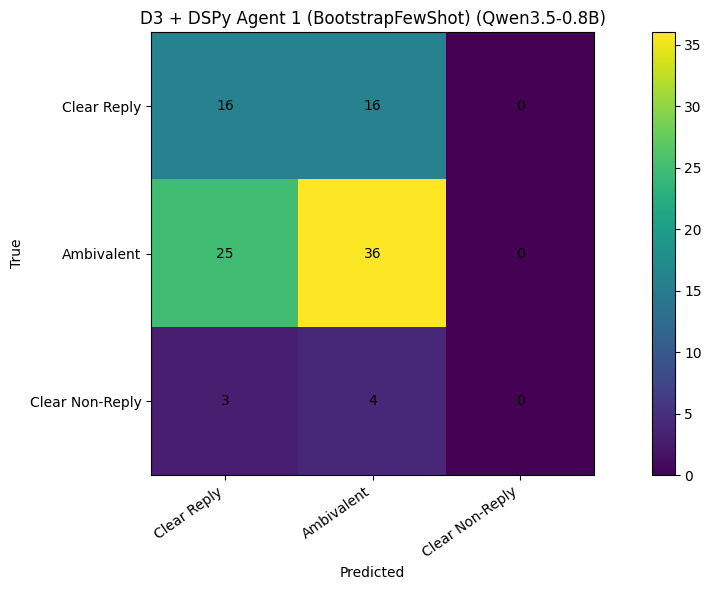

In [153]:
# # Run optimized dspy's Agent 1 over the validation set
# val_eval_df = val_df.head(D3_VALID_LIMIT).copy()

# opt_qi_preds = []
# opt_qi_times = []
# opt_qi_rows = []
# for _, row in tqdm(val_eval_df.iterrows(), total=len(val_eval_df), desc="Optimized Agent 1 (val)"):
#   t0 = time.time()
#   try:
#     # Optimized Agent 1 (DSPy), then real Agents 2-4 to capture each output
#     qi_pred = optimized_qi_program(full_interview_question=str(row.get("interview_question", "")), target_question=str(row["question"]), question_type_hint="other")
#     intent_obj = dspy_qi_prediction_to_dict(qi_pred)
#     content_obj, _ = run_answer_content_agent(str(row["question"]), str(row["interview_answer"]))
#     gap_obj, _ = run_gap_evasion_agent(str(row["question"]), str(row["interview_answer"]), intent_obj, content_obj)
#     decision_obj, _ = run_decision_agent(str(row["question"]), str(row["interview_answer"]), intent_obj, content_obj, gap_obj)
#     label = normalize_prediction_label(decision_obj["label"])
#   except Exception:
#     intent_obj, content_obj, gap_obj, decision_obj = {}, {}, {}, {}
#     label = None
#   elapsed = time.time() - t0

#   opt_qi_times.append(elapsed)
#   opt_qi_preds.append(label)
#   opt_qi_rows.append({
#       "question": str(row["question"]),
#       "interview_answer": str(row["interview_answer"]),
#       "clarity_label": row["clarity_label"],
#       "d3_question_intent": json.dumps(intent_obj, ensure_ascii=False),
#       "d3_answer_content": json.dumps(content_obj, ensure_ascii=False),
#       "d3_gap_evasion": json.dumps(gap_obj, ensure_ascii=False),
#       "d3_decision": json.dumps(decision_obj, ensure_ascii=False),
#       "pred_d3": label,
#       "d3_elapsed_sec": elapsed,
#   })

# # Save full per-row outputs (all agent fields), same shape as the other validation CSVs
# pd.DataFrame(opt_qi_rows).to_csv(f"d3_validation_dspy_qi_bootstrap_{BACKBONE}.csv", index=False)

# # Score and record
# y_true = val_eval_df["clarity_label"].tolist()
# opt_qi_result = evaluate_predictions(y_true, opt_qi_preds, "D3 + DSPy Agent 1 (BootstrapFewShot)", method="dspy QI bootstrap", sec_per_example=sum(opt_qi_times) / len(opt_qi_times))
# all_results.append(opt_qi_result)

# opt_qi_clean = ["INVALID" if p is None else p for p in opt_qi_preds]
# title = f"D3 + DSPy Agent 1 (BootstrapFewShot) ({BACKBONE})"
# print_full_report(y_true, opt_qi_clean, title)
# plot_confusion_matrix(y_true, opt_qi_clean, title, f"d3_confusion_matrix_dspy_qi_bootstrap_{BACKBONE}.png")

Optimized Agent 3 (val):   0%|          | 0/100 [00:00<?, ?it/s]

D3 + DSPy Agent 3 (BootstrapFewShot) (Qwen3.5-0.8B)
                 precision    recall  f1-score   support

    Clear Reply       0.38      0.94      0.54        32
     Ambivalent       0.76      0.26      0.39        61
Clear Non-Reply       0.00      0.00      0.00         7

       accuracy                           0.46       100
      macro avg       0.38      0.40      0.31       100
   weighted avg       0.59      0.46      0.41       100



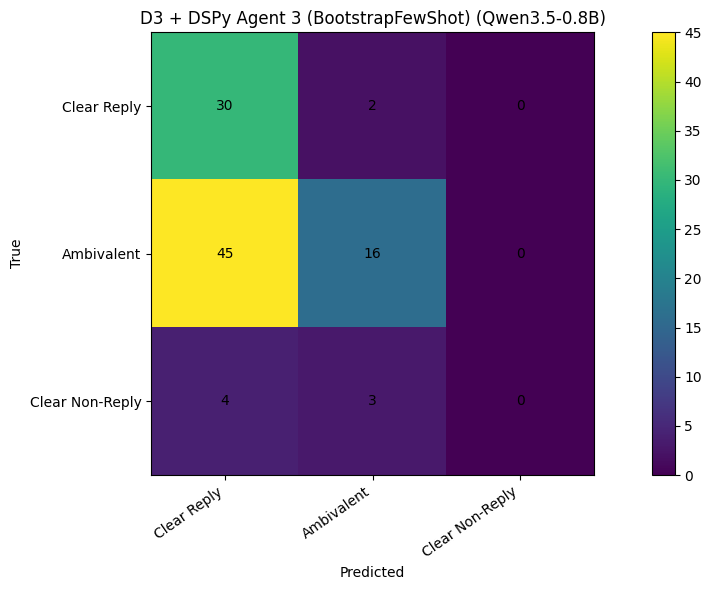

In [154]:
# # Run optimized dspy's Agent 3 over the validation set
# val_eval_df = val_df.head(D3_VALID_LIMIT).copy()

# opt_gap_preds = []
# opt_gap_times = []
# opt_gap_rows = []
# for _, row in tqdm(val_eval_df.iterrows(), total=len(val_eval_df), desc="Optimized Agent 3 (val)"):
#   t0 = time.time()
#   try:
#     # Agents 1-2 (real), optimized Agent 3 (DSPy), Agent 4 (real) to capture each output
#     intent_obj, _ = run_question_intent_agent(str(row["question"]))
#     content_obj, _ = run_answer_content_agent(str(row["question"]), str(row["interview_answer"]))
#     gap_pred = optimized_gap_program(
#         target_question=str(row["question"]),
#         answer=str(row["interview_answer"]),
#         question_intent=json.dumps(intent_obj, ensure_ascii=False),
#         answer_content=json.dumps(content_obj, ensure_ascii=False),
#     )
#     gap_obj = dspy_gap_prediction_to_dict(gap_pred)
#     decision_obj, _ = run_decision_agent(str(row["question"]), str(row["interview_answer"]), intent_obj, content_obj, gap_obj)
#     label = normalize_prediction_label(decision_obj["label"])
#   except Exception:
#     intent_obj, content_obj, gap_obj, decision_obj = {}, {}, {}, {}
#     label = None
#   elapsed = time.time() - t0

#   opt_gap_times.append(elapsed)
#   opt_gap_preds.append(label)
#   opt_gap_rows.append({
#       "question": str(row["question"]),
#       "interview_answer": str(row["interview_answer"]),
#       "clarity_label": row["clarity_label"],
#       "d3_question_intent": json.dumps(intent_obj, ensure_ascii=False),
#       "d3_answer_content": json.dumps(content_obj, ensure_ascii=False),
#       "d3_gap_evasion": json.dumps(gap_obj, ensure_ascii=False),
#       "d3_decision": json.dumps(decision_obj, ensure_ascii=False),
#       "pred_d3": label,
#       "d3_elapsed_sec": elapsed,
#   })

# # Save full per-row outputs
# pd.DataFrame(opt_gap_rows).to_csv(f"d3_validation_dspy_gap_bootstrap_{BACKBONE}.csv", index=False)

# # Score and record
# y_true = val_eval_df["clarity_label"].tolist()
# opt_gap_result = evaluate_predictions(y_true, opt_gap_preds, "D3 + DSPy Agent 3 (BootstrapFewShot)", method="dspy gap bootstrap", sec_per_example=sum(opt_gap_times) / len(opt_gap_times))
# all_results.append(opt_gap_result)

# opt_gap_clean = ["INVALID" if p is None else p for p in opt_gap_preds]
# title = f"D3 + DSPy Agent 3 (BootstrapFewShot) ({BACKBONE})"
# print_full_report(y_true, opt_gap_clean, title)
# plot_confusion_matrix(y_true, opt_gap_clean, title, f"d3_confusion_matrix_dspy_gap_bootstrap_{BACKBONE}.png")

Optimized Agent 1 + 3 (val):   0%|          | 0/100 [00:00<?, ?it/s]

D3 + DSPy Agent 1 + 3 (BootstrapFewShot) (Qwen3.5-0.8B)
                 precision    recall  f1-score   support

    Clear Reply       0.38      0.91      0.54        32
     Ambivalent       0.79      0.31      0.45        61
Clear Non-Reply       0.00      0.00      0.00         7

       accuracy                           0.48       100
      macro avg       0.39      0.41      0.33       100
   weighted avg       0.61      0.48      0.44       100



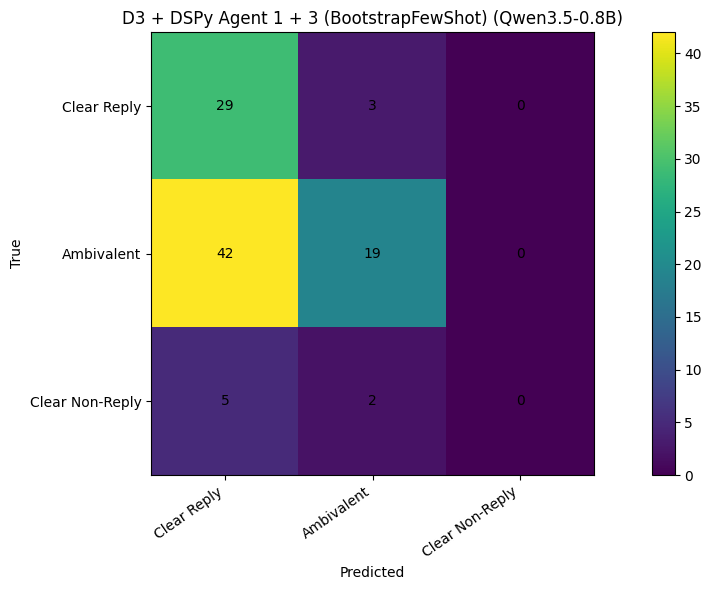

In [155]:
# # Run optimized dspy's Agent 1 and Agent 3 over the validation set
# val_eval_df = val_df.head(D3_VALID_LIMIT).copy()
# opt_qi_preds2 = []
# opt_qi_times2 = []
# opt_qi_rows2 = []
# opt_gap_preds2 = []
# opt_gap_times2 = []
# opt_gap_rows2 = []
# for _, row in tqdm(val_eval_df.iterrows(), total=len(val_eval_df), desc="Optimized Agent 1 + 3 (val)"):
#   t0 = time.time()
#   try:
#     # Optimized Agent 1 + 3 (DSPy), real Agents 1 + 4
#     qi_pred = optimized_qi_program(full_interview_question=str(row.get("interview_question", "")), target_question=str(row["question"]), question_type_hint="other")
#     intent_obj = dspy_qi_prediction_to_dict(qi_pred)
#     content_obj, _ = run_answer_content_agent(str(row["question"]), str(row["interview_answer"]))
#     gap_pred = optimized_gap_program(
#         target_question=str(row["question"]),
#         answer=str(row["interview_answer"]),
#         question_intent=json.dumps(intent_obj, ensure_ascii=False),
#         answer_content=json.dumps(content_obj, ensure_ascii=False),
#     )
#     gap_obj = dspy_gap_prediction_to_dict(gap_pred)
#     decision_obj, _ = run_decision_agent(str(row["question"]), str(row["interview_answer"]), intent_obj, content_obj, gap_obj)
#     label = normalize_prediction_label(decision_obj["label"])
#   except Exception:
#     intent_obj, content_obj, gap_obj, decision_obj = {}, {}, {}, {}
#     label = None
#   elapsed = time.time() - t0

#   opt_qi_times2.append(elapsed)
#   opt_qi_preds2.append(label)
#   opt_qi_rows2.append({
#       "question": str(row["question"]),
#       "interview_answer": str(row["interview_answer"]),
#       "clarity_label": row["clarity_label"],
#       "d3_question_intent": json.dumps(intent_obj, ensure_ascii=False),
#       "d3_answer_content": json.dumps(content_obj, ensure_ascii=False),
#       "d3_gap_evasion": json.dumps(gap_obj, ensure_ascii=False),
#       "d3_decision": json.dumps(decision_obj, ensure_ascii=False),
#       "pred_d3": label,
#       "d3_elapsed_sec": elapsed,
#   })

#   opt_gap_times2.append(elapsed)
#   opt_gap_preds2.append(label)
#   opt_gap_rows2.append({
#       "question": str(row["question"]),
#       "interview_answer": str(row["interview_answer"]),
#       "clarity_label": row["clarity_label"],
#       "d3_question_intent": json.dumps(intent_obj, ensure_ascii=False),
#       "d3_answer_content": json.dumps(content_obj, ensure_ascii=False),
#       "d3_gap_evasion": json.dumps(gap_obj, ensure_ascii=False),
#       "d3_decision": json.dumps(decision_obj, ensure_ascii=False),
#       "pred_d3": label,
#       "d3_elapsed_sec": elapsed,
#   })

# # Save full per-row outputs
# pd.DataFrame(opt_qi_rows2).to_csv(f"d3_validation_dspy_qi_gap_bootstrap_{BACKBONE}.csv", index=False)
# pd.DataFrame(opt_gap_rows2).to_csv(f"d3_validation_dspy_gap_qi_bootstrap_{BACKBONE}.csv", index=False)

# # Score and record
# y_true = val_eval_df["clarity_label"].tolist()
# opt_qi_result2 = evaluate_predictions(y_true, opt_qi_preds2, "D3 + DSPy Agent 1 + 3 (BootstrapFewShot)", method="dspy QI + GAP bootstrap", sec_per_example=sum(opt_qi_times2) / len(opt_qi_times2))
# all_results.append(opt_qi_result2)

# opt_qi_clean2 = ["INVALID" if p is None else p for p in opt_qi_preds2]
# title = f"D3 + DSPy Agent 1 + 3 (BootstrapFewShot) ({BACKBONE})"
# print_full_report(y_true, opt_qi_clean2, title)
# plot_confusion_matrix(y_true, opt_qi_clean2, title, f"d3_confusion_matrix_dspy_qi_gap_bootstrap_{BACKBONE}.png")

In [ ]:
# # Run optimized dspy's Agent 4 over the validation set
# val_eval_df = val_df.head(D3_VALID_LIMIT).copy()
# opt_dec_preds = []
# opt_dec_times = []
# opt_dec_rows = []
# for _, row in tqdm(val_eval_df.iterrows(), total=len(val_eval_df), desc="Optimized Agent 4 (val)"):
#   t0 = time.time()
#   try:
#     intent_obj, _ = run_question_intent_agent(str(row["question"]))
#     content_obj, _ = run_answer_content_agent(str(row["question"]), str(row["interview_answer"]))
#     gap_obj, _ = run_gap_evasion_agent(str(row["question"]), str(row["interview_answer"]), intent_obj, content_obj)
#     pred = optimized_decision_program(
#         question=str(row["question"]),
#         answer=str(row["interview_answer"]),
#         question_intent=json.dumps(intent_obj, ensure_ascii=False),
#         answer_content=json.dumps(content_obj, ensure_ascii=False),
#         gap_evasion=json.dumps(gap_obj, ensure_ascii=False),
#     )
#     decision_obj = {"label": pred.label}
#     label = normalize_prediction_label(pred.label)
#   except Exception:
#     intent_obj, content_obj, gap_obj, decision_obj = {}, {}, {}, {}
#     label = None
#   elapsed = time.time() - t0

#   opt_dec_times.append(elapsed)
#   opt_dec_preds.append(label)
#   opt_dec_rows.append({
#       "question": str(row["question"]),
#       "interview_answer": str(row["interview_answer"]),
#       "clarity_label": row["clarity_label"],
#       "d3_question_intent": json.dumps(intent_obj, ensure_ascii=False),
#       "d3_answer_content": json.dumps(content_obj, ensure_ascii=False),
#       "d3_gap_evasion": json.dumps(gap_obj, ensure_ascii=False),
#       "d3_decision": json.dumps(decision_obj, ensure_ascii=False),
#       "pred_d3": label,
#       "d3_elapsed_sec": elapsed,
#   })

# # Save full per-row outputs
# pd.DataFrame(opt_dec_rows).to_csv(f"d3_validation_dspy_decision_bootstrap_{BACKBONE}.csv", index=False)

# # Score and record
# y_true = val_eval_df["clarity_label"].tolist()
# opt_dec_result = evaluate_predictions(y_true, opt_dec_preds, "D3 + DSPy Agent 4 (BootstrapFewShot)", method="dspy decision bootstrap", sec_per_example=sum(opt_dec_times) / len(opt_dec_times))
# all_results.append(opt_dec_result)
# opt_dec_clean = ["INVALID" if p is None else p for p in opt_dec_preds]
# title = f"D3 + DSPy Agent 4 (BootstrapFewShot) ({BACKBONE})"
# print_full_report(y_true, opt_dec_clean, title)
# plot_confusion_matrix(y_true, opt_dec_clean, title, f"d3_confusion_matrix_dspy_decision_bootstrap_{BACKBONE}.png")

In [156]:
# # All results so far
# results_df = pd.DataFrame(all_results)
# display(results_df.round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030
4,D3 (merged),Qwen3.5-0.8B,merged analysis,0.61,0.474,0.410,0.407,0.590,0.61,0.563,0.0,18.058
5,D3 (full),Qwen3.5-0.8B,manual: Agent 3 v2,0.40,0.687,0.419,0.325,0.612,0.40,0.307,0.0,26.036
6,D3 (full),Qwen3.5-0.8B,manual: Agent 4 v2,0.30,0.332,0.394,0.263,0.449,0.30,0.257,0.0,28.603
7,D3 (full),Qwen3.5-0.8B,manual: Agent 3 v2 + Agent 4 v2,0.38,0.535,0.493,0.359,0.606,0.38,0.256,0.0,23.762
8,D3 + DSPy Agent 1 (BootstrapFewShot),Qwen3.5-0.8B,dspy QI bootstrap,0.52,0.335,0.363,0.345,0.509,0.52,0.510,0.0,31.170
9,D3 + DSPy Agent 3 (BootstrapFewShot),Qwen3.5-0.8B,dspy gap bootstrap,0.46,0.381,0.400,0.310,0.586,0.46,0.411,0.0,25.659


In [167]:
# Recorded results (100-row val subset) for frozen DSPy optimization trials
d3_dspy_qi_result = {
    "system": "D3 + DSPy Agent 1 (BootstrapFewShot)", "backbone": "Qwen3.5-0.8B", "method": "dspy qi bootstrap",
    "accuracy": 0.52, "precision_macro": 0.335, "recall_macro": 0.363, "f1_macro": 0.345, "precision_weighted": 0.509,
    "recall_weighted": 0.52, "f1_weighted": 0.510, "parse_failure_rate": 0.00, "sec_per_example": 31.170,
}

d3_dspy_gap_result = {
  "system": "D3 + DSPy Agent 3 (BootstrapFewShot)", "backbone": "Qwen3.5-0.8B", "method": "dspy gap bootstrap",
  "accuracy": 0.46, "precision_macro": 0.381, "recall_macro": 0.400, "f1_macro": 0.310, "precision_weighted": 0.586,
  "recall_weighted": 0.46, "f1_weighted": 0.411, "parse_failure_rate": 0.00, "sec_per_example": 25.659,
}

d3_dspy_qi_gap_result = {
    "system": "D3 + DSPy Agent 1 + 3 (BootstrapFewShot)", "backbone": "Qwen3.5-0.8B", "method": "dspy qi-gap bootstrap",
    "accuracy": 0.48, "precision_macro": 0.391, "recall_macro": 0.406, "f1_macro": 0.328, "precision_weighted": 0.605,
    "recall_weighted": 0.48, "f1_weighted": 0.445, "parse_failure_rate": 0.00, "sec_per_example": 27.679,
}

recorded_results.append(d3_dspy_qi_result)
recorded_results.append(d3_dspy_gap_result)
recorded_results.append(d3_dspy_qi_gap_result)
display(pd.DataFrame(recorded_results).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030
4,D3 (merged),Qwen3.5-0.8B,merged analysis,0.61,0.474,0.410,0.407,0.590,0.61,0.563,0.0,18.058
5,D3 (full),Qwen3.5-0.8B,m1 Agent 3 v2,0.40,0.687,0.419,0.325,0.612,0.40,0.307,0.0,26.036
6,D3 (full),Qwen3.5-0.8B,m2 Agent 4 v2,0.30,0.332,0.394,0.263,0.449,0.30,0.257,0.0,28.603
7,D3 (full),Qwen3.5-0.8B,m3 Agents 3 + 4 v2,0.38,0.535,0.493,0.359,0.606,0.38,0.256,0.0,23.762
8,D3 + DSPy Agent 1 (BootstrapFewShot),Qwen3.5-0.8B,dspy qi bootstrap,0.52,0.335,0.363,0.345,0.509,0.52,0.510,0.0,31.170
9,D3 + DSPy Agent 3 (BootstrapFewShot),Qwen3.5-0.8B,dspy gap bootstrap,0.46,0.381,0.400,0.310,0.586,0.46,0.411,0.0,25.659


#### Compare optimizers and settings

We try several optimizer setups on the chosen agent such as different `BootstrapFewShot` settings, then other optimizers, and evaluate each on `val_df`, collecting them in the results table to see which works best.

We focus this optimizer comparison on the **Gap and Evasion agent (Agent 3)**, trying different BootstrapFewShot settings, RandomSearch, and MIPROv2, and additionally apply MIPROv2 to the Decision agent (Agent 4).

In [168]:
# Helper: compile an optimizer for Agent 3
def compile_and_eval(optimizer, trainset, run_label, method_tag):
  """
  Compile an optimizer for Agent 3, run the full pipeline over val_df, score and record the result.

  Args:
    optimizer: a DSPy optimizer instance (already given the metric)
    trainset: the demo examples to compile on (dspy_gap_trainset)
    run_label: human-readable name for this trial (used in the report and results table)
    method_tag: short tag stored in the results row to identify this trial

  Return:
    The optimized program, in case you want to inspect or reuse it
  """
  base = DSPyGapEvasionAgent()
  optimized = optimizer.compile(base, trainset=trainset)

  # Run the full pipeline (real Agents 1-2, optimized Agent 3, real Agent 4) over val_df
  eval_df = val_df.head(D3_VALID_LIMIT).copy()
  preds = []
  times = []
  rows = []
  for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=run_label):
    t0 = time.time()
    try:
      intent_obj, _ = run_question_intent_agent(str(row["question"]))
      content_obj, _ = run_answer_content_agent(str(row["question"]), str(row["interview_answer"]))
      gap_pred = optimized(
          target_question=str(row["question"]),
          answer=str(row["interview_answer"]),
          question_intent=json.dumps(intent_obj, ensure_ascii=False),
          answer_content=json.dumps(content_obj, ensure_ascii=False),
      )
      gap_obj = dspy_gap_prediction_to_dict(gap_pred)
      decision_obj, _ = run_decision_agent(str(row["question"]), str(row["interview_answer"]), intent_obj, content_obj, gap_obj)
      label = normalize_prediction_label(decision_obj["label"])
    except Exception:
      intent_obj, content_obj, gap_obj, decision_obj = {}, {}, {}, {}
      label = None
    elapsed = time.time() - t0

    times.append(elapsed)
    preds.append(label)
    rows.append({
        "question": str(row["question"]),
        "interview_answer": str(row["interview_answer"]),
        "clarity_label": row["clarity_label"],
        "d3_question_intent": json.dumps(intent_obj, ensure_ascii=False),
        "d3_answer_content": json.dumps(content_obj, ensure_ascii=False),
        "d3_gap_evasion": json.dumps(gap_obj, ensure_ascii=False),
        "d3_decision": json.dumps(decision_obj, ensure_ascii=False),
        "pred_d3": label,
        "d3_elapsed_sec": elapsed,
    })

  # Save full per-row outputs
  pd.DataFrame(rows).to_csv(f"d3_validation_{method_tag}_{BACKBONE}.csv", index=False)

  # Score and record
  y_true = eval_df["clarity_label"].tolist()
  result = evaluate_predictions(y_true, preds, run_label, method=method_tag, sec_per_example=sum(times) / len(times))
  all_results.append(result)

  clean = ["INVALID" if p is None else p for p in preds]
  print_full_report(y_true, clean, run_label)
  plot_confusion_matrix(y_true, clean, run_label, f"d3_confusion_matrix_{method_tag}_{BACKBONE}.png")
  return optimized

 17%|█▋        | 2/12 [01:15<06:19, 38.00s/it]

Bootstrapped 2 full traces after 2 examples for up to 1 rounds, amounting to 2 attempts.


D3 + DSPy Agent 3 (BootstrapFewShot, demos=2):   0%|          | 0/100 [00:00<?, ?it/s]

D3 + DSPy Agent 3 (BootstrapFewShot, demos=2)
                 precision    recall  f1-score   support

    Clear Reply       0.35      0.88      0.50        32
     Ambivalent       0.68      0.21      0.33        61
Clear Non-Reply       0.00      0.00      0.00         7

       accuracy                           0.41       100
      macro avg       0.35      0.36      0.28       100
   weighted avg       0.53      0.41      0.36       100



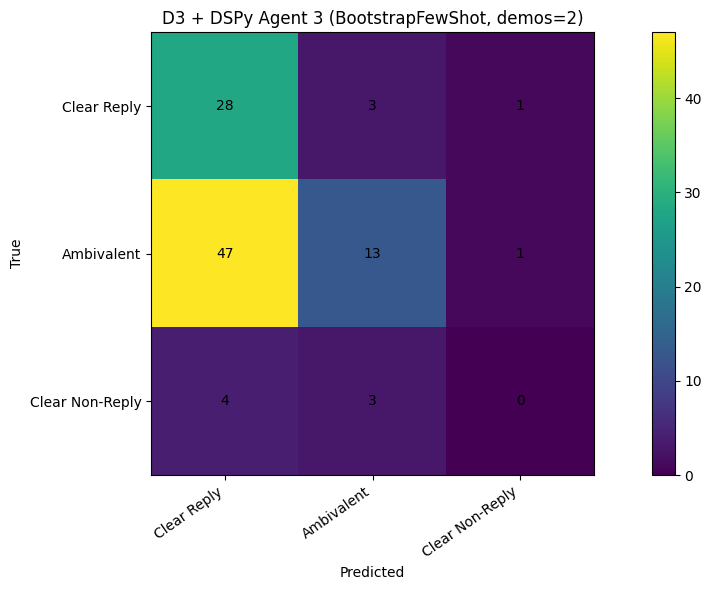

100%|██████████| 12/12 [05:26<00:00, 27.18s/it]

Bootstrapped 5 full traces after 11 examples for up to 1 rounds, amounting to 12 attempts.


D3 + DSPy Agent 3 (BootstrapFewShot, demos=8):   0%|          | 0/100 [00:00<?, ?it/s]

D3 + DSPy Agent 3 (BootstrapFewShot, demos=8)
                 precision    recall  f1-score   support

    Clear Reply       0.34      0.91      0.50        32
     Ambivalent       0.57      0.13      0.21        61
Clear Non-Reply       0.00      0.00      0.00         7

       accuracy                           0.37       100
      macro avg       0.30      0.35      0.24       100
   weighted avg       0.46      0.37      0.29       100



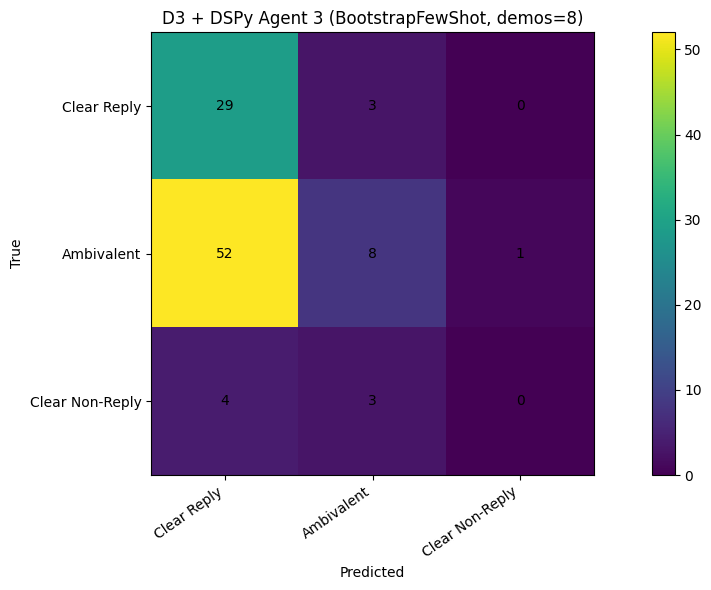

In [169]:
# # Trial A: BootstrapFewShot with different numbers of demos (Agent 3)
# for n_demos in [2, 8]:
#   optimizer = dspy.BootstrapFewShot(
#       metric=gap_evasion_metric,
#       max_bootstrapped_demos=n_demos,
#       max_labeled_demos=0,
#       max_rounds=1,
#       max_errors=20,
#   )
#   compile_and_eval(
#       optimizer,
#       dspy_gap_trainset,
#       run_label=f"D3 + DSPy Agent 3 (BootstrapFewShot, demos={n_demos})",
#       method_tag=f"dspy_gap_bfs_demos{n_demos}",
#   )

In [170]:
# Update the gap evasion metric to be class-weighted
def gap_evasion_metric2(example, pred, trace=None):
  """
  Class-weighted version of gap_evasion_metric: a correct Clear Non-Reply is rewarded more, so score-aggregating optimizers stop zeroing the rare class.

  Args:
     example: one example with target_question, answer, and gold label
     pred: the DSPy prediction
     trace: not used

  Return:
    0.0 if wrong, 3.0 if correct and gold is Clear Non-Reply, 1.0 if correct otherwise
  """
  predicted_label = run_d3_with_dspy_gap_program(example, lambda **kwargs: pred)
  predicted_label = normalize_prediction_label(predicted_label)
  gold_label = normalize_prediction_label(example.label)
  if predicted_label != gold_label:
    return 0.0
  return 3.0 if gold_label == "Clear Non-Reply" else 1.0

Going to sample between 1 and 4 traces per predictor.
Will attempt to bootstrap 6 candidate sets.
Average Metric: 5.00 / 9 (55.6%): 100%|██████████| 9/9 [07:05<00:00, 47.32s/it]

2026/06/04 04:04:15 INFO dspy.evaluate.evaluate: Average Metric: 5.0 / 9 (55.6%)



New best score: 55.56 for seed -3
Scores so far: [55.56]
Best score so far: 55.56
Average Metric: 5.00 / 9 (55.6%): 100%|██████████| 9/9 [10:56<00:00, 72.92s/it]

2026/06/04 04:15:11 INFO dspy.evaluate.evaluate: Average Metric: 5.0 / 9 (55.6%)



Scores so far: [55.56, 55.56]
Best score so far: 55.56


...

Bootstrapped 3 full traces after 8 examples for up to 1 rounds, amounting to 8 attempts.
Average Metric: 7.00 / 9 (77.8%): 100%|██████████| 9/9 [06:47<00:00, 45.30s/it]

2026/06/04 05:22:05 INFO dspy.evaluate.evaluate: Average Metric: 7.0 / 9 (77.8%)



Scores so far: [55.56, 55.56, 44.44, 44.44, 33.33, 33.33, 77.78, 44.44, 77.78]
Best score so far: 77.78
9 candidate programs found.


D3 + DSPy Agent 3 (RandomSearch):   0%|          | 0/100 [00:00<?, ?it/s]

D3 + DSPy Agent 3 (RandomSearch)
                 precision    recall  f1-score   support

    Clear Reply       0.35      0.88      0.50        32
     Ambivalent       0.63      0.20      0.30        61
Clear Non-Reply       0.00      0.00      0.00         7

       accuracy                           0.40       100
      macro avg       0.33      0.36      0.27       100
   weighted avg       0.50      0.40      0.34       100



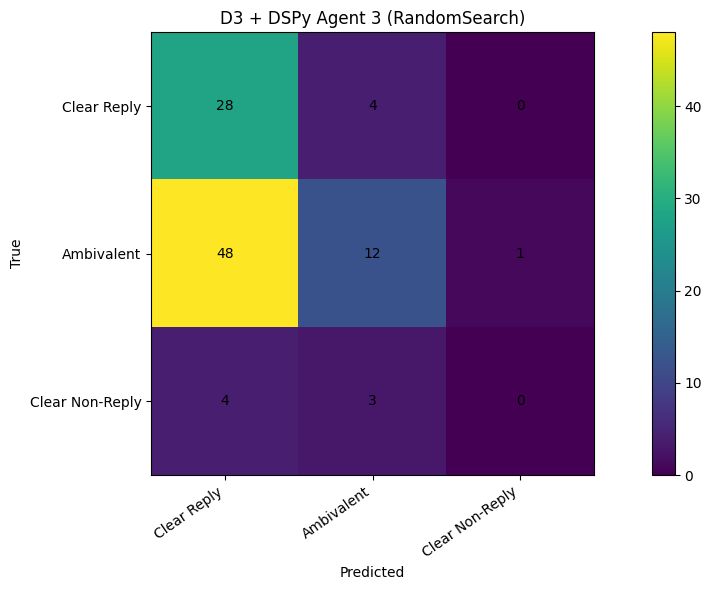

In [171]:
# # Trial B: BootstrapFewShotWithRandomSearch on Agent 3

# # Small held-out valset from the pool for scoring candidates (kept separate from val_df), NOT in the trainset
# train_qs = {ex.target_question for ex in dspy_gap_trainset}
# pool_holdout = pool_df[pool_df["question"].isin(train_qs) == False]
# rs_valset = build_gap_examples(pool_holdout, per_class=3)

# rs_optimizer = dspy.BootstrapFewShotWithRandomSearch(
#     metric=gap_evasion_metric2,
#     max_bootstrapped_demos=4,
#     max_labeled_demos=0,
#     num_candidate_programs=6,
#     max_errors=20,
# )
# rs_base = DSPyGapEvasionAgent()
# rs_optimized = rs_optimizer.compile(rs_base, trainset=dspy_gap_trainset, valset=rs_valset)

# # Evaluate the full pipeline (real Agents 1-2, optimized Agent 3, real Agent 4) on val_df
# method_tag = "dspy_gap_random_search"
# run_label = "D3 + DSPy Agent 3 (RandomSearch)"
# rs_eval_df = val_df.head(D3_VALID_LIMIT).copy()
# rs_preds = []
# rs_times = []
# rs_rows = []
# for _, row in tqdm(rs_eval_df.iterrows(), total=len(rs_eval_df), desc=run_label):
#   t0 = time.time()
#   try:
#     intent_obj, _ = run_question_intent_agent(str(row["question"]))
#     content_obj, _ = run_answer_content_agent(str(row["question"]), str(row["interview_answer"]))
#     gap_pred = rs_optimized(
#         target_question=str(row["question"]),
#         answer=str(row["interview_answer"]),
#         question_intent=json.dumps(intent_obj, ensure_ascii=False),
#         answer_content=json.dumps(content_obj, ensure_ascii=False),
#     )
#     gap_obj = dspy_gap_prediction_to_dict(gap_pred)
#     decision_obj, _ = run_decision_agent(str(row["question"]), str(row["interview_answer"]), intent_obj, content_obj, gap_obj)
#     label = normalize_prediction_label(decision_obj["label"])
#   except Exception:
#     intent_obj, content_obj, gap_obj, decision_obj = {}, {}, {}, {}
#     label = None
#   elapsed = time.time() - t0

#   rs_times.append(elapsed)
#   rs_preds.append(label)
#   rs_rows.append({
#       "question": str(row["question"]),
#       "interview_answer": str(row["interview_answer"]),
#       "clarity_label": row["clarity_label"],
#       "d3_question_intent": json.dumps(intent_obj, ensure_ascii=False),
#       "d3_answer_content": json.dumps(content_obj, ensure_ascii=False),
#       "d3_gap_evasion": json.dumps(gap_obj, ensure_ascii=False),
#       "d3_decision": json.dumps(decision_obj, ensure_ascii=False),
#       "pred_d3": label,
#       "d3_elapsed_sec": elapsed,
#   })

# # Save full per-row outputs
# pd.DataFrame(rs_rows).to_csv(f"d3_validation_{method_tag}_{BACKBONE}.csv", index=False)

# # Score and record
# y_true = rs_eval_df["clarity_label"].tolist()
# rs_result = evaluate_predictions(y_true, rs_preds, run_label, method=method_tag, sec_per_example=sum(rs_times) / len(rs_times))
# all_results.append(rs_result)

# rs_clean = ["INVALID" if p is None else p for p in rs_preds]
# print_full_report(y_true, rs_clean, run_label)
# plot_confusion_matrix(y_true, rs_clean, run_label, f"d3_confusion_matrix_{method_tag}_{BACKBONE}.png")

2026/06/04 06:25:25 WARNING dspy.teleprompt.mipro_optimizer_v2: 'requires_permission_to_run' is deprecated and will be removed in a future version.
2026/06/04 06:25:25 INFO dspy.teleprompt.mipro_optimizer_v2: 
RUNNING WITH THE FOLLOWING LIGHT AUTO RUN SETTINGS:
num_trials: 10
minibatch: False
num_fewshot_candidates: 6
num_instruct_candidates: 3
valset size: 9

2026/06/04 06:25:25 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==
2026/06/04 06:25:25 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.

2026/06/04 06:25:25 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=6 sets of demonstrations...


Bootstrapping set 1/6
Bootstrapping set 2/6


 58%|█████▊    | 7/12 [03:05<02:12, 26.52s/it]


Bootstrapped 2 full traces after 7 examples for up to 1 rounds, amounting to 7 attempts.
Bootstrapping set 3/6


 75%|███████▌  | 9/12 [04:14<01:24, 28.22s/it]


...

2026/06/04 08:11:10 INFO dspy.evaluate.evaluate: Average Metric: 4.0 / 9 (44.4%)
2026/06/04 08:11:10 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 44.44 with parameters ['Predictor 0: Instruction 2', 'Predictor 0: Few-Shot Set 5'].
2026/06/04 08:11:10 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [55.56, 33.33, 33.33, 33.33, 44.44, 33.33, 33.33, 44.44, 44.44, 44.44]
2026/06/04 08:11:10 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 55.56
2026/06/04 08:11:10 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2026/06/04 08:11:10 INFO dspy.teleprompt.mipro_optimizer_v2: ===== Trial 11 / 10 =====



Average Metric: 5.00 / 9 (55.6%): 100%|██████████| 9/9 [10:16<00:00, 68.46s/it]

2026/06/04 08:21:27 INFO dspy.evaluate.evaluate: Average Metric: 5.0 / 9 (55.6%)
2026/06/04 08:21:27 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 55.56 with parameters ['Predictor 0: Instruction 0', 'Predictor 0: Few-Shot Set 0'].
2026/06/04 08:21:27 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [55.56, 33.33, 33.33, 33.33, 44.44, 33.33, 33.33, 44.44, 44.44, 44.44, 55.56]
2026/06/04 08:21:27 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 55.56
2026/06/04 08:21:27 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2026/06/04 08:21:27 INFO dspy.teleprompt.mipro_optimizer_v2: Returning best identified program with score 55.56!


D3 + DSPy Agent 3 (MIPROv2):   0%|          | 0/100 [00:00<?, ?it/s]

D3 + DSPy Agent 3 (MIPROv2)
                 precision    recall  f1-score   support

    Clear Reply       0.42      0.31      0.36        32
     Ambivalent       0.63      0.79      0.70        61
Clear Non-Reply       0.00      0.00      0.00         7

       accuracy                           0.58       100
      macro avg       0.35      0.37      0.35       100
   weighted avg       0.52      0.58      0.54       100



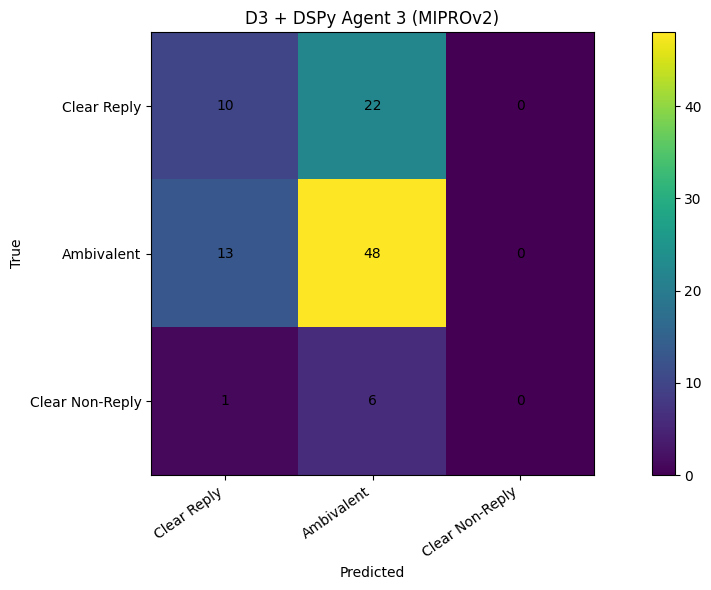

In [174]:
# # Trial C: MIPROv2 on Agent 3 (rewrites instructions + picks demos)
# mipro_optimizer = dspy.MIPROv2(
#     metric=gap_evasion_metric2,
#     auto="light",
# )
# mipro_base = DSPyGapEvasionAgent()
# mipro_optimized = mipro_optimizer.compile(
#     mipro_base,
#     trainset=dspy_gap_trainset,
#     valset=rs_valset,
#     max_bootstrapped_demos=4,
#     max_labeled_demos=0,
#     requires_permission_to_run=False,
# )

# # Evaluate the full pipeline (real Agents 1-2, optimized Agent 3, real Agent 4) on val_df
# method_tag = "dspy_gap_miprov2"
# run_label = "D3 + DSPy Agent 3 (MIPROv2)"
# mipro_eval_df = val_df.head(D3_VALID_LIMIT).copy()
# mipro_preds = []
# mipro_times = []
# mipro_rows = []
# for _, row in tqdm(mipro_eval_df.iterrows(), total=len(mipro_eval_df), desc=run_label):
#   t0 = time.time()
#   try:
#     intent_obj, _ = run_question_intent_agent(str(row["question"]))
#     content_obj, _ = run_answer_content_agent(str(row["question"]), str(row["interview_answer"]))
#     gap_pred = mipro_optimized(
#         target_question=str(row["question"]),
#         answer=str(row["interview_answer"]),
#         question_intent=json.dumps(intent_obj, ensure_ascii=False),
#         answer_content=json.dumps(content_obj, ensure_ascii=False),
#     )
#     gap_obj = dspy_gap_prediction_to_dict(gap_pred)
#     decision_obj, _ = run_decision_agent(str(row["question"]), str(row["interview_answer"]), intent_obj, content_obj, gap_obj)
#     label = normalize_prediction_label(decision_obj["label"])
#   except Exception:
#     intent_obj, content_obj, gap_obj, decision_obj = {}, {}, {}, {}
#     label = None
#   elapsed = time.time() - t0

#   mipro_times.append(elapsed)
#   mipro_preds.append(label)
#   mipro_rows.append({
#       "question": str(row["question"]),
#       "interview_answer": str(row["interview_answer"]),
#       "clarity_label": row["clarity_label"],
#       "d3_question_intent": json.dumps(intent_obj, ensure_ascii=False),
#       "d3_answer_content": json.dumps(content_obj, ensure_ascii=False),
#       "d3_gap_evasion": json.dumps(gap_obj, ensure_ascii=False),
#       "d3_decision": json.dumps(decision_obj, ensure_ascii=False),
#       "pred_d3": label,
#       "d3_elapsed_sec": elapsed,
#   })

# # Save full per-row outputs
# pd.DataFrame(mipro_rows).to_csv(f"d3_validation_{method_tag}_{BACKBONE}.csv", index=False)

# # Score and record
# y_true = mipro_eval_df["clarity_label"].tolist()
# mipro_result = evaluate_predictions(y_true, mipro_preds, run_label, method=method_tag, sec_per_example=sum(mipro_times) / len(mipro_times))
# all_results.append(mipro_result)

# mipro_clean = ["INVALID" if p is None else p for p in mipro_preds]
# print_full_report(y_true, mipro_clean, run_label)
# plot_confusion_matrix(y_true, mipro_clean, run_label, f"d3_confusion_matrix_{method_tag}_{BACKBONE}.png")

2026/06/04 09:19:16 WARNING dspy.teleprompt.mipro_optimizer_v2: 'requires_permission_to_run' is deprecated and will be removed in a future version.
2026/06/04 09:19:16 INFO dspy.teleprompt.mipro_optimizer_v2: 
RUNNING WITH THE FOLLOWING LIGHT AUTO RUN SETTINGS:
num_trials: 10
minibatch: False
num_fewshot_candidates: 6
num_instruct_candidates: 3
valset size: 9

2026/06/04 09:19:16 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==
2026/06/04 09:19:16 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.

2026/06/04 09:19:16 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=6 sets of demonstrations...


Bootstrapping set 1/6
Bootstrapping set 2/6
Bootstrapping set 3/6


 92%|█████████▏| 11/12 [00:29<00:02,  2.67s/it]


Bootstrapped 4 full traces after 11 examples for up to 1 rounds, amounting to 11 attempts.
Bootstrapping set 4/6


 25%|██▌       | 3/12 [00:08<00:25,  2.83s/it]


...

2026/06/04 09:32:18 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 9 (33.3%)
2026/06/04 09:32:18 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 33.33 with parameters ['Predictor 0: Instruction 2', 'Predictor 0: Few-Shot Set 5'].
2026/06/04 09:32:18 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [55.56, 33.33, 44.44, 33.33, 33.33, 33.33, 44.44, 33.33, 77.78, 33.33]
2026/06/04 09:32:18 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 77.78
2026/06/04 09:32:18 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2026/06/04 09:32:18 INFO dspy.teleprompt.mipro_optimizer_v2: ===== Trial 11 / 10 =====



Average Metric: 7.00 / 9 (77.8%): 100%|██████████| 9/9 [00:38<00:00,  4.25s/it]

2026/06/04 09:32:56 INFO dspy.evaluate.evaluate: Average Metric: 7.0 / 9 (77.8%)
2026/06/04 09:32:56 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 77.78 with parameters ['Predictor 0: Instruction 1', 'Predictor 0: Few-Shot Set 4'].
2026/06/04 09:32:56 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [55.56, 33.33, 44.44, 33.33, 33.33, 33.33, 44.44, 33.33, 77.78, 33.33, 77.78]
2026/06/04 09:32:56 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 77.78
2026/06/04 09:32:56 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2026/06/04 09:32:56 INFO dspy.teleprompt.mipro_optimizer_v2: Returning best identified program with score 77.78!


D3 + DSPy Agent 4 (MIPROv2):   0%|          | 0/100 [00:00<?, ?it/s]

D3 + DSPy Agent 4 (MIPROv2) (Qwen3.5-0.8B)
                 precision    recall  f1-score   support

    Clear Reply       0.36      0.78      0.49        32
     Ambivalent       0.63      0.28      0.39        61
Clear Non-Reply       0.33      0.14      0.20         7

       accuracy                           0.43       100
      macro avg       0.44      0.40      0.36       100
   weighted avg       0.52      0.43      0.41       100



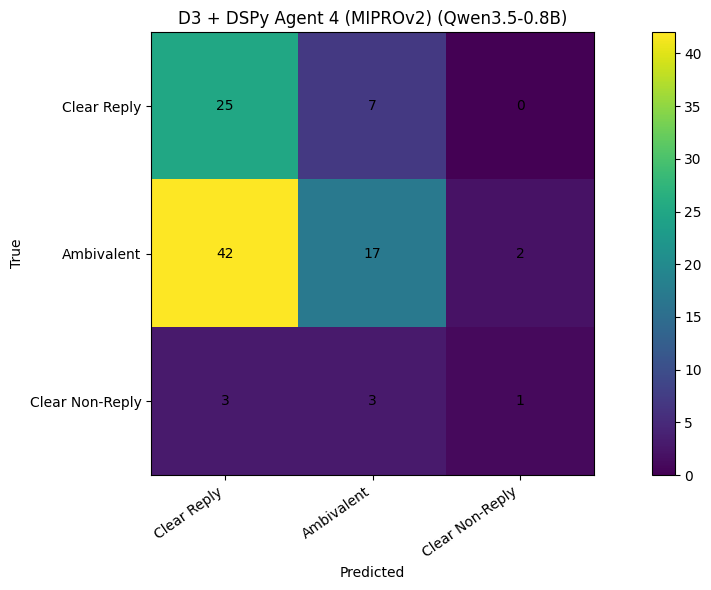

In [181]:
# # Trial D: MIPROv2 on Agent 4 (Decision)
# train_qs = {ex.question for ex in dspy_decision_trainset}
# dec_valset = build_decision_examples(pool_df[pool_df["question"].isin(train_qs) == False], per_class=3)

# mipro_dec_optimizer = dspy.MIPROv2(metric=decision_metric, auto="light")
# mipro_dec_base = DSPyDecisionAgent()
# mipro_dec_optimized = mipro_dec_optimizer.compile(
#     mipro_dec_base,
#     trainset=dspy_decision_trainset,
#     valset=dec_valset,
#     max_bootstrapped_demos=4,
#     max_labeled_demos=4, # Add real demo examples
#     requires_permission_to_run=False,
# )

# method_tag = "dspy_decision_miprov2"
# run_label = "D3 + DSPy Agent 4 (MIPROv2)"
# dec_eval_df = val_df.head(D3_VALID_LIMIT).copy()
# dec_preds, dec_times, dec_rows = [], [], []
# for _, row in tqdm(dec_eval_df.iterrows(), total=len(dec_eval_df), desc=run_label):
#   t0 = time.time()
#   try:
#     q, a = str(row["question"]), str(row["interview_answer"])
#     intent_obj, _ = run_question_intent_agent(q)
#     content_obj, _ = run_answer_content_agent(q, a)
#     gap_obj, _ = run_gap_evasion_agent(q, a, intent_obj, content_obj)
#     dec_pred = mipro_dec_optimized(
#         question=q, answer=a,
#         question_intent=json.dumps(intent_obj, ensure_ascii=False),
#         answer_content=json.dumps(content_obj, ensure_ascii=False),
#         gap_evasion=json.dumps(gap_obj, ensure_ascii=False),
#     )
#     decision_obj = dspy_decision_prediction_to_dict(dec_pred)
#     label = decision_obj["label"]
#   except Exception:
#     intent_obj, content_obj, gap_obj, decision_obj = {}, {}, {}, {}
#     label = None
#   elapsed = time.time() - t0
#   dec_times.append(elapsed); dec_preds.append(label)
#   dec_rows.append({
#       "question": str(row["question"]), "interview_answer": str(row["interview_answer"]),
#       "clarity_label": row["clarity_label"],
#       "d3_question_intent": json.dumps(intent_obj, ensure_ascii=False),
#       "d3_answer_content": json.dumps(content_obj, ensure_ascii=False),
#       "d3_gap_evasion": json.dumps(gap_obj, ensure_ascii=False),
#       "d3_decision": json.dumps(decision_obj, ensure_ascii=False),
#       "pred_d3": label, "d3_elapsed_sec": elapsed,
#   })

# pd.DataFrame(dec_rows).to_csv(f"d3_validation_{method_tag}_{BACKBONE}.csv", index=False)
# y_true = dec_eval_df["clarity_label"].tolist()
# dec_result = evaluate_predictions(y_true, dec_preds, run_label, method=method_tag, sec_per_example=sum(dec_times) / len(dec_times))
# all_results.append(dec_result)
# dec_clean = ["INVALID" if p is None else p for p in dec_preds]
# title = f"D3 + DSPy Agent 4 (MIPROv2) ({BACKBONE})"
# print_full_report(y_true, dec_clean, title)
# plot_confusion_matrix(y_true, dec_clean, title, f"d3_confusion_matrix_{method_tag}_{BACKBONE}.png")

In [182]:
# # All results so far
# results_df = pd.DataFrame(all_results)
# display(results_df.round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030
4,D3 (merged),Qwen3.5-0.8B,merged analysis,0.61,0.474,0.410,0.407,0.590,0.61,0.563,0.0,18.058
5,D3 (full),Qwen3.5-0.8B,manual: Agent 3 v2,0.40,0.687,0.419,0.325,0.612,0.40,0.307,0.0,26.036
6,D3 (full),Qwen3.5-0.8B,manual: Agent 4 v2,0.30,0.332,0.394,0.263,0.449,0.30,0.257,0.0,28.603
7,D3 (full),Qwen3.5-0.8B,manual: Agent 3 v2 + Agent 4 v2,0.38,0.535,0.493,0.359,0.606,0.38,0.256,0.0,23.762
8,D3 + DSPy Agent 1 (BootstrapFewShot),Qwen3.5-0.8B,dspy QI bootstrap,0.52,0.335,0.363,0.345,0.509,0.52,0.510,0.0,31.170
9,D3 + DSPy Agent 3 (BootstrapFewShot),Qwen3.5-0.8B,dspy gap bootstrap,0.46,0.381,0.400,0.310,0.586,0.46,0.411,0.0,25.659


In [183]:
# Recorded results (100-row val subset) for all frozen optimizer-comparison trials
d3_gap_bfs_demos2_result = {
  "system": "D3 + DSPy Agent 3 (BootstrapFewShot, demos=2)", "backbone": "Qwen3.5-0.8B", "method": "dspy_gap_bfs_demos2",
  "accuracy": 0.41, "precision_macro": 0.346, "recall_macro": 0.363, "f1_macro": 0.277, "precision_weighted": 0.531,
  "recall_weighted": 0.41, "f1_weighted": 0.360, "parse_failure_rate": 0.00, "sec_per_example": 25.838,
}

d3_gap_bfs_demos8_result = {
  "system": "D3 + DSPy Agent 3 (BootstrapFewShot, demos=8)", "backbone": "Qwen3.5-0.8B", "method": "dspy_gap_bfs_demos8",
  "accuracy": 0.37, "precision_macro": 0.304, "recall_macro": 0.346, "f1_macro": 0.236, "precision_weighted": 0.458,
  "recall_weighted": 0.37, "f1_weighted": 0.289, "parse_failure_rate": 0.00, "sec_per_example": 24.617,
}

d3_gap_random_search_result = {
  "system": "D3 + DSPy Agent 3 (RandomSearch)", "backbone": "Qwen3.5-0.8B", "method": "dspy_gap_random_search",
  "accuracy": 0.40, "precision_macro": 0.327, "recall_macro": 0.357, "f1_macro": 0.267, "precision_weighted": 0.497,
  "recall_weighted": 0.40, "f1_weighted": 0.343, "parse_failure_rate": 0.00, "sec_per_example": 24.433,
}

d3_gap_mipro_result = {
  "system": "D3 + DSPy Agent 3 (Mipro)", "backbone": "Qwen3.5-0.8B", "method": "dspy_gap_mipro",
  "accuracy": 0.58, "precision_macro": 0.349, "recall_macro": 0.366, "f1_macro": 0.353, "precision_weighted": 0.519,
  "recall_weighted": 0.58, "f1_weighted": 0.542, "parse_failure_rate": 0.00, "sec_per_example": 28.713,
}

d3_dec_mipro_result = {
  "system": "D3 + DSPy Agent 4 (Mipro)", "backbone": "Qwen3.5-0.8B", "method": "dspy_dec_mipro",
  "accuracy": 0.43, "precision_macro": 0.440, "recall_macro": 0.401, "f1_macro": 0.359, "precision_weighted": 0.522,
  "recall_weighted": 0.43, "f1_weighted": 0.407, "parse_failure_rate": 0.00, "sec_per_example": 26.300,
}

recorded_results.append(d3_gap_bfs_demos2_result)
recorded_results.append(d3_gap_bfs_demos8_result)
recorded_results.append(d3_gap_random_search_result)
recorded_results.append(d3_gap_mipro_result)
recorded_results.append(d3_dec_mipro_result)
display(pd.DataFrame(recorded_results).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.0,30.306
1,D3 (full),Qwen3.5-0.8B,few-shot decision (9 demos),0.47,0.432,0.383,0.384,0.515,0.47,0.476,0.0,31.264
2,D3 (drop Gap),Qwen3.5-0.8B,Combo 1: drop Agent 3,0.48,0.468,0.443,0.389,0.607,0.48,0.456,0.0,19.942
3,D3 (drop Intent & Gap),Qwen3.5-0.8B,"Combo 2: drop Agents 1, 3",0.52,0.584,0.480,0.426,0.677,0.52,0.490,0.0,14.030
4,D3 (merged),Qwen3.5-0.8B,merged analysis,0.61,0.474,0.410,0.407,0.590,0.61,0.563,0.0,18.058
5,D3 (full),Qwen3.5-0.8B,m1 Agent 3 v2,0.40,0.687,0.419,0.325,0.612,0.40,0.307,0.0,26.036
6,D3 (full),Qwen3.5-0.8B,m2 Agent 4 v2,0.30,0.332,0.394,0.263,0.449,0.30,0.257,0.0,28.603
7,D3 (full),Qwen3.5-0.8B,m3 Agents 3 + 4 v2,0.38,0.535,0.493,0.359,0.606,0.38,0.256,0.0,23.762
8,D3 + DSPy Agent 1 (BootstrapFewShot),Qwen3.5-0.8B,dspy qi bootstrap,0.52,0.335,0.363,0.345,0.509,0.52,0.510,0.0,31.170
9,D3 + DSPy Agent 3 (BootstrapFewShot),Qwen3.5-0.8B,dspy gap bootstrap,0.46,0.381,0.400,0.310,0.586,0.46,0.411,0.0,25.659


## Error Analysis

In [184]:
# # Set the winner (highest macro F1 in the main `results` table)
# WINNER_NAME = "D3 (full)"
# WINNER_DF = d3_valid_df

# # Build error_df: the winner's rows with predicted_label
# error_df = WINNER_DF.copy().reset_index(drop=True)
# error_df["predicted_label"] = error_df["pred_d3"]
# error_df["correct"] = error_df["predicted_label"] == error_df["clarity_label"]

# print(f"Winner: {WINNER_NAME}")
# print(f"Total samples: {len(error_df)}")
# print(f"Correct: {error_df['correct'].sum()}")
# print(f"Wrong: {(error_df['correct'] == False).sum()}")

Winner: D3 (full)
Total samples: 100
Correct: 57
Wrong: 43


In [185]:
# # Per-class accuracy: how well does the model do on each class?
# print("Per-class accuracy:")
# for label_name in VALID_LABELS:
#   subset = error_df[error_df["clarity_label"] == label_name]
#   acc = subset["correct"].mean()
#   print(f"  {label_name}: {acc:.2f} ({subset['correct'].sum()}/{len(subset)})")

Per-class accuracy:
  Clear Reply: 0.59 (19/32)
  Ambivalent: 0.61 (37/61)
  Clear Non-Reply: 0.14 (1/7)


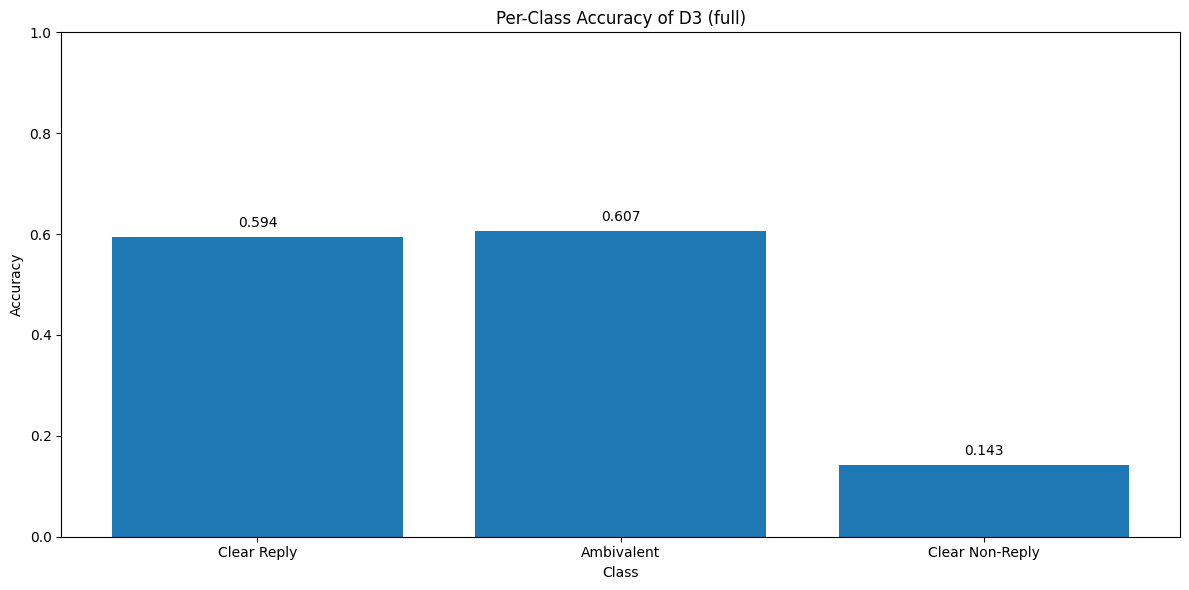

In [186]:
# # Per-class accuracy bar chart
# accuracies = [error_df[error_df["clarity_label"] == c]["correct"].mean() for c in VALID_LABELS]

# plt.figure(figsize=(12, 6))
# plt.bar(VALID_LABELS, accuracies)
# plt.title(f"Per-Class Accuracy of {WINNER_NAME}")
# plt.xlabel("Class")
# plt.ylabel("Accuracy")
# plt.ylim(0, 1)
# for i, v in enumerate(accuracies):
#   plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
# plt.tight_layout()
# plt.savefig(f"per-class-accuracy-{WINNER_NAME}.png", dpi=150, bbox_inches="tight")
# plt.show()

In [187]:
# # Show some error examples per class
# NUM_EXAMPLES = 3

# def drop_raw(d):
#   """
#   Return the dict without its 'raw' key, for cleaner display.

#   Args:
#     d: a parsed agent-output dict

#   Return:
#     A new dict with every key except 'raw'
#   """
#   return {k: v for k, v in d.items() if k != "raw"}

# for label_name in VALID_LABELS:
#   print(f"\n=== Errors for true label: {label_name} ===")
#   errors = error_df[(error_df["clarity_label"] == label_name) & (error_df["correct"] == False)]
#   for i, row in errors.head(NUM_EXAMPLES).iterrows():
#     intent = json.loads(row["d3_question_intent"])
#     content = json.loads(row["d3_answer_content"])
#     gap = json.loads(row["d3_gap_evasion"])
#     decision = json.loads(row["d3_decision"])

#     print(f"\nQuestion: {row['question']}")
#     print(f"Answer: {row['interview_answer']}")
#     print(f"True: {row['clarity_label']} | Predicted: {row['predicted_label']}")
#     print(f"\nAgent 1: Question Intent\n{json.dumps(drop_raw(intent), indent=2, ensure_ascii=False)}")
#     print(f"\nAgent 2: Answer Content\n{json.dumps(drop_raw(content), indent=2, ensure_ascii=False)}")
#     print(f"\nAgent 3: Gap & Evasion\n{json.dumps(drop_raw(gap), indent=2, ensure_ascii=False)}")
#     print(f"\nAgent 4: Decision raw\n{decision.get('raw', '')}")
#     print("-" * 80)


=== Errors for true label: Clear Reply ===

Question: What was the conversation like with Marine Commandant Amos when he expressed his concerns about don't ask, don't tell and said he would abide by the ruling?
Answer: You know, I don't want to go into detail about conversations in the Oval Office with my service chiefs. Jim Amos expressed the same concerns to me privately that he expressed publicly during his testimony. He said that there could be disruptions as a consequence of this. And what I said to him was that I was confident, looking at the history of the military with respect to racial integration, with respect to the inclusion of women in our Armed Forces, that that could be managed. And that was confirmed by the attitudinal studies that was done prior to this vote.And what he assured me of, and what all the service chiefs have assured me of, is that regardless of their concerns about disruptions, they were confident that they could implement this policy without it affecting

In [188]:
# # Error rate by answer length: check if model accuracy depends on answer length
# error_df["answer_len"] = error_df["interview_answer"].str.split().str.len()

# # 4 bins: Short (<50 words), Medium (50-150), Long (150-300), Very Long (>300)
# error_df["answer_len_group"] = pd.cut(
#     error_df["answer_len"],
#     bins=[0, 50, 150, 300, 2300],
#     labels=["Short", "Medium", "Long", "Very Long"],
# )

# summary = error_df.groupby("answer_len_group", observed=True).agg(
#     total_samples=("correct", "count"),
#     errors=("correct", lambda x: (x == False).sum()),
#     accuracy=("correct", "mean"),
#     pct_clear_reply=("clarity_label", lambda x: (x == "Clear Reply").mean()),
#     pct_ambivalent=("clarity_label", lambda x: (x == "Ambivalent").mean()),
#     pct_non_reply=("clarity_label", lambda x: (x == "Clear Non-Reply").mean()),
# )
# summary["error_rate"] = summary["errors"] / summary["total_samples"]
# display(summary.round(3))

,total_samples,errors,accuracy,pct_clear_reply,pct_ambivalent,pct_non_reply,error_rate
answer_len_group,,,,,,,
Short,25,12,0.520,0.280,0.560,0.160,0.480
Medium,15,5,0.667,0.200,0.733,0.067,0.333
Long,25,11,0.560,0.400,0.560,0.040,0.440
Very Long,35,15,0.571,0.343,0.629,0.029,0.429


In [189]:
# # Error rate by question length: check if model accuracy depends on question length
# error_df["question_len"] = error_df["question"].str.split().str.len()

# # 4 bins: Short (<10 words), Medium (10-20), Long (20-30), Very Long (>30)
# error_df["question_len_group"] = pd.cut(
#     error_df["question_len"],
#     bins=[0, 10, 20, 30, 100],
#     labels=["Short", "Medium", "Long", "Very Long"],
# )

# summary_q = error_df.groupby("question_len_group", observed=True).agg(
#     total_samples=("correct", "count"),
#     errors=("correct", lambda x: (x == False).sum()),
#     accuracy=("correct", "mean"),
#     pct_clear_reply=("clarity_label", lambda x: (x == "Clear Reply").mean()),
#     pct_ambivalent=("clarity_label", lambda x: (x == "Ambivalent").mean()),
#     pct_non_reply=("clarity_label", lambda x: (x == "Clear Non-Reply").mean()),
# )
# summary_q["error_rate"] = summary_q["errors"] / summary_q["total_samples"]
# display(summary_q.round(3))

,total_samples,errors,accuracy,pct_clear_reply,pct_ambivalent,pct_non_reply,error_rate
question_len_group,,,,,,,
Short,38,21,0.447,0.421,0.500,0.079,0.553
Medium,45,16,0.644,0.222,0.711,0.067,0.356
Long,13,6,0.538,0.385,0.538,0.077,0.462
Very Long,4,0,1.000,0.250,0.750,0.000,0.000


In [190]:
# # Most common misclassification pairs: which class is mistaken for which?
# errors = error_df[error_df["correct"] == False]
# misclassifications = (errors.groupby(["clarity_label", "predicted_label"]).size().reset_index(name="count").sort_values("count", ascending=False))
# display(misclassifications)

,clarity_label,predicted_label,count
0,Ambivalent,Clear Reply,24
3,Clear Reply,Ambivalent,12
1,Clear Non-Reply,Ambivalent,4
2,Clear Non-Reply,Clear Reply,2
4,Clear Reply,Clear Non-Reply,1


In [191]:
# # Parse-failure inspection: what did the Decision Agent output when it could not be parsed?
# TOP_N = 5

# failed_mask = error_df["predicted_label"].isna()
# n_failed = failed_mask.sum()
# print(f"{WINNER_NAME}: {n_failed}/{len(error_df)} parse failures ({n_failed/len(error_df):.2%})")

# if n_failed > 0:
#   print(f"\nTop {TOP_N} most common failed raw outputs:")
#   failed_outputs = error_df.loc[failed_mask, "d3_decision"].apply(lambda s: json.loads(s).get("raw", ""))
#   for resp, count in failed_outputs.value_counts().head(TOP_N).items():
#     print(f"  count={count}: {resp}")

D3 (full): 0/100 parse failures (0.00%)


## Performance on Test Set

We report results on the held-out test set. **D3 (full)** had the highest macro F1 on validation and is the configuration analyzed in the Error Analysis above. Since the Kaggle leaderboard is scored on **weighted F1**, the submitted system is the **weighted-F1 winner of D3 with the DSPy-optimized Agent 3**, which we run live below to generate the submission file.

We report results on the held-out test set. On validation, D3 (full) with reference prompts was the best configuration on both macro F1 and weighted F1. Since Kaggle scores weighted F1, this is the system we submit. No prompt-optimization variant manual, or DSPy BootstrapFewShot, RandomSearch, MIPROv2 on Agents 1, 3, or 4 beat it on validation. We run this baseline configuration live on the test set below to generate the submission file.

### Evaluate on Test Set

In [31]:
# Run the winning configuration on test_df, best on both weighted and macro F1
test_csv_path = f"d3_test_ref_prompts_{BACKBONE}.csv"
result_test = run_d3_dataframe(test_df, output_filename=test_csv_path, limit=D3_TEST_LIMIT)
result_test["predicted_label"] = result_test["pred_d3"]
print(f"\nTest set inference complete: {len(result_test)} examples saved to {test_csv_path}")

D3-Agentic Prompting:   0%|          | 0/308 [00:00<?, ?it/s]


Test set inference complete: 308 examples saved to d3_test_ref_prompts_Qwen3.5-0.8B.csv


In [32]:
# Visual sanity check: peek at a few test predictions
sample = result_test.sample(3, random_state=SEED)
for _, row in sample.iterrows():
  print(f"Question: {row['question']}")
  print(f"Gold: {row['clarity_label']}")
  print(f"Predicted: {row['predicted_label']}\n")

Question: What does President Kikwete think it says about America, that the country might elect a black President with African roots?
Gold: Clear Non-Reply
Predicted: Clear Reply

Question: Isn't Tehran's influence in the region growing despite your efforts to curb it?
Gold: Ambivalent
Predicted: Ambivalent

Question: Administration's contingency plans for his death
Gold: Ambivalent
Predicted: Ambivalent



In [33]:
# Check the lengths of gold and predicted columns
print(f"Gold: {len(result_test['clarity_label'])}")
print(f"Predicted: {len(result_test['predicted_label'])}")

Gold: 308
Predicted: 308


In [34]:
# Evaluate test predictions
test_y_true = result_test["clarity_label"].tolist()
test_y_pred = result_test["predicted_label"].tolist()
test_sec = result_test["d3_elapsed_sec"].mean()
test_metrics = evaluate_predictions(test_y_true, test_y_pred, "D3 (full)", method="ref prompts (test)", sec_per_example=test_sec)
display(pd.DataFrame([test_metrics]).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts (test),0.529,0.468,0.391,0.398,0.565,0.529,0.536,0.0,31.641


In [35]:
# Per-class classification report on test set
y_true = result_test["clarity_label"]
y_pred = result_test["predicted_label"].fillna("INVALID")
print(classification_report(y_true, y_pred, labels=VALID_LABELS))

                 precision    recall  f1-score   support

    Clear Reply       0.29      0.43      0.35        79
     Ambivalent       0.68      0.61      0.65       206
Clear Non-Reply       0.43      0.13      0.20        23

       accuracy                           0.53       308
      macro avg       0.47      0.39      0.40       308
   weighted avg       0.56      0.53      0.54       308



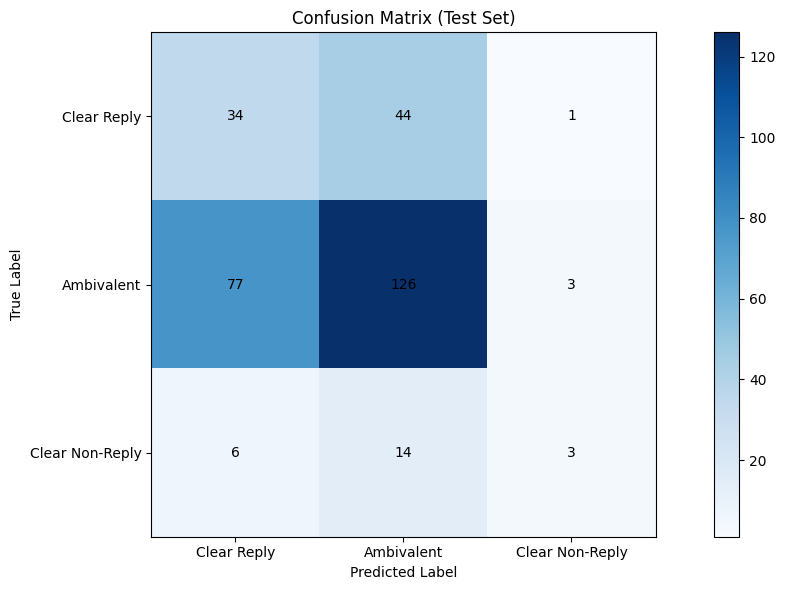

In [36]:
# Confusion matrix on the test set
cm = confusion_matrix(y_true, y_pred, labels=VALID_LABELS)
plt.figure(figsize=(12, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(VALID_LABELS)), VALID_LABELS)
plt.yticks(range(len(VALID_LABELS)), VALID_LABELS)
for r in range(cm.shape[0]):
  for c in range(cm.shape[1]):
    plt.text(c, r, cm[r, c], ha="center", va="center")
plt.title(f"Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(f"d3_confusion_matrix_test_{BACKBONE}.png", dpi=150, bbox_inches="tight")
plt.show()

### Generate submission.csv

In [37]:
# Build the submission DataFrame for Kaggle
submission = pd.DataFrame({
    "Id": test_df.index,
    "Predicted": result_test["predicted_label"].fillna("Ambivalent"),
}) # Fall back to "Ambivalent" (majority class) on parse failure

submission.to_csv("submission_best_d3_agentic_system.csv", index=False)
print(f"Saved submission_best_d3_agentic_system.csv with {len(submission)} rows")

Saved submission_best_d3_agentic_system.csv with 308 rows


In [38]:
# Display first 3 rows of submission file to verify format
display(submission.head(3))

,Id,Predicted
0,0,Ambivalent
1,1,Clear Reply
2,2,Ambivalent


## Appendix

### D3 with a Different Model Family

**Llama-3.2 (1B Instruct)**

In [ ]:
# MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
# BACKBONE = MODEL_NAME.split("/")[-1]

# # Load the Llama model (same loader as above)
# tokenizer, model = load_qwen_model(MODEL_NAME)

# # Run the full D3 (reference prompts) pipeline on the val subset
# llama_csv_path = f"d3_validation_ref_prompts_{BACKBONE}.csv"
# llama_valid_df = run_d3_dataframe(val_df, output_filename=llama_csv_path, limit=D3_VALID_LIMIT, checkpoint_every=25)
# print("Saved:", llama_csv_path)

In [ ]:
# # Score the model's D3 run and record it
# llama_y_true = llama_valid_df["clarity_label"].tolist()
# llama_y_pred = llama_valid_df["pred_d3"].tolist()
# llama_sec = llama_valid_df["d3_elapsed_sec"].mean()

# llama_result = evaluate_predictions(llama_y_true, llama_y_pred, "D3 (full)", method="ref prompts", backbone=BACKBONE, sec_per_example=llama_sec)
# all_results.append(llama_result)

# llama_clean = ["INVALID" if p is None else p for p in llama_y_pred]
# title = f"D3 (full), ref prompts ({BACKBONE})"
# print_full_report(llama_y_true, llama_clean, title)
# plot_confusion_matrix(llama_y_true, llama_clean, title, f"d3_confusion_matrix_ref_prompts_{BACKBONE}.png")

**Gemma-3 (1B Instruct)**

In [ ]:
# MODEL_NAME = "google/gemma-3-1b-it"
# BACKBONE = MODEL_NAME.split("/")[-1]

# # Load the Gemma model (same loader as above)
# tokenizer, model = load_qwen_model(MODEL_NAME)

# # Run the full D3 (reference prompts) pipeline on the val subset
# gemma_csv_path = f"d3_validation_ref_prompts_{BACKBONE}.csv"
# gemma_valid_df = run_d3_dataframe(val_df, output_filename=gemma_csv_path, limit=D3_VALID_LIMIT, checkpoint_every=25)
# print("Saved:", gemma_csv_path)

In [ ]:
# Score the model's D3 run and record it
# gemma_y_true = gemma_valid_df["clarity_label"].tolist()
# gemma_y_pred = gemma_valid_df["pred_d3"].tolist()
# gemma_sec = gemma_valid_df["d3_elapsed_sec"].mean()

# gemma_result = evaluate_predictions(gemma_y_true, gemma_y_pred, "D3 (full)", method="ref prompts", backbone=BACKBONE, sec_per_example=gemma_sec)
# all_results.append(gemma_result)

# gemma_clean = ["INVALID" if p is None else p for p in gemma_y_pred]
# title = f"D3 (full), ref prompts ({BACKBONE})"
# print_full_report(gemma_y_true, gemma_clean, title)
# plot_confusion_matrix(gemma_y_true, gemma_clean, title, f"d3_confusion_matrix_ref_prompts_{BACKBONE}.png")

**Model Family Comparison**

In [ ]:
# Compare D3 (full) across the three model families
# model_family_results = [d3_ref_prompts_result, llama_result, gemma_result]
# display(pd.DataFrame(model_family_results).round(3))

In [159]:
# Recorded results (100-row val subset) for frozen model-family runs
llama_result = {
  "system": "D3 (full)",
  "backbone": "Llama-3.2-1B-Instruct",
  "method": "ref prompts",
  "accuracy": 0.32,
  "precision_macro": 0.108,
  "recall_macro": 0.333,
  "f1_macro": 0.163,
  "precision_weighted": 0.103,
  "recall_weighted": 0.32,
  "f1_weighted": 0.156,
  "parse_failure_rate": 0.01,
  "sec_per_example": 9.924,
}

gemma_result = {
  "system": "D3 (full)",
  "backbone": "gemma-3-1b-it",
  "method": "ref prompts",
  "accuracy": 0.30,
  "precision_macro": 0.372,
  "recall_macro": 0.370,
  "f1_macro": 0.293,
  "precision_weighted": 0.514,
  "recall_weighted": 0.30,
  "f1_weighted": 0.316,
  "parse_failure_rate": 0.12,
  "sec_per_example": 53.383,
}

recorded_results.append(llama_result)
recorded_results.append(gemma_result)

In [160]:
# # Compare D3 (full) across the three model families
# model_family_results = [d3_ref_prompts_result, llama_result, gemma_result]
# display(pd.DataFrame(model_family_results).round(3))

,system,backbone,method,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,parse_failure_rate,sec_per_example
0,D3 (full),Qwen3.5-0.8B,ref prompts,0.57,0.540,0.448,0.455,0.596,0.57,0.569,0.00,30.306
1,D3 (full),Llama-3.2-1B-Instruct,ref prompts,0.32,0.108,0.333,0.163,0.103,0.32,0.156,0.01,9.924
2,D3 (full),gemma-3-1b-it,ref prompts,0.30,0.372,0.370,0.293,0.514,0.30,0.316,0.12,53.383


### Download all Results & Figures

In [115]:
# # Zip all generated .png figures
# import zipfile
# import os

# with zipfile.ZipFile("figures.zip", "w") as zipf:
#   for f in os.listdir("."):
#     if f.endswith(".png"):
#       zipf.write(f)

# # Zip all results tables as CSV
# pd.DataFrame(all_results).to_csv("results_all.csv", index=False)

# with zipfile.ZipFile("results.zip", "w") as zipf:
#   for f in os.listdir("."):
#     if f.endswith(".csv"):
#       zipf.write(f)

# # Zip all generated .json files
# with zipfile.ZipFile("json_files.zip", "w") as zipf:
#   for f in os.listdir("."):
#     if f.endswith(".json"):
#       zipf.write(f)

In [116]:
# # Download all generated zip files
# from google.colab import files
# files.download("figures.zip")
# files.download("results.zip")
# files.download("json_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## References

* [Dataset](https://huggingface.co/datasets/ailsntua/QEvasion)
* [Hugging Face, Text Generation](https://huggingface.co/docs/transformers/main/en/llm_tutorial)
* [DSPy](https://dspy.ai/)
* [DSPy Optimizers (API Reference)](https://dspy.ai/api/)
* [Sciki-Learn, Classification Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)
* [Qwen3.5-0.8B model card](https://huggingface.co/Qwen/Qwen3.5-0.8B)
* [Llama-3.2-1B-Instruct, model card](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct)
* [Gemma-3-1b-it, model card](https://huggingface.co/google/gemma-3-1b-it)